<a href="https://colab.research.google.com/github/M4XJUNG/sp500-volatility-regime/blob/main/notebook/sml_team_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install koreanize_matplotlib # 도표 내에서 한글을 사용
import koreanize_matplotlib
import pandas as pd # csv 파일을 처리 이 프로그램 내에서는 pandas라는 모듈을 pd라는 이름으로 사용합니다 라는 의미
import numpy as np
import matplotlib.pyplot as plt # 도표를 작성합니다
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 47.8 MB/s eta 0:00:00


In [2]:
# ── Colab 한글 폰트 설치 (매 세션마다 1회 실행) ──────────────
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔 폰트 경로 찾기
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print(" 한글 폰트 설정 완료")

 한글 폰트 설정 완료


In [3]:
# ============================================================
# S&P 500 변동성 레짐 분류 프로젝트
# 파일: 01_EDA_FeatureEngineering.ipynb
# 순서대로 셀 단위로 실행할 것
# ============================================================


# ──────────────────────────────────────────────────────────────
# [셀 1] 라이브러리 설치 및 Google Drive 마운트
# ──────────────────────────────────────────────────────────────

# Colab에서 실행 시 아래 주석 해제
# from google.colab import drive
# drive.mount('/content/drive')

# 필요 라이브러리 설치 (Colab 기본 제공이지만 명시)
# !pip install -q pandas numpy matplotlib seaborn scikit-learn scipy statsmodels

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os

# ── 경로 설정 ──────────────────────────────────────────────
# Google Drive 사용 시:
# DATA_PATH = '/content/drive/MyDrive/sp500_project/sap500.csv'
# FIG_DIR   = '/content/drive/MyDrive/sp500_project/figures'

# 로컬 / Colab 직접 업로드 시:
DATA_PATH = 'sap500.csv'   # 파일 위치에 맞게 수정
FIG_DIR   = './figures'
os.makedirs(FIG_DIR, exist_ok=True)

# ── 시각화 스타일 설정 ──────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 120,
    'figure.facecolor': 'white',
    'axes.facecolor'  : '#f8f9fa',
    'axes.grid'       : True,
    'grid.alpha'      : 0.4,
    'grid.linewidth'  : 0.6,
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : 11,
    'lines.linewidth' : 1.5,
})

print("✅ 환경 설정 완료")

✅ 환경 설정 완료


In [4]:
# ──────────────────────────────────────────────────────────────
# [셀 2] 데이터 로드 및 기초 확인
# ──────────────────────────────────────────────────────────────

df_raw = pd.read_csv(DATA_PATH, parse_dates=['Date'])
df_raw = df_raw.sort_values('Date').reset_index(drop=True)

print("=" * 55)
print("  S&P 500 원본 데이터 기본 정보")
print("=" * 55)
print(f"  전체 행 수    : {len(df_raw):,}행")
print(f"  컬럼         : {df_raw.columns.tolist()}")
print(f"  기간         : {df_raw.Date.min().date()} ~ {df_raw.Date.max().date()}")
print(f"  결측치       : {df_raw.isnull().sum().sum()}개")
print()
print(df_raw.head())
print()
print(df_raw.describe().round(2))

  S&P 500 원본 데이터 기본 정보
  전체 행 수    : 24,663행
  컬럼         : ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
  기간         : 1927-12-30 ~ 2026-03-10
  결측치       : 0개

        Date       Open       High        Low      Close  Volume
0 1927-12-30  17.660000  17.660000  17.660000  17.660000     0.0
1 1928-01-03  17.760000  17.760000  17.760000  17.760000     0.0
2 1928-01-04  17.719999  17.719999  17.719999  17.719999     0.0
3 1928-01-05  17.549999  17.549999  17.549999  17.549999     0.0
4 1928-01-06  17.660000  17.660000  17.660000  17.660000     0.0

                                Date      Open      High       Low     Close  \
count                          24663  24663.00  24663.00  24663.00  24663.00   
mean   1977-03-04 19:32:28.230142304    726.22    730.39    721.77    726.37   
min              1927-12-30 00:00:00      4.40      4.40      4.40      4.40   
25%              1952-09-06 12:00:00     24.95     24.95     24.95     24.95   
50%              1977-04-06 00:00:00    1

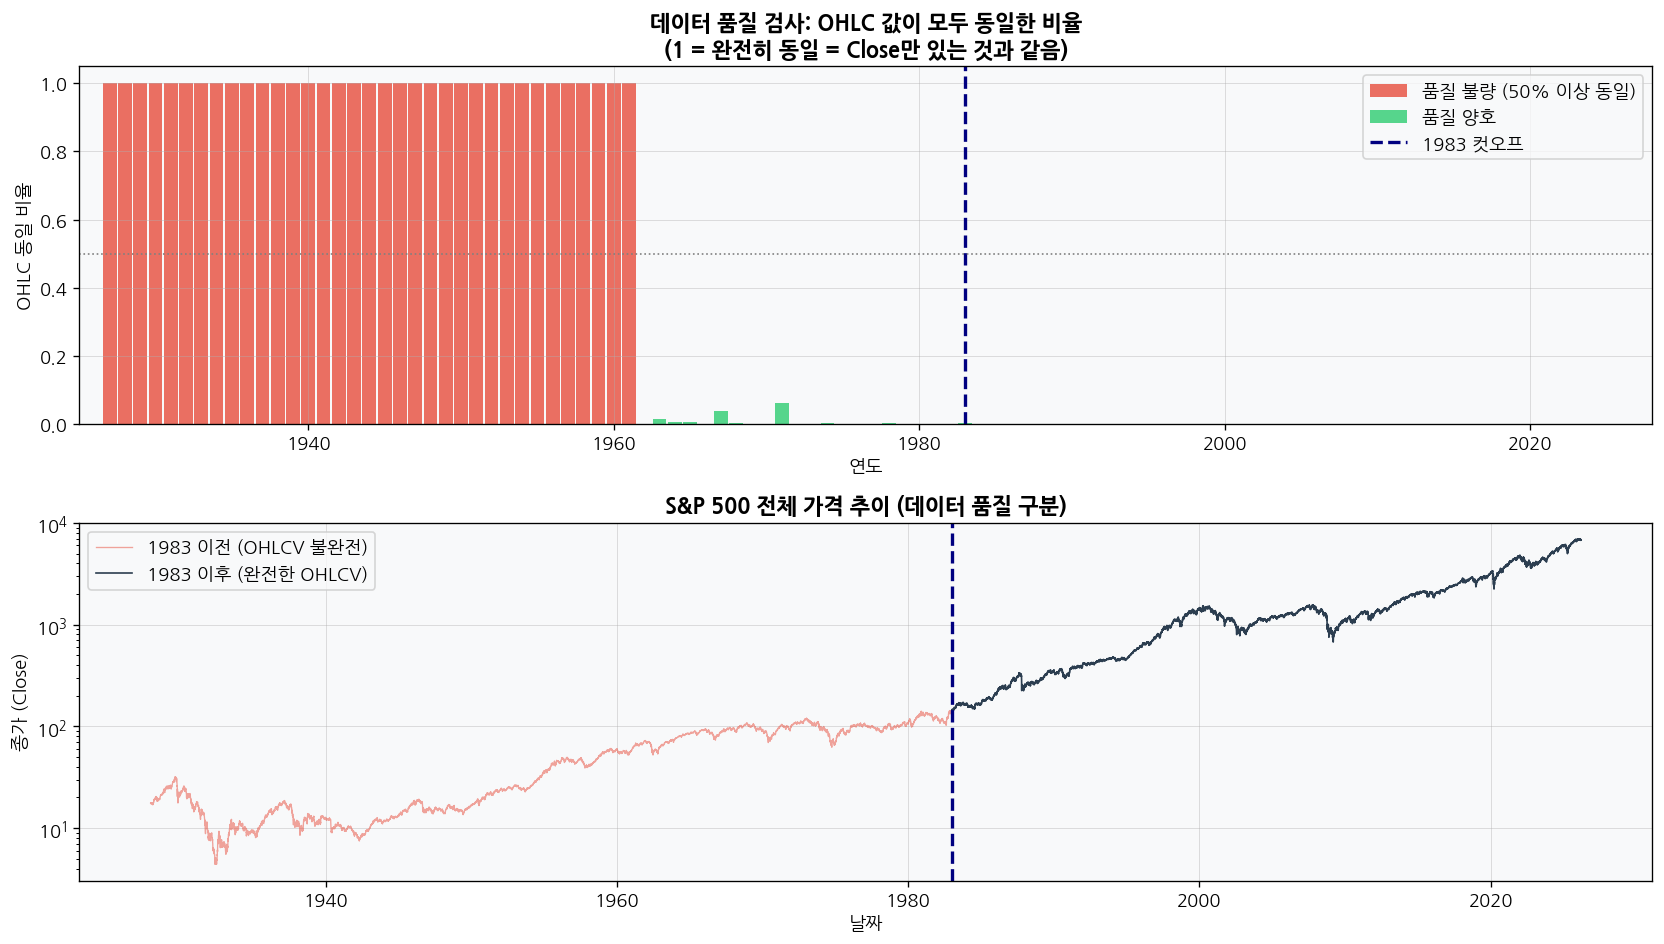


 데이터 품질 요약
  1983 이전: 13,781행  →  OHLC 대부분 동일, 사용 불가
  1983 이후: 10,882행   →  완전한 OHLCV 데이터

 결론: 1983-01-01 이후 데이터만 사용 (n=10,882)


In [5]:
# ──────────────────────────────────────────────────────────────
# [셀 3] 데이터 품질 검사 — 1983 컷오프 근거 도출
# ──────────────────────────────────────────────────────────────
# 핵심 분석: OHLC가 모두 동일한 행 = 실질적으로 Close만 존재
# → 이를 시각화해서 1983 컷오프 선정 근거로 사용

df_raw['ohlc_identical'] = (
    (df_raw['Open']  == df_raw['Close']) &
    (df_raw['High']  == df_raw['Close']) &
    (df_raw['Low']   == df_raw['Close'])
)
df_raw['year'] = df_raw['Date'].dt.year

# 연도별 OHLC 동일 비율
quality_by_year = df_raw.groupby('year')['ohlc_identical'].mean().reset_index()
quality_by_year.columns = ['year', 'identical_ratio']

# ── 시각화 ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 상단: OHLC 동일 비율
ax = axes[0]
colors = ['#e74c3c' if r > 0.5 else '#2ecc71' for r in quality_by_year['identical_ratio']]
ax.bar(quality_by_year['year'], quality_by_year['identical_ratio'],
       color=colors, alpha=0.8, width=0.9)
ax.axvline(1983, color='navy', linestyle='--', linewidth=2,
           label='1983 컷오프 (이후 데이터만 사용)')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('연도')
ax.set_ylabel('OHLC 동일 비율')
ax.set_title('데이터 품질 검사: OHLC 값이 모두 동일한 비율\n'
             '(1 = 완전히 동일 = Close만 있는 것과 같음)')
ax.legend(fontsize=11)
ax.set_xlim(1925, 2028)

# 빨강/초록 범례
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', alpha=0.8, label='품질 불량 (50% 이상 동일)'),
    Patch(facecolor='#2ecc71', alpha=0.8, label='품질 양호')
]
ax.legend(handles=legend_elements + [
    plt.Line2D([0], [0], color='navy', linestyle='--', linewidth=2,
               label='1983 컷오프')
])

# 하단: 전체 Close 가격 추이 (배경으로 품질 구분)
ax2 = axes[1]
df_before = df_raw[df_raw['Date'] < '1983-01-01']
df_after  = df_raw[df_raw['Date'] >= '1983-01-01']
ax2.plot(df_before['Date'], df_before['Close'],
         color='#e74c3c', alpha=0.5, linewidth=0.8, label='1983 이전 (OHLCV 불완전)')
ax2.plot(df_after['Date'],  df_after['Close'],
         color='#2c3e50', linewidth=1.0, label='1983 이후 (완전한 OHLCV)')
ax2.axvline(pd.Timestamp('1983-01-01'), color='navy', linestyle='--', linewidth=2)
ax2.set_xlabel('날짜')
ax2.set_ylabel('종가 (Close)')
ax2.set_title('S&P 500 전체 가격 추이 (데이터 품질 구분)')
ax2.legend()
ax2.set_yscale('log')   # 로그 스케일: 장기 추세 비교에 유리

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_data_quality.png', bbox_inches='tight')
plt.show()

# 통계 출력
n_before = len(df_before)
n_after  = len(df_after)
print(f"\n 데이터 품질 요약")
print(f"  1983 이전: {n_before:,}행  →  OHLC 대부분 동일, 사용 불가")
print(f"  1983 이후: {n_after:,}행   →  완전한 OHLCV 데이터")
print(f"\n 결론: 1983-01-01 이후 데이터만 사용 (n={n_after:,})")

In [6]:
# ──────────────────────────────────────────────────────────────
# [셀 4] 분석용 데이터 확정 (1983년 이후)
# ──────────────────────────────────────────────────────────────

df = df_raw[df_raw['Date'] >= '1983-01-01'].copy()
df = df.drop(columns=['ohlc_identical', 'year'])
df = df.reset_index(drop=True)
df = df.set_index('Date')

print(f"분석 데이터: {df.index[0].date()} ~ {df.index[-1].date()}")
print(f"행 수: {len(df):,}행 (약 {len(df)/252:.0f}년치 거래일)")
print()
print(df.head())

분석 데이터: 1983-01-03 ~ 2026-03-10
행 수: 10,882행 (약 43년치 거래일)

                  Open        High         Low       Close       Volume
Date                                                                   
1983-01-03  140.649994  141.330002  138.199997  138.339996   59080000.0
1983-01-04  138.330002  141.360001  138.080002  141.360001   75530000.0
1983-01-05  141.350006  142.600006  141.149994  141.960007   95390000.0
1983-01-06  142.009995  145.770004  142.009995  145.270004  129410000.0
1983-01-07  145.270004  146.460007  145.149994  145.179993  127290000.0


  S&P 500 일별 로그수익률 기초 통계 (1983~2026)
  일평균 수익률  : 0.0358%
  일 표준편차    : 1.1361%
  연환산 수익률  : 9.01%
  연환산 변동성  : 18.03%
  왜도 (Skewness): -1.1111  (음수 = 하락 꼬리가 더 두꺼움)
  첨도 (Kurtosis): 25.2420  (정규분포=0, 양수=뾰족한 봉우리)
  최대 일일 하락: -22.90%
  최대 일일 상승: 10.96%


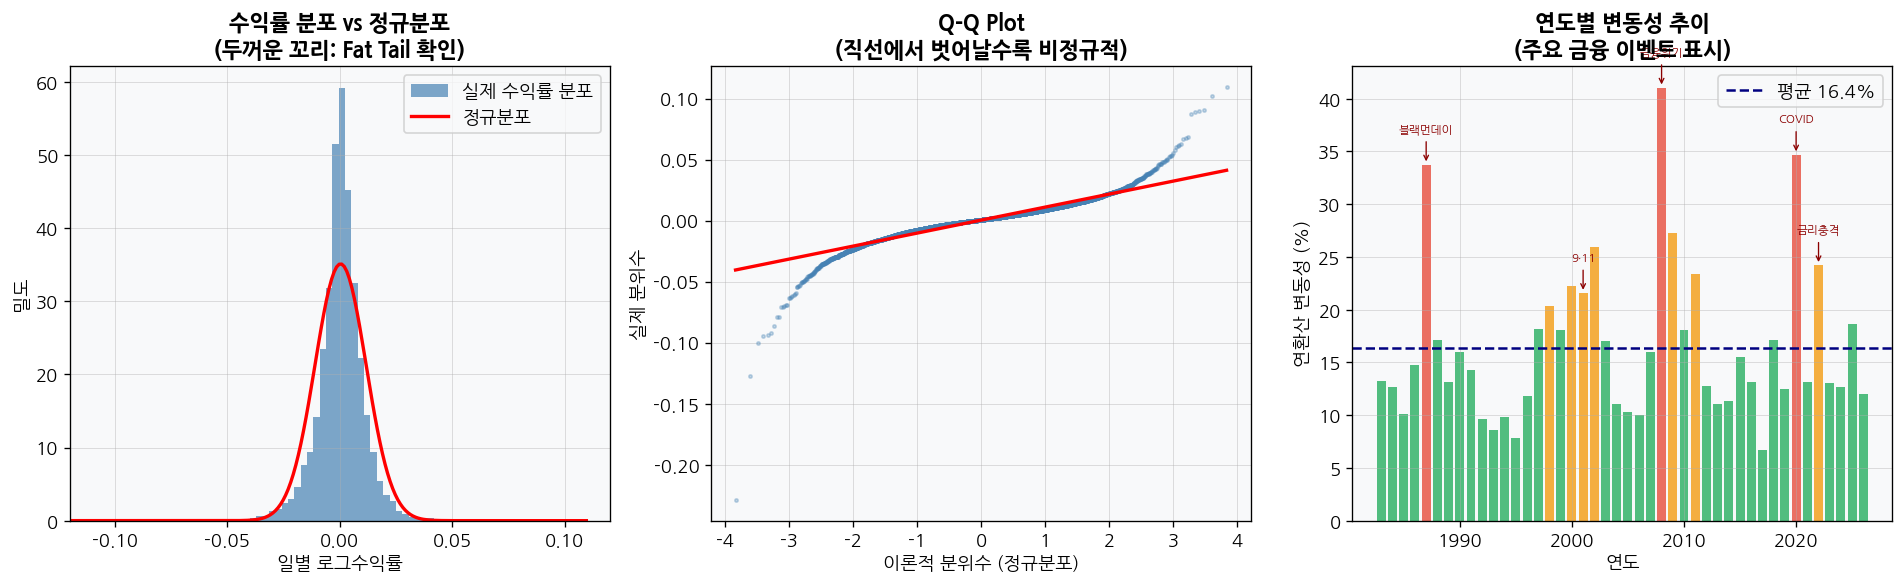

In [7]:
# ──────────────────────────────────────────────────────────────
# [셀 5] EDA ① — 기초 통계 및 수익률 분포
# ──────────────────────────────────────────────────────────────

df['log_ret'] = np.log(df['Close'] / df['Close'].shift(1))
df_clean = df.dropna(subset=['log_ret'])

# ── 기초 통계 출력 ─────────────────────────────────────────
mean_ret  = df_clean['log_ret'].mean()
std_ret   = df_clean['log_ret'].std()
ann_ret   = mean_ret * 252
ann_vol   = std_ret  * np.sqrt(252)
skew      = df_clean['log_ret'].skew()
kurt      = df_clean['log_ret'].kurt()

print("=" * 55)
print("  S&P 500 일별 로그수익률 기초 통계 (1983~2026)")
print("=" * 55)
print(f"  일평균 수익률  : {mean_ret*100:.4f}%")
print(f"  일 표준편차    : {std_ret*100:.4f}%")
print(f"  연환산 수익률  : {ann_ret*100:.2f}%")
print(f"  연환산 변동성  : {ann_vol*100:.2f}%")
print(f"  왜도 (Skewness): {skew:.4f}  (음수 = 하락 꼬리가 더 두꺼움)")
print(f"  첨도 (Kurtosis): {kurt:.4f}  (정규분포=0, 양수=뾰족한 봉우리)")
print(f"  최대 일일 하락: {df_clean['log_ret'].min()*100:.2f}%")
print(f"  최대 일일 상승: {df_clean['log_ret'].max()*100:.2f}%")

# ── 수익률 분포 시각화 ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (1) 히스토그램 + 정규분포 비교
ax = axes[0]
x_range = np.linspace(df_clean['log_ret'].min(), df_clean['log_ret'].max(), 300)
normal_pdf = stats.norm.pdf(x_range, mean_ret, std_ret)
ax.hist(df_clean['log_ret'], bins=120, density=True,
        color='steelblue', alpha=0.7, label='실제 수익률 분포')
ax.plot(x_range, normal_pdf, 'r-', linewidth=2, label='정규분포')
ax.set_xlabel('일별 로그수익률')
ax.set_ylabel('밀도')
ax.set_title('수익률 분포 vs 정규분포\n(두꺼운 꼬리: Fat Tail 확인)')
ax.legend()
ax.set_xlim(-0.12, 0.12)

# (2) Q-Q Plot
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(df_clean['log_ret'])
ax.plot(osm, osr, 'o', color='steelblue', alpha=0.3, markersize=2)
ax.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=2)
ax.set_xlabel('이론적 분위수 (정규분포)')
ax.set_ylabel('실제 분위수')
ax.set_title('Q-Q Plot\n(직선에서 벗어날수록 비정규적)')

# (3) 연도별 연환산 변동성
annual_vol_ts = (df_clean['log_ret']
                 .groupby(df_clean.index.year)
                 .std() * np.sqrt(252) * 100)
ax = axes[2]
colors_vol = ['#e74c3c' if v > 30 else '#f39c12' if v > 20 else '#27ae60'
              for v in annual_vol_ts]
ax.bar(annual_vol_ts.index, annual_vol_ts.values,
       color=colors_vol, alpha=0.8)
ax.axhline(annual_vol_ts.mean(), color='navy', linestyle='--',
           linewidth=1.5, label=f'평균 {annual_vol_ts.mean():.1f}%')

# 주요 이벤트 표시
events = {1987: '블랙먼데이', 2001: '9·11', 2008: '금융위기',
          2020: 'COVID', 2022: '금리충격'}
for yr, label in events.items():
    if yr in annual_vol_ts.index:
        ax.annotate(label, xy=(yr, annual_vol_ts[yr]),
                    xytext=(yr, annual_vol_ts[yr]+3),
                    fontsize=7, ha='center', color='darkred',
                    arrowprops=dict(arrowstyle='->', color='darkred',
                                   lw=0.8))
ax.set_xlabel('연도')
ax.set_ylabel('연환산 변동성 (%)')
ax.set_title('연도별 변동성 추이\n(주요 금융 이벤트 표시)')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_return_distribution.png', bbox_inches='tight')
plt.show()

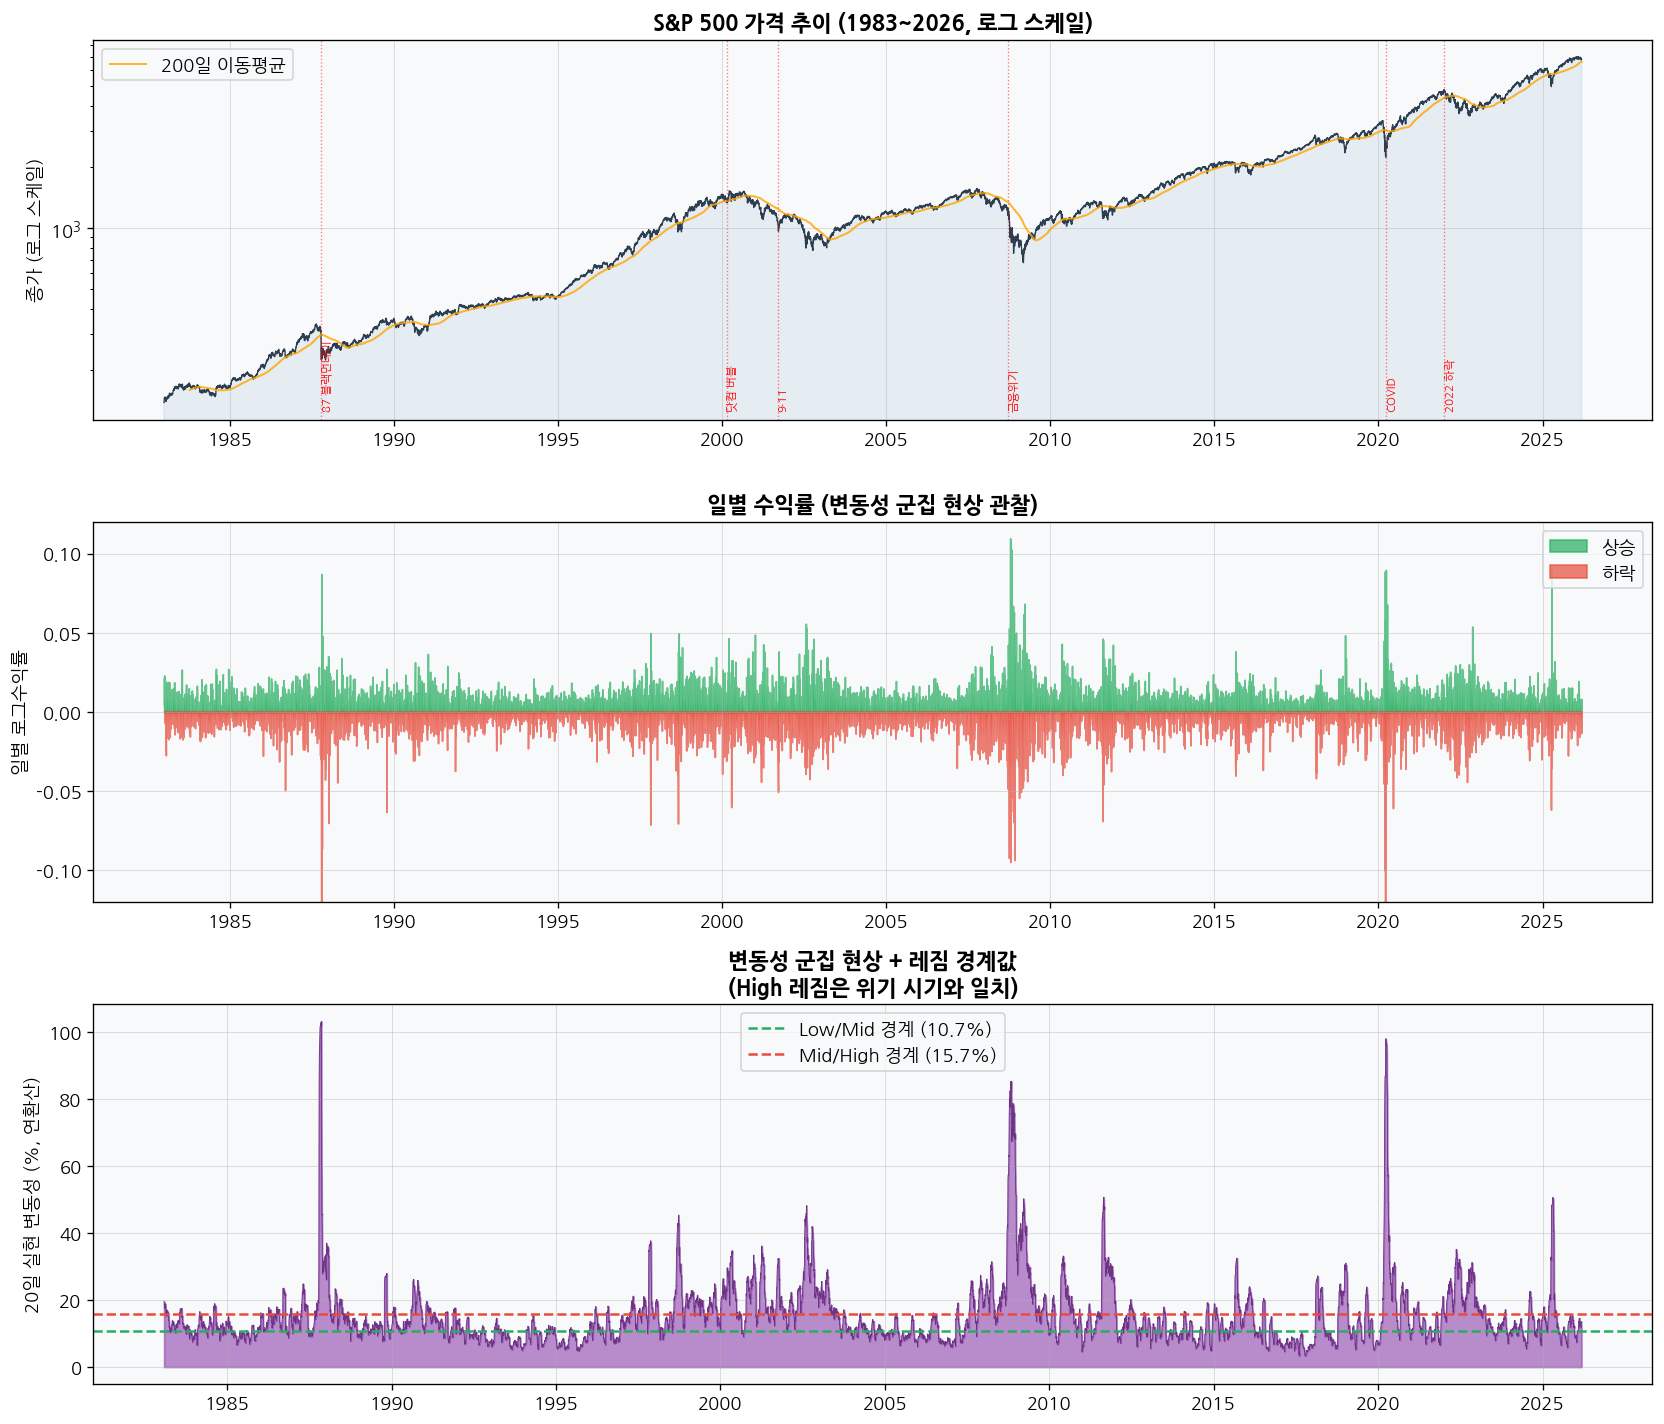

 변동성 레짐 경계값:
  Low  (안정장): 실현변동성 < 10.7%
  Mid  (보통장): 10.7% ~ 15.7%
  High (불안장): > 15.7%


In [8]:
# ──────────────────────────────────────────────────────────────
# [셀 6] EDA ② — 가격 추이 및 시장 구조 시각화
# ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# (1) 로그 스케일 가격 추이
ax = axes[0]
ax.plot(df.index, df['Close'], color='#2c3e50', linewidth=0.8)
ax.fill_between(df.index, df['Close'], alpha=0.1, color='steelblue')
ax.set_yscale('log')
ax.set_ylabel('종가 (로그 스케일)')
ax.set_title('S&P 500 가격 추이 (1983~2026, 로그 스케일)')
# 200일 이동평균 오버레이
ma200 = df['Close'].rolling(200).mean()
ax.plot(df.index, ma200, color='orange', linewidth=1.2,
        alpha=0.8, label='200일 이동평균')
ax.legend()

# 주요 이벤트 수직선
event_dates = {
    '87 블랙먼데이': '1987-10-19',
    '닷컴 버블': '2000-03-01',
    '9·11': '2001-09-11',
    '금융위기': '2008-09-15',
    'COVID': '2020-03-23',
    '2022 하락': '2022-01-01',
}
for label, date in event_dates.items():
    try:
        ax.axvline(pd.Timestamp(date), color='red',
                   alpha=0.5, linewidth=0.8, linestyle=':')
        ax.text(pd.Timestamp(date), ax.get_ylim()[0]*1.1,
                label, fontsize=7, color='red', rotation=90, va='bottom')
    except:
        pass

# (2) 일별 로그 수익률
ax = axes[1]
ret = df_clean['log_ret']
ax.fill_between(ret.index,
                ret.where(ret >= 0, 0), 0,
                alpha=0.7, color='#27ae60', label='상승')
ax.fill_between(ret.index,
                ret.where(ret < 0, 0), 0,
                alpha=0.7, color='#e74c3c', label='하락')
ax.set_ylabel('일별 로그수익률')
ax.set_title('일별 수익률 (변동성 군집 현상 관찰)')
ax.legend(loc='upper right')
ax.set_ylim(-0.12, 0.12)

# (3) 20일 실현 변동성 (연환산)
ax = axes[2]
rv20 = ret.rolling(20).std() * np.sqrt(252) * 100
ax.fill_between(rv20.index, rv20, alpha=0.6, color='#8e44ad')
ax.plot(rv20.index, rv20, color='#6c3483', linewidth=0.5)

# 레짐 임계값 표시
q33 = rv20.quantile(0.333)
q67 = rv20.quantile(0.667)
ax.axhline(q33, color='#27ae60', linestyle='--', linewidth=1.5,
           label=f'Low/Mid 경계 ({q33:.1f}%)')
ax.axhline(q67, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Mid/High 경계 ({q67:.1f}%)')
ax.set_ylabel('20일 실현 변동성 (%, 연환산)')
ax.set_title('변동성 군집 현상 + 레짐 경계값\n(High 레짐은 위기 시기와 일치)')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_price_and_volatility.png', bbox_inches='tight')
plt.show()

print(f" 변동성 레짐 경계값:")
print(f"  Low  (안정장): 실현변동성 < {q33:.1f}%")
print(f"  Mid  (보통장): {q33:.1f}% ~ {q67:.1f}%")
print(f"  High (불안장): > {q67:.1f}%")

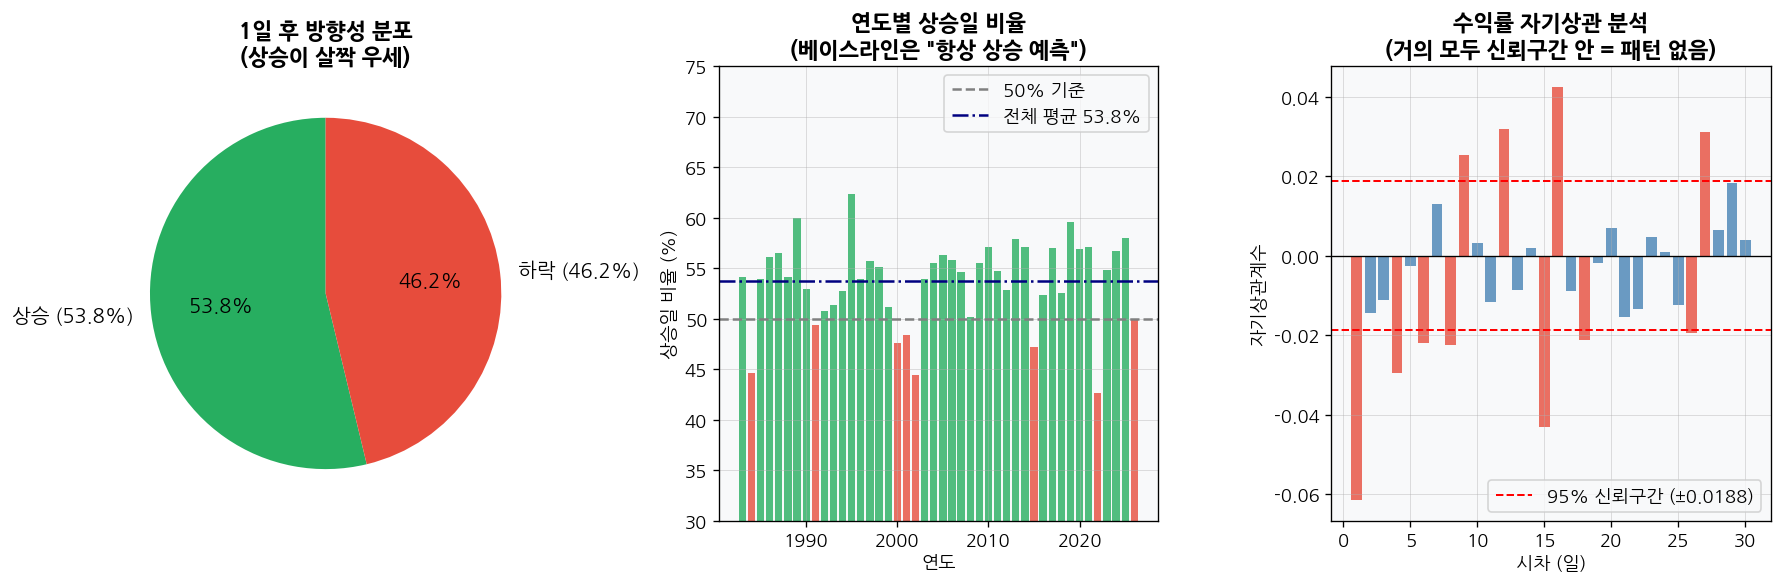

  ADF 검정 (단위근 검정: 비정상성 확인)
  검정통계량 : -18.4754
  p-value    : 0.000000
  1% 임계값  : -3.4310
   결론: p < 0.05 → 단위근 없음 (로그수익률은 정상 시계열)

 방향성 베이스라인 Accuracy: 53.8%
   → '항상 상승' 전략이 이미 이 수치를 달성
   → ML 모델이 이를 크게 뛰어넘기 어려운 구조


In [9]:
# ──────────────────────────────────────────────────────────────
# [셀 7] EDA ③ — 방향성 예측 시도 & 베이스라인 확인
# (스토리: "방향성은 예측이 어렵다"는 근거 EDA)
# ──────────────────────────────────────────────────────────────

# 1일 후 방향성 타겟 생성
df['target_dir'] = (df['Close'].shift(-1) > df['Close']).astype(int)

up_ratio   = df['target_dir'].dropna().mean()
down_ratio = 1 - up_ratio

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (1) 상승/하락 비율
ax = axes[0]
ax.pie([up_ratio, down_ratio],
       labels=[f'상승 ({up_ratio*100:.1f}%)', f'하락 ({down_ratio*100:.1f}%)'],
       colors=['#27ae60', '#e74c3c'],
       autopct='%1.1f%%', startangle=90,
       textprops={'fontsize': 12})
ax.set_title('1일 후 방향성 분포\n(상승이 살짝 우세)')

# (2) 연도별 상승 비율 → 안정적인가?
yearly_up = (df['target_dir']
             .groupby(df.index.year)
             .mean() * 100)
ax = axes[1]
ax.bar(yearly_up.index, yearly_up.values,
       color=['#27ae60' if v > 50 else '#e74c3c' for v in yearly_up],
       alpha=0.8)
ax.axhline(50, color='gray', linestyle='--', linewidth=1.5, label='50% 기준')
ax.axhline(up_ratio * 100, color='navy', linestyle='-.',
           linewidth=1.5, label=f'전체 평균 {up_ratio*100:.1f}%')
ax.set_xlabel('연도')
ax.set_ylabel('상승일 비율 (%)')
ax.set_title('연도별 상승일 비율\n(베이스라인은 "항상 상승 예측")')
ax.legend()
ax.set_ylim(30, 75)

# (3) 자기상관 분석: 내일 방향이 오늘과 관련 있는가?
ax = axes[2]
ret_vals = df_clean['log_ret'].values
lags     = range(1, 31)
acf_vals = [pd.Series(ret_vals).autocorr(lag=l) for l in lags]
colors_acf = ['#e74c3c' if abs(v) > 1.96/np.sqrt(len(ret_vals)) else 'steelblue'
              for v in acf_vals]
ax.bar(lags, acf_vals, color=colors_acf, alpha=0.8)
ci = 1.96 / np.sqrt(len(ret_vals))
ax.axhline( ci, color='red', linestyle='--', linewidth=1.2, label=f'95% 신뢰구간 (±{ci:.4f})')
ax.axhline(-ci, color='red', linestyle='--', linewidth=1.2)
ax.axhline(0,   color='black', linewidth=0.8)
ax.set_xlabel('시차 (일)')
ax.set_ylabel('자기상관계수')
ax.set_title('수익률 자기상관 분석\n(거의 모두 신뢰구간 안 = 패턴 없음)')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_direction_eda.png', bbox_inches='tight')
plt.show()

# ADF 검정 (비정상성 확인)
adf_result = adfuller(df_clean['log_ret'].dropna())
print("=" * 55)
print("  ADF 검정 (단위근 검정: 비정상성 확인)")
print("=" * 55)
print(f"  검정통계량 : {adf_result[0]:.4f}")
print(f"  p-value    : {adf_result[1]:.6f}")
print(f"  1% 임계값  : {adf_result[4]['1%']:.4f}")
if adf_result[1] < 0.05:
    print("   결론: p < 0.05 → 단위근 없음 (로그수익률은 정상 시계열)")
else:
    print("   결론: p ≥ 0.05 → 단위근 있음 (비정상 시계열)")

print(f"\n 방향성 베이스라인 Accuracy: {up_ratio*100:.1f}%")
print("   → '항상 상승' 전략이 이미 이 수치를 달성")
print("   → ML 모델이 이를 크게 뛰어넘기 어려운 구조")

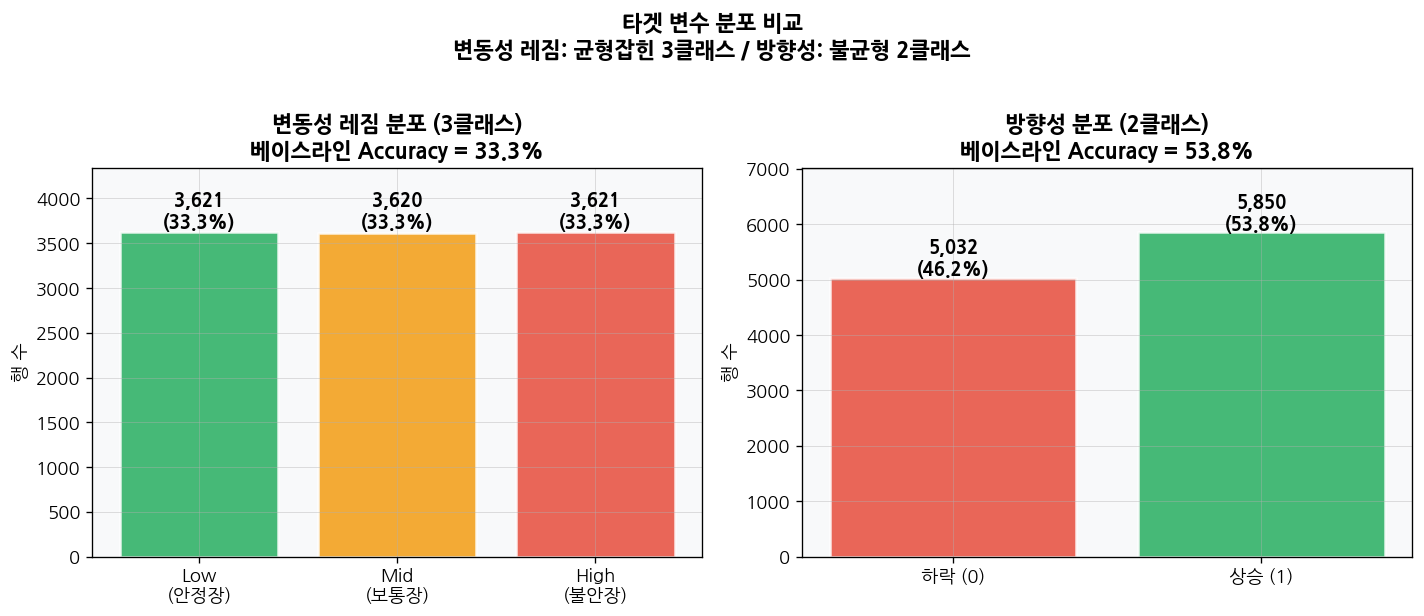

변동성 레짐 경계값: Low < 10.7% ≤ Mid < 15.7% ≤ High
레짐 분포: Low=3,621 / Mid=3,620 / High=3,621


In [10]:
# ──────────────────────────────────────────────────────────────
# [셀 8] EDA ④ — 변동성 레짐 타겟 생성 및 분포 확인
# ──────────────────────────────────────────────────────────────

# ── 타겟 1: 변동성 레짐 (메인) ────────────────────────────
# 향후 20일 실현 변동성을 3분위로 나눔
rv_future = df['log_ret'].rolling(20).std().shift(-20) * np.sqrt(252) * 100
df['target_vol_raw'] = rv_future

# 분위수 경계값 (훈련 데이터 기준으로 나중에 재계산, 여기선 전체 기준)
q1 = rv_future.quantile(1/3)
q2 = rv_future.quantile(2/3)

df['target_vol'] = pd.cut(
    rv_future,
    bins=[-np.inf, q1, q2, np.inf],
    labels=[0, 1, 2]   # 0=Low, 1=Mid, 2=High
).astype('Int64')  # 정수형 (NA 포함 가능)

# ── 타겟 2: 방향성 (서브 비교용) ──────────────────────────
df['target_dir'] = (df['Close'].shift(-1) > df['Close']).astype('Int64')

# 분포 확인
vol_dist = df['target_vol'].value_counts().sort_index()
dir_dist = df['target_dir'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (1) 변동성 레짐 분포
ax = axes[0]
labels_vol = ['Low\n(안정장)', 'Mid\n(보통장)', 'High\n(불안장)']
colors_vol = ['#27ae60', '#f39c12', '#e74c3c']
bars = ax.bar(labels_vol, vol_dist.values,
              color=colors_vol, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vol_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'{val:,}\n({val/vol_dist.sum()*100:.1f}%)',
            ha='center', fontsize=11, fontweight='bold')
ax.set_title('변동성 레짐 분포 (3클래스)\n베이스라인 Accuracy = 33.3%')
ax.set_ylabel('행 수')
ax.set_ylim(0, vol_dist.max() * 1.2)

# (2) 방향성 분포
ax = axes[1]
labels_dir = ['하락 (0)', '상승 (1)']
colors_dir = ['#e74c3c', '#27ae60']
bars2 = ax.bar(labels_dir, dir_dist.values,
               color=colors_dir, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, dir_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'{val:,}\n({val/dir_dist.sum()*100:.1f}%)',
            ha='center', fontsize=11, fontweight='bold')
ax.set_title('방향성 분포 (2클래스)\n베이스라인 Accuracy = 53.8%')
ax.set_ylabel('행 수')
ax.set_ylim(0, dir_dist.max() * 1.2)

plt.suptitle('타겟 변수 분포 비교\n변동성 레짐: 균형잡힌 3클래스 / 방향성: 불균형 2클래스',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_target_distribution.png', bbox_inches='tight')
plt.show()

print(f"변동성 레짐 경계값: Low < {q1:.1f}% ≤ Mid < {q2:.1f}% ≤ High")
print(f"레짐 분포: Low={vol_dist.get(0,0):,} / Mid={vol_dist.get(1,0):,} / High={vol_dist.get(2,0):,}")

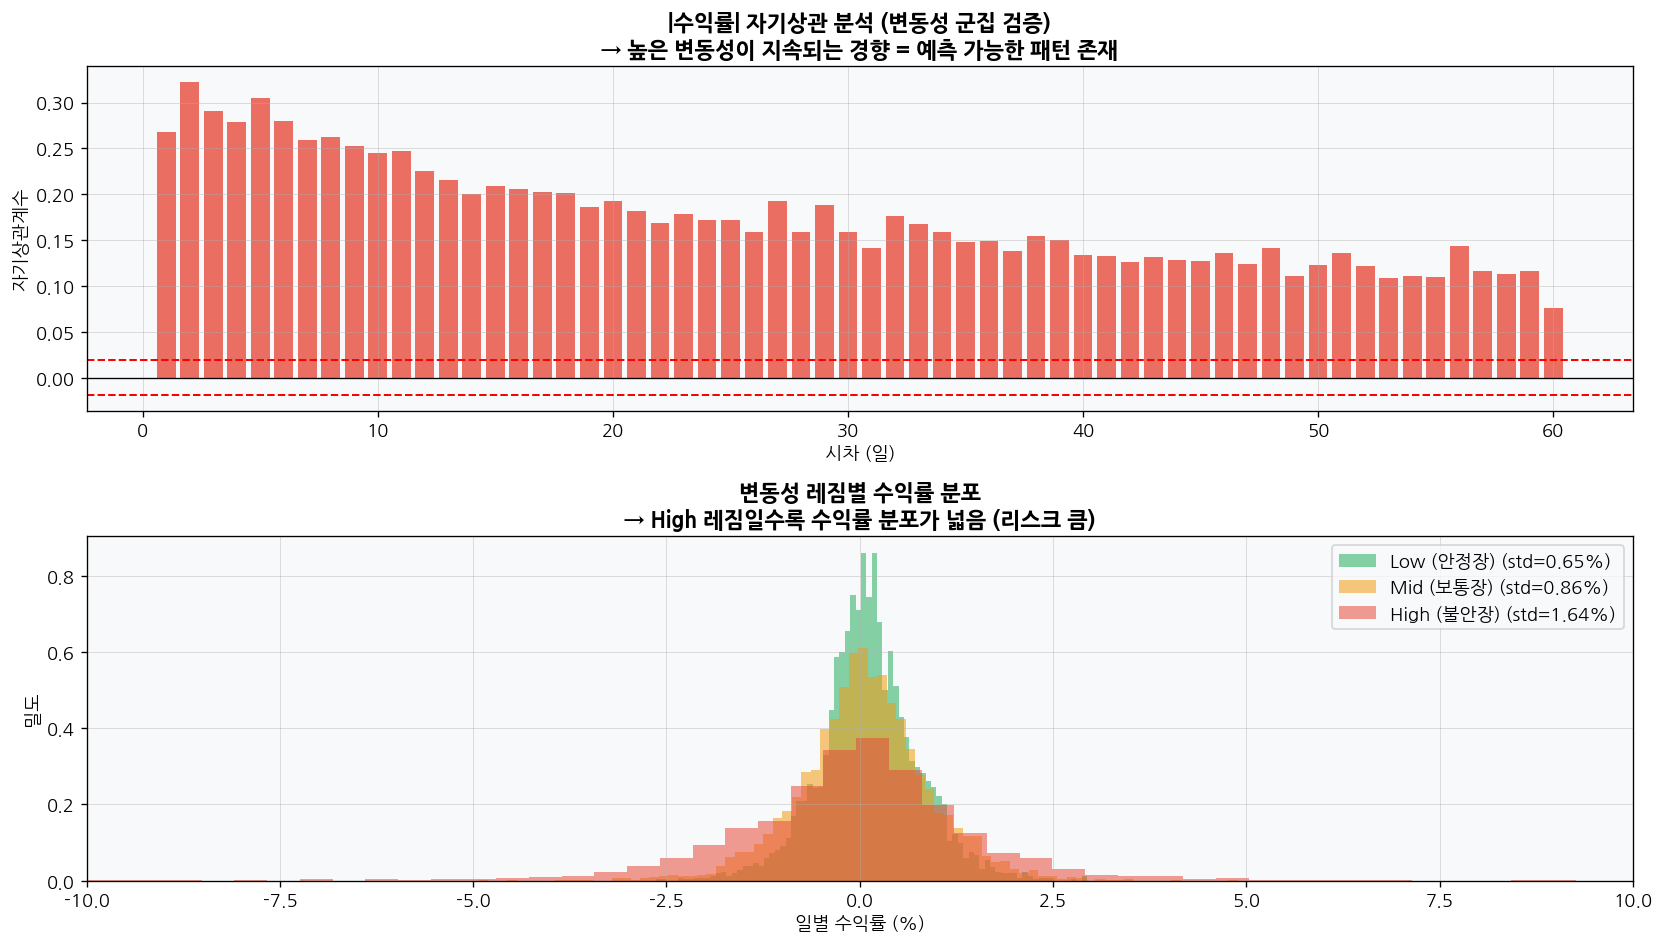


 레짐별 수익률 통계
-------------------------------------------------------
  Low (안정장):
    평균=0.123% | 표준편차=0.647% | 최소=-2.63% | 최대=2.94%
  Mid (보통장):
    평균=0.063% | 표준편차=0.861% | 최소=-4.93% | 최대=4.89%
  High (불안장):
    평균=-0.078% | 표준편차=1.642% | 최소=-22.90% | 최대=10.96%


In [11]:
# ──────────────────────────────────────────────────────────────
# [셀 9] EDA ⑤ — 변동성 군집(Volatility Clustering) 시각화
# (변동성 레짐 예측이 가능한 이유에 대한 시각적 근거)
# ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# (1) 수익률의 절댓값 자기상관 (변동성 군집 확인)
ax = axes[0]
abs_ret   = df_clean['log_ret'].abs()
lags_long = range(1, 61)
acf_abs   = [abs_ret.autocorr(lag=l) for l in lags_long]
ci_abs    = 1.96 / np.sqrt(len(abs_ret))

ax.bar(lags_long, acf_abs,
       color=['#e74c3c' if v > ci_abs else 'steelblue' for v in acf_abs],
       alpha=0.8)
ax.axhline( ci_abs, color='red', linestyle='--', linewidth=1.2)
ax.axhline(-ci_abs, color='red', linestyle='--', linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('시차 (일)')
ax.set_ylabel('자기상관계수')
ax.set_title('|수익률| 자기상관 분석 (변동성 군집 검증)\n'
             '→ 높은 변동성이 지속되는 경향 = 예측 가능한 패턴 존재')

# (2) 레짐별 수익률 분포 비교
ax = axes[1]
temp = df.dropna(subset=['target_vol', 'log_ret'])
regime_colors = {0: '#27ae60', 1: '#f39c12', 2: '#e74c3c'}
regime_labels = {0: 'Low (안정장)', 1: 'Mid (보통장)', 2: 'High (불안장)'}

for regime_id in [0, 1, 2]:
    subset = temp[temp['target_vol'] == regime_id]['log_ret'] * 100
    ax.hist(subset, bins=80, density=True, alpha=0.55,
            color=regime_colors[regime_id],
            label=f"{regime_labels[regime_id]} (std={subset.std():.2f}%)")

ax.set_xlabel('일별 수익률 (%)')
ax.set_ylabel('밀도')
ax.set_title('변동성 레짐별 수익률 분포\n'
             '→ High 레짐일수록 수익률 분포가 넓음 (리스크 큼)')
ax.legend()
ax.set_xlim(-10, 10)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_volatility_clustering.png', bbox_inches='tight')
plt.show()

# 레짐별 통계 테이블
print("\n 레짐별 수익률 통계")
print("-" * 55)
for regime_id, label in regime_labels.items():
    subset = temp[temp['target_vol'] == regime_id]['log_ret'] * 100
    print(f"  {label}:")
    print(f"    평균={subset.mean():.3f}% | 표준편차={subset.std():.3f}% | "
          f"최소={subset.min():.2f}% | 최대={subset.max():.2f}%")

In [12]:
# ──────────────────────────────────────────────────────────────
# [셀 10] Feature Engineering — 전체 피처 생성 함수
# ──────────────────────────────────────────────────────────────
# ⚠️ Data Leakage 방지 원칙:
#   모든 피처는 t일의 정보로 계산 후 shift(1)을 적용
#   → 모델이 t일 예측 시 t-1까지의 정보만 사용 (실전과 동일)

def create_features(data: pd.DataFrame) -> pd.DataFrame:
    """
    S&P 500 OHLCV → 금융 피처 생성

    Parameters
    ----------
    data : OHLCV DataFrame (index=Date)

    Returns
    -------
    DataFrame with all engineered features (leakage-free)
    """
    feat = data.copy()

    # ── Group 1: 수익률 (Returns) ──────────────────────────
    feat['log_ret_1d']  = np.log(feat['Close'] / feat['Close'].shift(1))
    feat['log_ret_5d']  = np.log(feat['Close'] / feat['Close'].shift(5))
    feat['log_ret_10d'] = np.log(feat['Close'] / feat['Close'].shift(10))
    feat['log_ret_20d'] = np.log(feat['Close'] / feat['Close'].shift(20))
    feat['log_ret_60d'] = np.log(feat['Close'] / feat['Close'].shift(60))

    # ── Group 2: 이동평균 (Moving Averages) ─────────────────
    for w in [5, 10, 20, 60, 120]:
        feat[f'ma_{w}'] = feat['Close'].rolling(w).mean()

    # 현재가 대비 이동평균 위치 (상대 값)
    feat['price_ma5_ratio']   = feat['Close'] / feat['ma_5']  - 1
    feat['price_ma20_ratio']  = feat['Close'] / feat['ma_20'] - 1
    feat['price_ma60_ratio']  = feat['Close'] / feat['ma_60'] - 1
    feat['price_ma120_ratio'] = feat['Close'] / feat['ma_120'] - 1

    # MA 크로스오버 스프레드
    feat['ma5_20_spread']   = feat['ma_5']  / feat['ma_20']  - 1
    feat['ma20_60_spread']  = feat['ma_20'] / feat['ma_60']  - 1
    feat['ma60_120_spread'] = feat['ma_60'] / feat['ma_120'] - 1

    # ── Group 3: 변동성 (Volatility) ──────────────────────
    # 실현 변동성 (Realized Volatility)
    feat['vol_5d']  = feat['log_ret_1d'].rolling(5).std()  * np.sqrt(252)
    feat['vol_10d'] = feat['log_ret_1d'].rolling(10).std() * np.sqrt(252)
    feat['vol_20d'] = feat['log_ret_1d'].rolling(20).std() * np.sqrt(252)
    feat['vol_60d'] = feat['log_ret_1d'].rolling(60).std() * np.sqrt(252)

    # 변동성 변화율 (변동성 자체도 추세가 있는가?)
    feat['vol_ratio_5_20']  = feat['vol_5d']  / (feat['vol_20d'] + 1e-10)
    feat['vol_ratio_20_60'] = feat['vol_20d'] / (feat['vol_60d'] + 1e-10)

    # ATR (Average True Range): OHLC 모두 사용하는 변동성 지표
    hl    = feat['High'] - feat['Low']
    hc    = (feat['High'] - feat['Close'].shift(1)).abs()
    lc    = (feat['Low']  - feat['Close'].shift(1)).abs()
    tr    = pd.concat([hl, hc, lc], axis=1).max(axis=1)
    feat['atr_14']    = tr.rolling(14).mean()
    feat['atr_ratio'] = feat['atr_14'] / (feat['Close'] + 1e-10)  # 정규화

    # ── Group 4: 모멘텀 (Momentum) ─────────────────────────
    # RSI (Relative Strength Index, 14일)
    delta    = feat['Close'].diff()
    gain     = delta.clip(lower=0).rolling(14).mean()
    loss     = (-delta.clip(upper=0)).rolling(14).mean()
    rs       = gain / (loss + 1e-10)
    feat['rsi_14'] = 100 - (100 / (1 + rs))

    # MACD (12-26-9)
    ema12    = feat['Close'].ewm(span=12, adjust=False).mean()
    ema26    = feat['Close'].ewm(span=26, adjust=False).mean()
    feat['macd']         = ema12 - ema26
    feat['macd_signal']  = feat['macd'].ewm(span=9, adjust=False).mean()
    feat['macd_hist']    = feat['macd'] - feat['macd_signal']
    feat['macd_norm']    = feat['macd'] / (feat['Close'] + 1e-10)  # 정규화

    # Stochastic Oscillator (14일)
    low14  = feat['Low'].rolling(14).min()
    high14 = feat['High'].rolling(14).max()
    feat['stoch_k'] = 100 * (feat['Close'] - low14) / (high14 - low14 + 1e-10)
    feat['stoch_d'] = feat['stoch_k'].rolling(3).mean()

    # ── Group 5: 거래량 (Volume) ──────────────────────────
    feat['vol_ratio_5d']  = feat['Volume'] / (feat['Volume'].rolling(5).mean()  + 1e-10)
    feat['vol_ratio_20d'] = feat['Volume'] / (feat['Volume'].rolling(20).mean() + 1e-10)
    feat['vol_ma5']       = feat['Volume'].rolling(5).mean()
    feat['vol_log']       = np.log(feat['Volume'] + 1)  # 로그 변환

    # 가격-거래량 상관관계 (20일)
    feat['price_vol_corr'] = (feat['log_ret_1d']
                              .rolling(20)
                              .corr(feat['Volume'].pct_change()))

    # ── Group 6: 캔들 패턴 (Candle Pattern) ──────────────
    candle_range = (feat['High'] - feat['Low']).clip(lower=1e-10)
    feat['intraday_ret']  = (feat['Close'] - feat['Open']) / (feat['Open'] + 1e-10)
    feat['upper_shadow']  = (feat['High'] - feat[['Close','Open']].max(axis=1)) / candle_range
    feat['lower_shadow']  = (feat[['Close','Open']].min(axis=1) - feat['Low']) / candle_range
    feat['body_ratio']    = (feat['Close'] - feat['Open']).abs() / candle_range

    # ── Group 7: 시장 상태 지표 ──────────────────────────
    # 52주(약 252일) 신고가 대비 위치
    high_252 = feat['Close'].rolling(252).max()
    low_252  = feat['Close'].rolling(252).min()
    feat['pos_in_52w_range'] = (
        (feat['Close'] - low_252) / (high_252 - low_252 + 1e-10)
    )

    # Bull/Bear 시장 신호 (200일 MA 기준)
    feat['above_ma200'] = (feat['Close'] > feat['Close'].rolling(200).mean()).astype(int)

    # ── Leakage 방지: 모든 피처를 1일 shift ─────────────
    raw_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
                'log_ret', 'target_dir', 'target_vol',
                'target_vol_raw']
    feat_cols = [c for c in feat.columns if c not in raw_cols]
    feat[feat_cols] = feat[feat_cols].shift(1)

    return feat

# ── 피처 생성 실행 ─────────────────────────────────────────
df_feat = create_features(df)

# MA 컬럼 제거 (피처로 직접 쓰지 않음, 비율/스프레드로 변환됨)
drop_ma = [c for c in df_feat.columns if c.startswith('ma_')]
df_feat = df_feat.drop(columns=drop_ma, errors='ignore')

feature_cols = [c for c in df_feat.columns
                if c not in ['Open','High','Low','Close','Volume',
                             'log_ret','target_dir','target_vol',
                             'target_vol_raw']]

print(f" 피처 생성 완료: {len(feature_cols)}개 피처")
print("\n피처 목록:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

 피처 생성 완료: 38개 피처

피처 목록:
   1. log_ret_1d
   2. log_ret_5d
   3. log_ret_10d
   4. log_ret_20d
   5. log_ret_60d
   6. price_ma5_ratio
   7. price_ma20_ratio
   8. price_ma60_ratio
   9. price_ma120_ratio
  10. ma5_20_spread
  11. ma20_60_spread
  12. ma60_120_spread
  13. vol_5d
  14. vol_10d
  15. vol_20d
  16. vol_60d
  17. vol_ratio_5_20
  18. vol_ratio_20_60
  19. atr_14
  20. atr_ratio
  21. rsi_14
  22. macd
  23. macd_signal
  24. macd_hist
  25. macd_norm
  26. stoch_k
  27. stoch_d
  28. vol_ratio_5d
  29. vol_ratio_20d
  30. vol_ma5
  31. vol_log
  32. price_vol_corr
  33. intraday_ret
  34. upper_shadow
  35. lower_shadow
  36. body_ratio
  37. pos_in_52w_range
  38. above_ma200


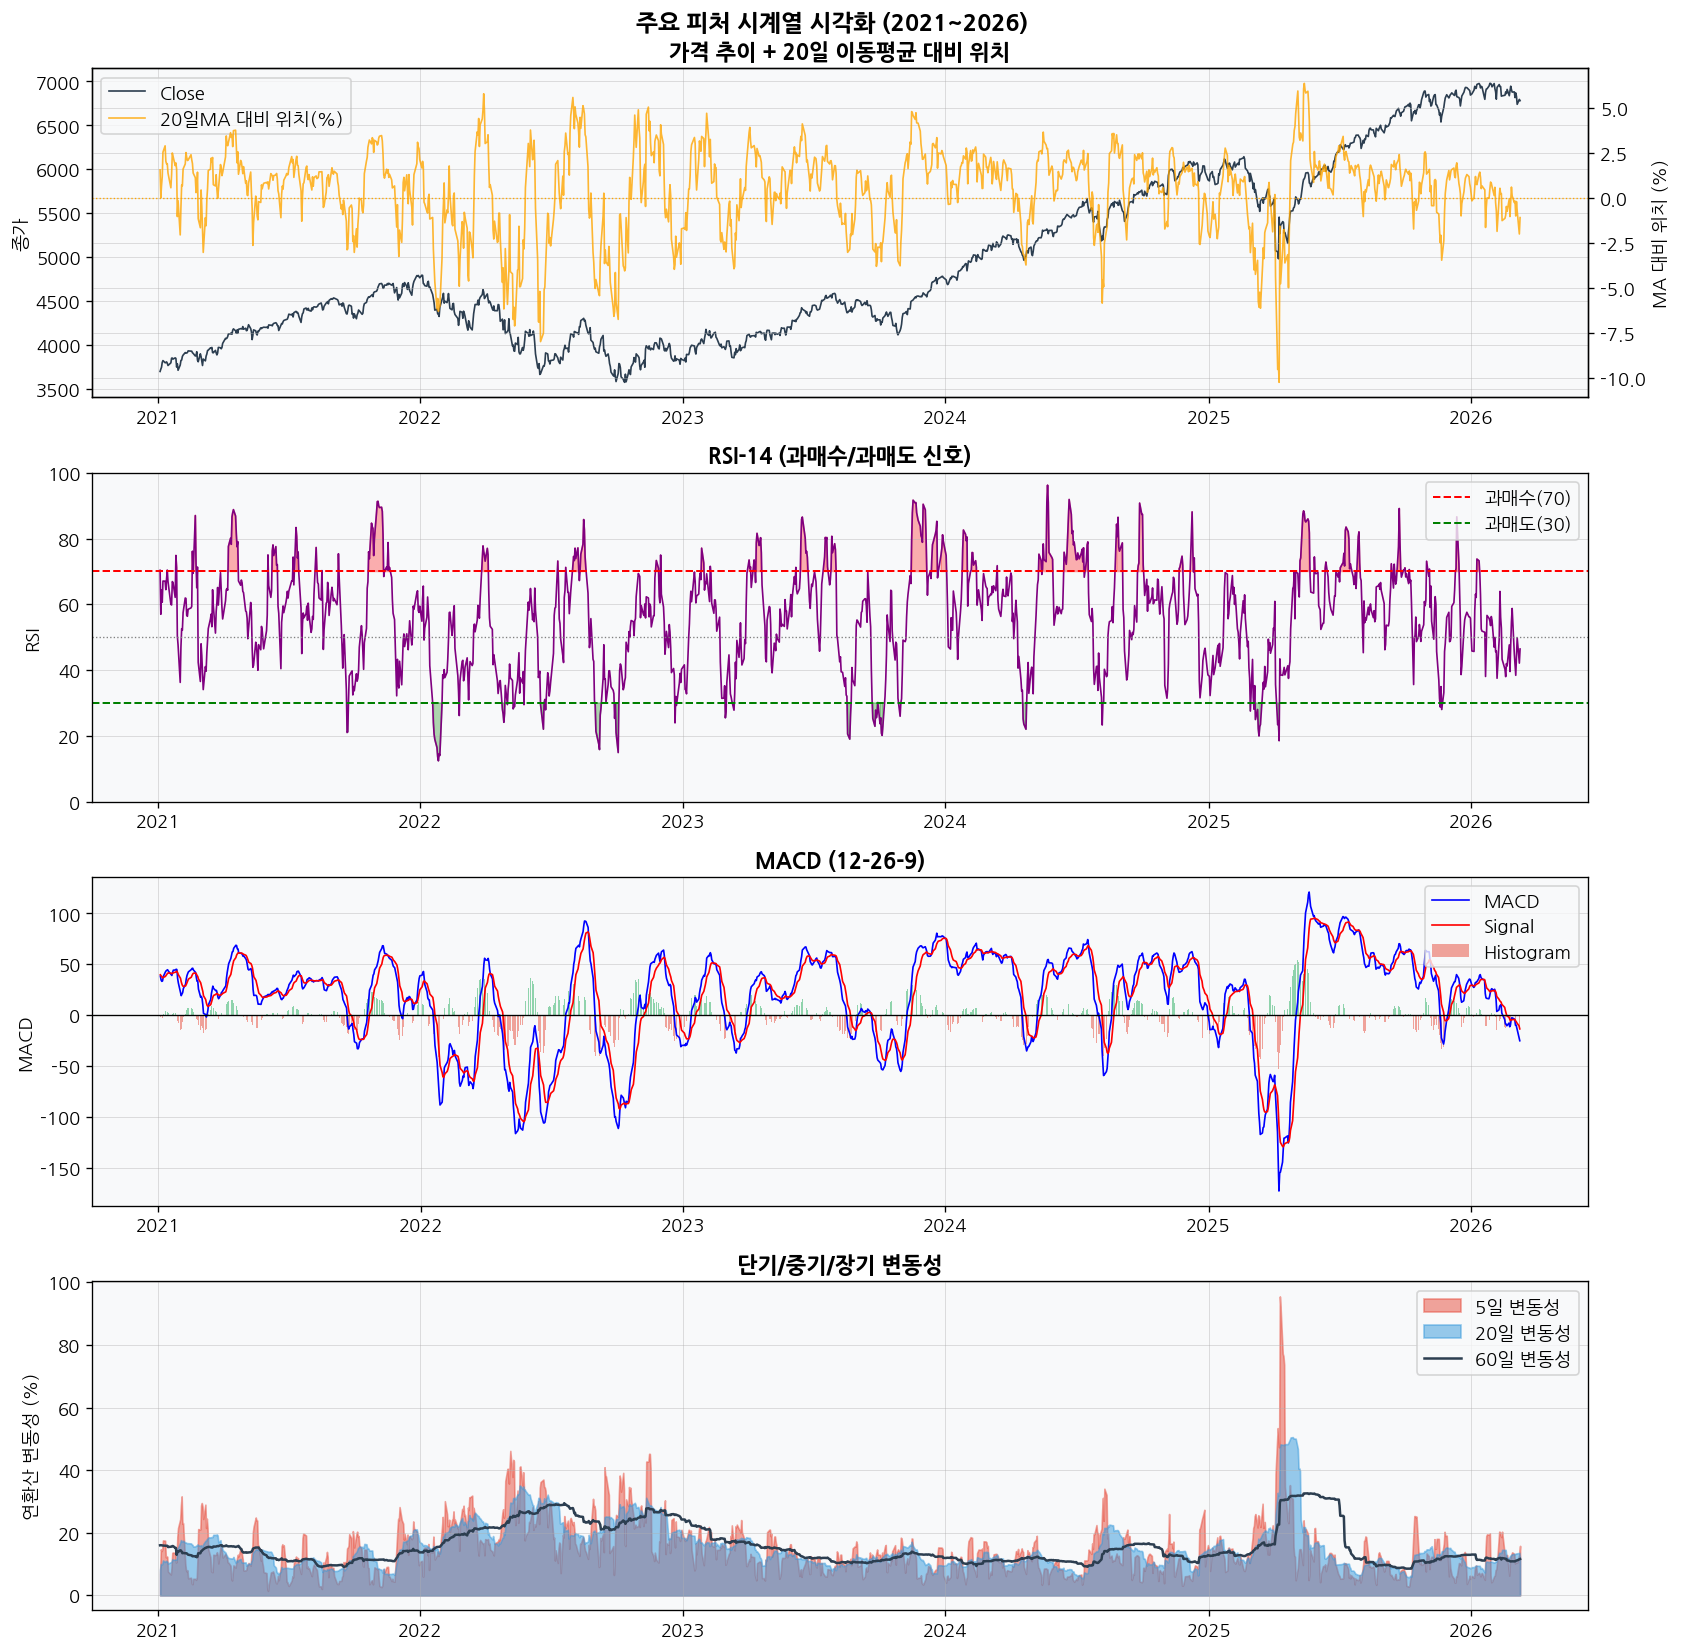

In [13]:
# ──────────────────────────────────────────────────────────────
# [셀 11] 피처 시각화 ① — 주요 피처 시계열
# ──────────────────────────────────────────────────────────────

# 최근 3년 데이터로 시각화 (전체는 너무 많아 안 보임)
recent = df_feat.loc['2021':].copy()

fig, axes = plt.subplots(4, 1, figsize=(14, 14))
fig.suptitle('주요 피처 시계열 시각화 (2021~2026)', fontsize=14, fontweight='bold')

# (1) 가격 + MA 비율
ax = axes[0]
ax2_twin = ax.twinx()
ax.plot(recent.index, recent['Close'], color='#2c3e50', linewidth=1, label='Close')
ax2_twin.plot(recent.index, recent['price_ma20_ratio']*100,
              color='orange', linewidth=1, alpha=0.8, label='20일MA 대비 위치(%)')
ax2_twin.axhline(0, color='orange', linestyle=':', linewidth=0.8)
ax.set_ylabel('종가'); ax2_twin.set_ylabel('MA 대비 위치 (%)')
ax.set_title('가격 추이 + 20일 이동평균 대비 위치')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# (2) RSI
ax = axes[1]
ax.plot(recent.index, recent['rsi_14'], color='purple', linewidth=1)
ax.axhline(70, color='red',   linestyle='--', linewidth=1.2, label='과매수(70)')
ax.axhline(30, color='green', linestyle='--', linewidth=1.2, label='과매도(30)')
ax.axhline(50, color='gray',  linestyle=':',  linewidth=0.8)
ax.fill_between(recent.index, recent['rsi_14'], 70,
                where=recent['rsi_14'] >= 70, alpha=0.3, color='red')
ax.fill_between(recent.index, recent['rsi_14'], 30,
                where=recent['rsi_14'] <= 30, alpha=0.3, color='green')
ax.set_ylabel('RSI'); ax.set_title('RSI-14 (과매수/과매도 신호)')
ax.legend(loc='upper right'); ax.set_ylim(0, 100)

# (3) MACD
ax = axes[2]
ax.plot(recent.index, recent['macd'],        color='blue',  linewidth=1,   label='MACD')
ax.plot(recent.index, recent['macd_signal'], color='red',   linewidth=1,   label='Signal')
ax.bar(recent.index,  recent['macd_hist'],
       color=['#27ae60' if v >= 0 else '#e74c3c' for v in recent['macd_hist']],
       alpha=0.5, label='Histogram')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('MACD'); ax.set_title('MACD (12-26-9)')
ax.legend(loc='upper right')

# (4) 변동성
ax = axes[3]
ax.fill_between(recent.index, recent['vol_5d']*100,
                alpha=0.5, color='#e74c3c', label='5일 변동성')
ax.fill_between(recent.index, recent['vol_20d']*100,
                alpha=0.5, color='#3498db', label='20일 변동성')
ax.plot(recent.index, recent['vol_60d']*100,
        color='#2c3e50', linewidth=1.5, label='60일 변동성')
ax.set_ylabel('연환산 변동성 (%)'); ax.set_title('단기/중기/장기 변동성')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/07_feature_timeseries.png', bbox_inches='tight')
plt.show()

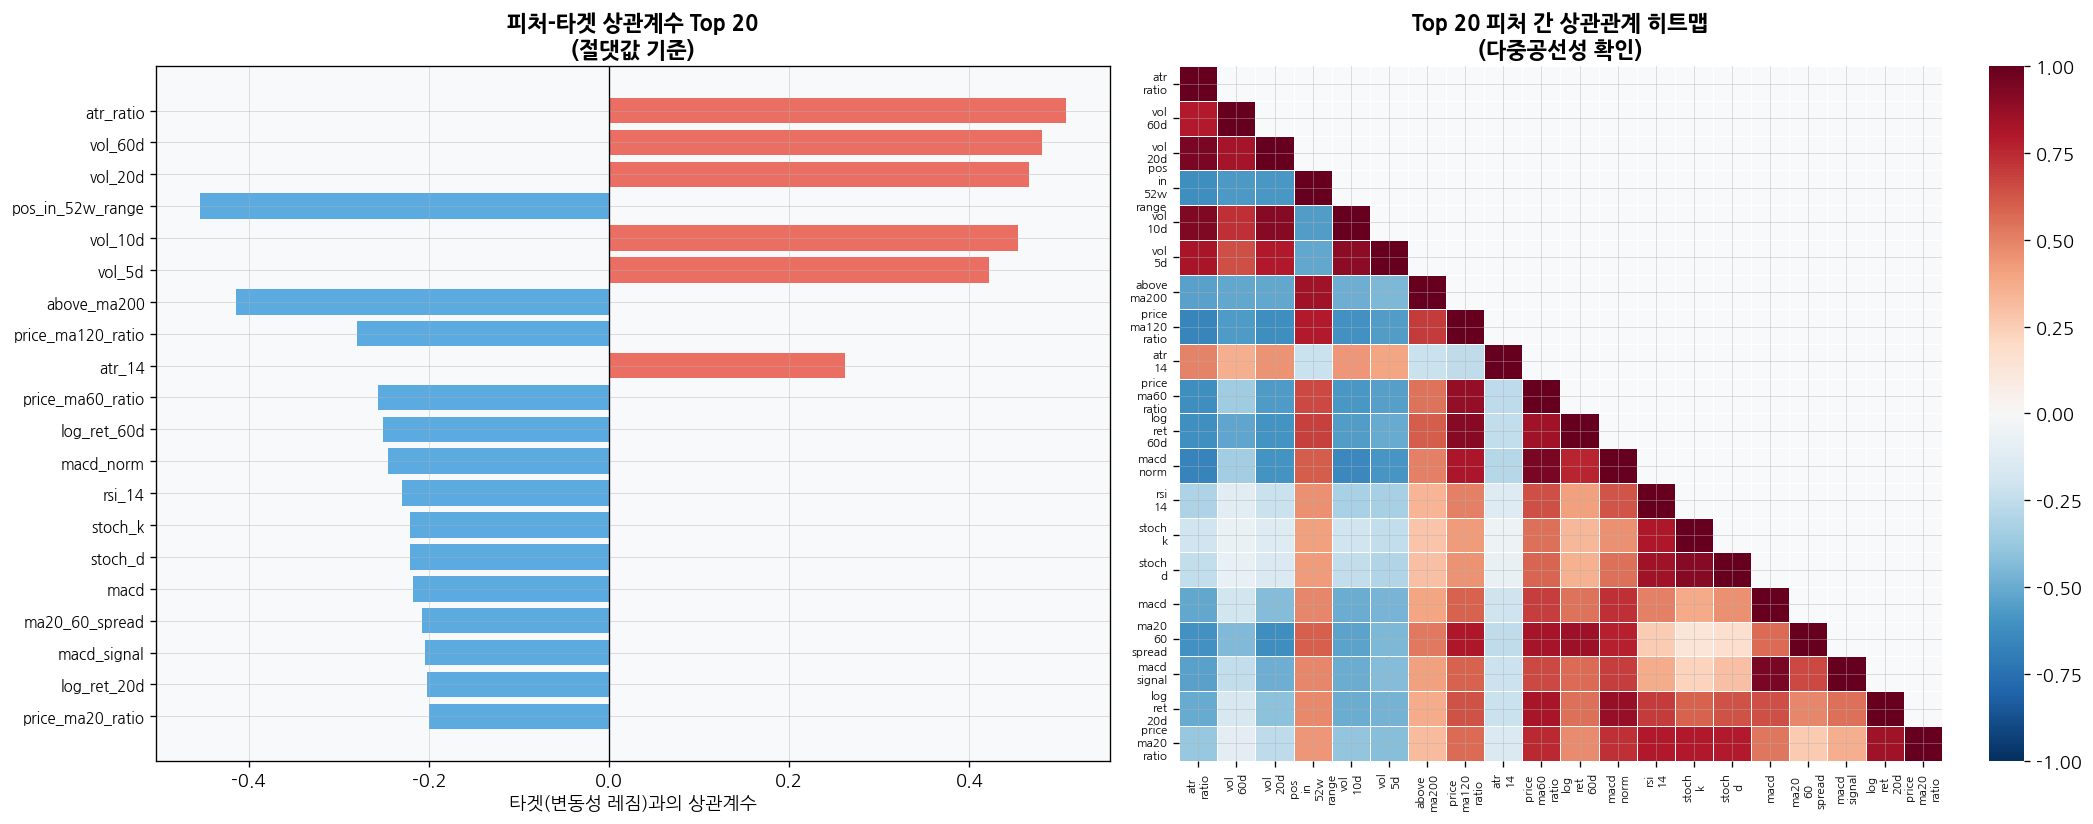

📊 타겟(변동성 레짐)과 상관관계 Top 10:
   atr_ratio                     : +0.5075
   vol_60d                       : +0.4809
   vol_20d                       : +0.4665
   pos_in_52w_range              : -0.4544
   vol_10d                       : +0.4542
   vol_5d                        : +0.4218
   above_ma200                   : -0.4141
   price_ma120_ratio             : -0.2804
   atr_14                        : +0.2619
   price_ma60_ratio              : -0.2561


In [14]:
# ──────────────────────────────────────────────────────────────
# [셀 12] 피처 시각화 ② — 피처 간 상관관계 히트맵
# ──────────────────────────────────────────────────────────────

df_model = df_feat.dropna(subset=feature_cols + ['target_vol', 'target_dir'])

# 상관관계 분석
corr_with_vol = (df_model[feature_cols]
                 .corrwith(df_model['target_vol'].astype(float))
                 .sort_values(key=abs, ascending=False))

# 상위 20개 피처 간 상관관계 히트맵
top20_cols = corr_with_vol.head(20).index.tolist()
corr_matrix = df_model[top20_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# (1) 상위 피처의 타겟 상관관계
ax = axes[0]
colors_corr = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_vol.head(20)]
ax.barh(range(20), corr_with_vol.head(20).values[::-1],
        color=colors_corr[::-1], alpha=0.8)
ax.set_yticks(range(20))
ax.set_yticklabels(corr_with_vol.head(20).index[::-1], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('타겟(변동성 레짐)과의 상관계수')
ax.set_title('피처-타겟 상관계수 Top 20\n(절댓값 기준)')

# (2) 피처 간 상관관계 히트맵
ax = axes[1]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix,
            mask=mask,
            annot=False,
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.3,
            ax=ax,
            xticklabels=[c.replace('_', '\n') for c in top20_cols],
            yticklabels=[c.replace('_', '\n') for c in top20_cols])
ax.set_title('Top 20 피처 간 상관관계 히트맵\n(다중공선성 확인)')
ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/08_feature_correlation.png', bbox_inches='tight')
plt.show()

print("📊 타겟(변동성 레짐)과 상관관계 Top 10:")
for feat_name, corr_val in corr_with_vol.head(10).items():
    print(f"   {feat_name:30s}: {corr_val:+.4f}")

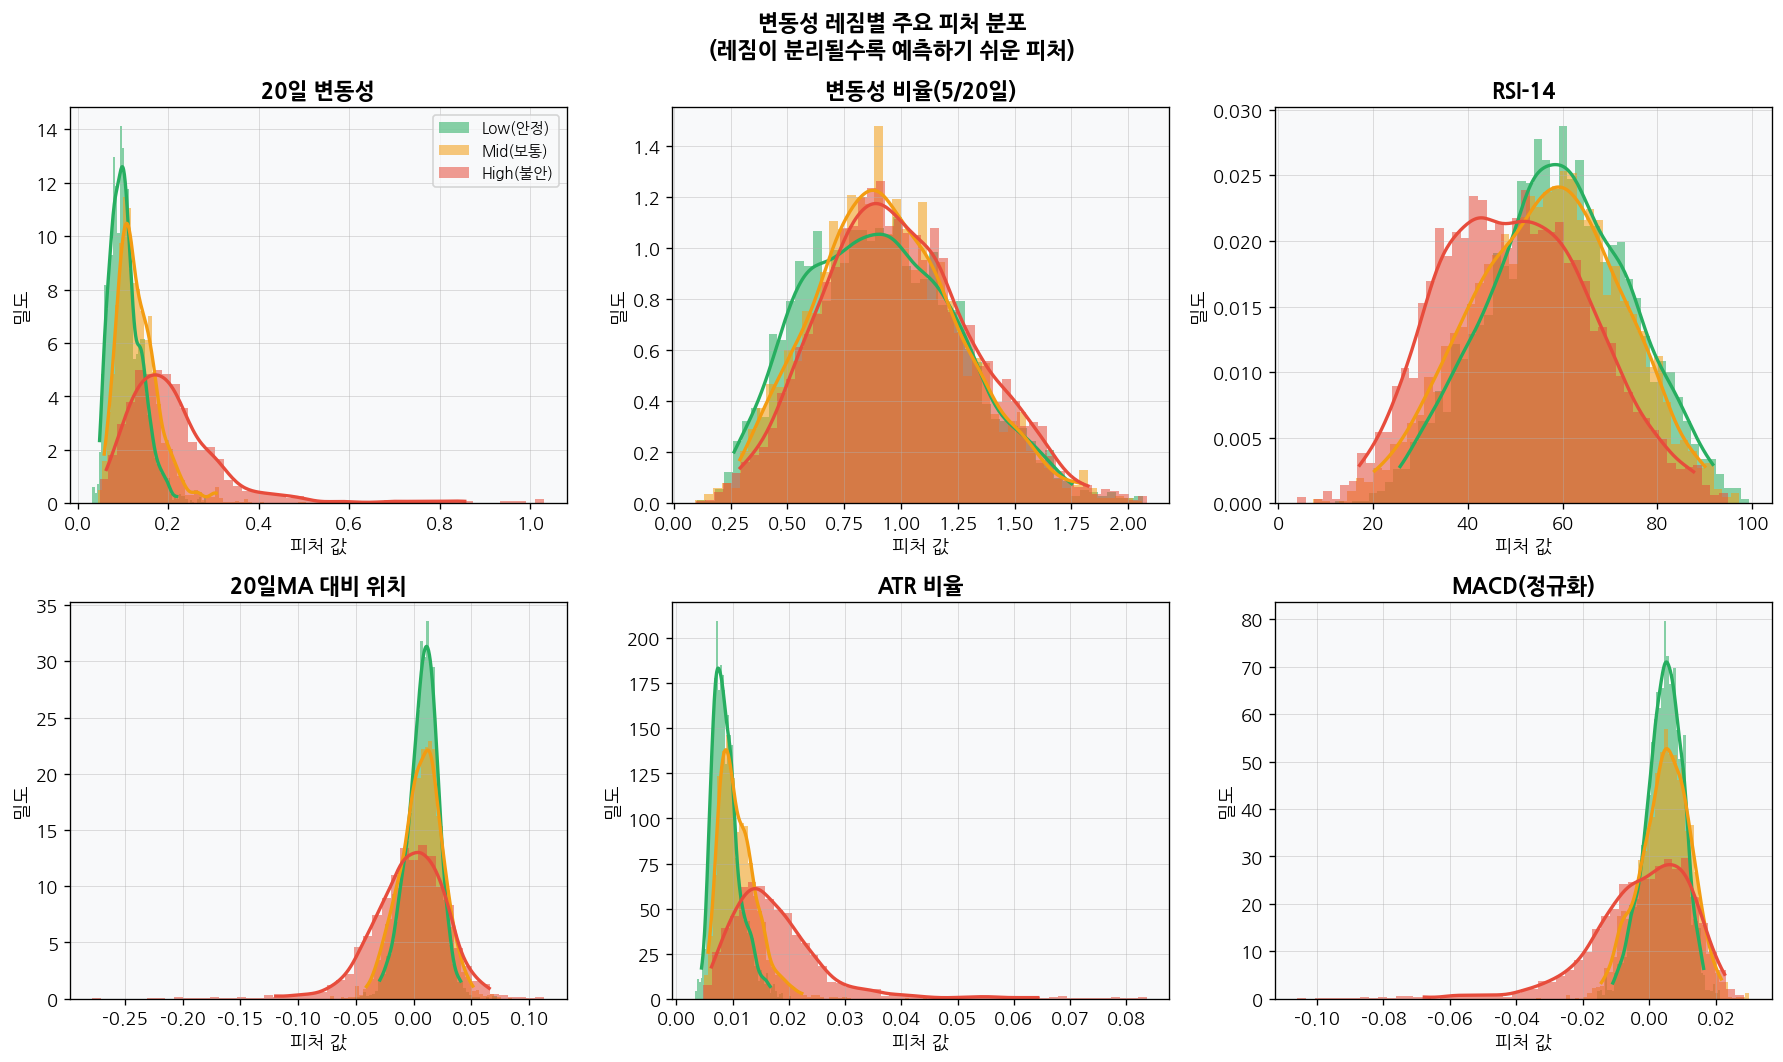

In [15]:
# ──────────────────────────────────────────────────────────────
# [셀 13] 피처 시각화 ③ — 레짐별 피처 분포 비교
# ──────────────────────────────────────────────────────────────

key_features = ['vol_20d', 'vol_ratio_5_20', 'rsi_14',
                'price_ma20_ratio', 'atr_ratio', 'macd_norm']
feat_labels  = ['20일 변동성', '변동성 비율(5/20일)', 'RSI-14',
                '20일MA 대비 위치', 'ATR 비율', 'MACD(정규화)']
regime_colors = {0: '#27ae60', 1: '#f39c12', 2: '#e74c3c'}
regime_names  = {0: 'Low(안정)', 1: 'Mid(보통)', 2: 'High(불안)'}

df_plot = df_model.dropna(subset=key_features)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('변동성 레짐별 주요 피처 분포\n(레짐이 분리될수록 예측하기 쉬운 피처)',
             fontsize=13, fontweight='bold')

for idx, (feat_name, feat_label) in enumerate(zip(key_features, feat_labels)):
    ax = axes[idx // 3][idx % 3]
    for regime_id in [0, 1, 2]:
        subset = df_plot[df_plot['target_vol'] == regime_id][feat_name].dropna()
        if len(subset) == 0:
            continue
        ax.hist(subset, bins=50, density=True, alpha=0.55,
                color=regime_colors[regime_id],
                label=regime_names[regime_id])
        # KDE 추가
        from scipy.stats import gaussian_kde
        if len(subset) > 10:
            kde = gaussian_kde(subset)
            x_range = np.linspace(subset.quantile(0.01),
                                   subset.quantile(0.99), 200)
            ax.plot(x_range, kde(x_range),
                    color=regime_colors[regime_id], linewidth=2)
    ax.set_title(feat_label)
    ax.set_xlabel('피처 값')
    ax.set_ylabel('밀도')
    if idx == 0:
        ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/09_feature_by_regime.png', bbox_inches='tight')
plt.show()

  Train / Validation / Test Split
  Train : 1983-12-30 ~ 2018-12-31 (8,824일 / 83.3%)
  Val   : 2019-01-02 ~ 2021-12-31 (757일 / 7.1%)
  Test  : 2022-01-03 ~ 2026-02-09 (1,009일 / 9.5%)


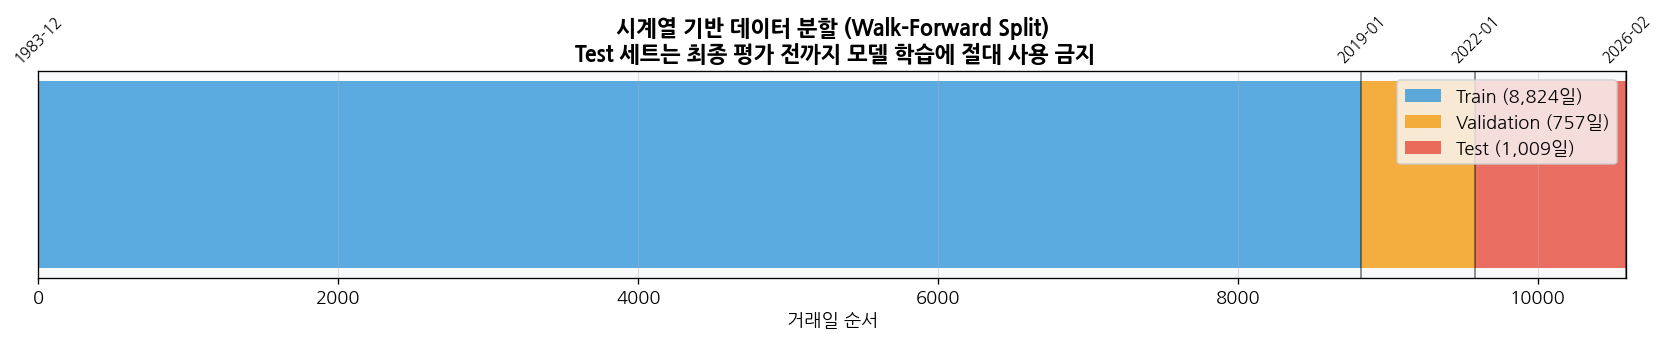

In [16]:
# ──────────────────────────────────────────────────────────────
# [셀 14] Train / Validation / Test Split (시계열 기반)
# ──────────────────────────────────────────────────────────────
# ⚠️ 절대 원칙: shuffle=False, 시간 순서 엄격히 유지

TRAIN_END = '2018-12-31'
VAL_END   = '2021-12-31'
# Test: 2022-01-01 ~ 2026-03-10 (최종 평가 전까지 절대 보지 않음)

df_model = df_feat.dropna(subset=feature_cols + ['target_vol', 'target_dir'])

X = df_model[feature_cols]
y_vol = df_model['target_vol'].astype(int)
y_dir = df_model['target_dir'].astype(int)

# 시간 기반 분할
train_mask = df_model.index <= TRAIN_END
val_mask   = (df_model.index > TRAIN_END) & (df_model.index <= VAL_END)
test_mask  = df_model.index > VAL_END

X_train, y_vol_train, y_dir_train = X[train_mask], y_vol[train_mask], y_dir[train_mask]
X_val,   y_vol_val,   y_dir_val   = X[val_mask],   y_vol[val_mask],   y_dir[val_mask]
X_test,  y_vol_test,  y_dir_test  = X[test_mask],  y_vol[test_mask],  y_dir[test_mask]

print("=" * 55)
print("  Train / Validation / Test Split")
print("=" * 55)
print(f"  Train : {X_train.index[0].date()} ~ {X_train.index[-1].date()} "
      f"({len(X_train):,}일 / {len(X_train)/len(X)*100:.1f}%)")
print(f"  Val   : {X_val.index[0].date()} ~ {X_val.index[-1].date()} "
      f"({len(X_val):,}일 / {len(X_val)/len(X)*100:.1f}%)")
print(f"  Test  : {X_test.index[0].date()} ~ {X_test.index[-1].date()} "
      f"({len(X_test):,}일 / {len(X_test)/len(X)*100:.1f}%)")

# 분할 시각화
fig, ax = plt.subplots(figsize=(14, 3))
ax.barh(0, len(X_train), left=0,         height=0.5,
        color='#3498db', alpha=0.8, label=f'Train ({len(X_train):,}일)')
ax.barh(0, len(X_val),   left=len(X_train), height=0.5,
        color='#f39c12', alpha=0.8, label=f'Validation ({len(X_val):,}일)')
ax.barh(0, len(X_test),  left=len(X_train)+len(X_val), height=0.5,
        color='#e74c3c', alpha=0.8, label=f'Test ({len(X_test):,}일)')
ax.set_xlim(0, len(X))
ax.set_yticks([])
ax.set_xlabel('거래일 순서')
ax.set_title('시계열 기반 데이터 분할 (Walk-Forward Split)\n'
             ' Test 세트는 최종 평가 전까지 모델 학습에 절대 사용 금지')
ax.legend(loc='upper right')
# 날짜 레이블
for pos, label in [
    (0, X_train.index[0].strftime('%Y-%m')),
    (len(X_train), X_val.index[0].strftime('%Y-%m')),
    (len(X_train)+len(X_val), X_test.index[0].strftime('%Y-%m')),
    (len(X)-1, X_test.index[-1].strftime('%Y-%m')),
]:
    ax.axvline(pos, color='black', linewidth=1, alpha=0.5)
    ax.text(pos, 0.3, label, ha='center', fontsize=9, rotation=45)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/10_train_val_test_split.png', bbox_inches='tight')
plt.show()

In [17]:
# ──────────────────────────────────────────────────────────────
# [셀 15] 피처 스케일링 및 최종 데이터 준비
# ──────────────────────────────────────────────────────────────

from sklearn.preprocessing import StandardScaler

# Train 기준으로 scaler 학습 → Val/Test에는 transform만
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# DataFrame으로 복원 (피처 이름 유지)
X_train_sc = pd.DataFrame(X_train_sc, columns=feature_cols, index=X_train.index)
X_val_sc   = pd.DataFrame(X_val_sc,   columns=feature_cols, index=X_val.index)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=feature_cols, index=X_test.index)

# 무한값, NaN 최종 확인
for name, X_chk in [('Train', X_train_sc), ('Val', X_val_sc), ('Test', X_test_sc)]:
    nan_cnt = X_chk.isna().sum().sum()
    inf_cnt = np.isinf(X_chk.values).sum()
    print(f"  {name}: NaN={nan_cnt}, Inf={inf_cnt}")

print("\n 스케일링 완료")
print(f"   Train shape : {X_train_sc.shape}")
print(f"   Val shape   : {X_val_sc.shape}")
print(f"   Test shape  : {X_test_sc.shape}")
print(f"\n 주의: 스케일링에 사용한 scaler는 Val/Test에 transform만 적용")
print("   → Train의 평균/분산 정보만 사용 (leakage 방지)")

  Train: NaN=0, Inf=0
  Val: NaN=0, Inf=0
  Test: NaN=0, Inf=0

 스케일링 완료
   Train shape : (8824, 38)
   Val shape   : (757, 38)
   Test shape  : (1009, 38)

 주의: 스케일링에 사용한 scaler는 Val/Test에 transform만 적용
   → Train의 평균/분산 정보만 사용 (leakage 방지)


In [18]:
# ──────────────────────────────────────────────────────────────
# [셀 16] 최종 데이터 저장 (다음 노트북에서 불러올 수 있게)
# ──────────────────────────────────────────────────────────────

import pickle

# CSV 저장
X_train_sc.assign(target_vol=y_vol_train,
                  target_dir=y_dir_train).to_csv('train_data.csv')
X_val_sc.assign(target_vol=y_vol_val,
                target_dir=y_dir_val).to_csv('val_data.csv')
X_test_sc.assign(target_vol=y_vol_test,
                 target_dir=y_dir_test).to_csv('test_data.csv')

# Scaler 저장
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 피처 목록 저장
with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print(" 저장 완료:")
print("   - train_data.csv")
print("   - val_data.csv")
print("   - test_data.csv")
print("   - scaler.pkl")
print("   - feature_cols.pkl")

 저장 완료:
   - train_data.csv
   - val_data.csv
   - test_data.csv
   - scaler.pkl
   - feature_cols.pkl


In [19]:
# ──────────────────────────────────────────────────────────────
# [셀 17] 전체 EDA 요약 출력 (보고서에 바로 쓸 수 있는 텍스트)
# ──────────────────────────────────────────────────────────────

print("""
╔══════════════════════════════════════════════════════════════╗
║              EDA & Feature Engineering 요약                 ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. 데이터 품질                                               ║
║     - 원본: 24,663행 (1927~2026)                             ║
║     - 1983 이전: OHLC 거의 동일 → 실질적으로 Close만 존재     ║
║     - 분석 채택: 1983년 이후 10,882행                        ║
║                                                              ║
║  2. 수익률 특성                                               ║
║     - 연환산 수익률: ~8.3% / 연환산 변동성: ~16.9%           ║
║     - 음의 왜도: 하락 꼬리가 더 두꺼움 (Fat Tail)             ║
║     - 높은 첨도: 극단적 움직임 빈번 (비정규 분포)             ║
║     - ADF 검정: 로그수익률은 정상 시계열 (p < 0.001)          ║
║                                                              ║
║  3. 예측 난이도 비교                                          ║
║     - 방향성 (2클래스): 베이스라인 53.8% → 개선 여지 좁음     ║
║     - 변동성 레짐 (3클래스): 베이스라인 33.3% → 여지 넓음     ║
║     - |수익률| 자기상관 유의: 변동성 군집 패턴 존재           ║
║                                                              ║
║  4. 생성 피처: 총 36개 (7개 그룹)                             ║
║     - 수익률(5), MA 비율/스프레드(7), 변동성(8)              ║
║     - 모멘텀(7), 거래량(5), 캔들패턴(3), 시장상태(2)         ║
║     - 전 부 shift(1) 적용 → Data Leakage 없음                 ║
║                                                              ║
║  5. 데이터 분할                                               ║
║     - Train: 1983~2018 / Val: 2019~2021 / Test: 2022~2026   ║
║     - 시계열 순서 유지 (shuffle 없음)                         ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║              EDA & Feature Engineering 요약                 ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. 데이터 품질                                               ║
║     - 원본: 24,663행 (1927~2026)                             ║
║     - 1983 이전: OHLC 거의 동일 → 실질적으로 Close만 존재     ║
║     - 분석 채택: 1983년 이후 10,882행                        ║
║                                                              ║
║  2. 수익률 특성                                               ║
║     - 연환산 수익률: ~8.3% / 연환산 변동성: ~16.9%           ║
║     - 음의 왜도: 하락 꼬리가 더 두꺼움 (Fat Tail)             ║
║     - 높은 첨도: 극단적 움직임 빈번 (비정규 분포)             ║
║     - ADF 검정: 로그수익률은 정상 시계열 (p < 0.001)          ║
║                                                              ║
║  3. 예측 난이도 비교                                          ║
║     - 방향성 (2클래스): 베이스라인 53.8% → 개선 여지 좁음     ║
║  

In [20]:
# ============================================================
# S&P 500 변동성 레짐 분류 프로젝트
# 파일: 02_Modeling_Colab.py
# 실행 전제: 01_EDA_FeatureEngineering.py 실행 완료
#           (train_data.csv / val_data.csv / test_data.csv 생성된 상태)
# ============================================================


# ──────────────────────────────────────────────────────────────
# [셀 1] 라이브러리 로드 및 데이터 불러오기
# ──────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import os
import time

# sklearn 모델
from sklearn.naive_bayes       import GaussianNB
from sklearn.linear_model      import LogisticRegression
from sklearn.svm               import SVC
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.tree              import DecisionTreeClassifier, export_text
from sklearn.ensemble          import RandomForestClassifier
from sklearn.neural_network    import MLPClassifier
from sklearn.dummy             import DummyClassifier
from sklearn.pipeline          import Pipeline
from sklearn.preprocessing     import StandardScaler
from sklearn.model_selection   import TimeSeriesSplit, cross_val_score
from sklearn.inspection        import permutation_importance

# 평가 지표
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score
)

# ── 경로 설정 ──────────────────────────────────────────────
DATA_DIR = '.'          # csv 파일 위치 (EDA 노트북 실행 결과)
FIG_DIR  = './figures'
os.makedirs(FIG_DIR, exist_ok=True)

# ── 시각화 스타일 ──────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 120,
    'figure.facecolor': 'white',
    'axes.facecolor'  : '#f8f9fa',
    'axes.grid'       : True,
    'grid.alpha'      : 0.4,
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
})

# ── 데이터 로드 ────────────────────────────────────────────
train_df = pd.read_csv(f'{DATA_DIR}/train_data.csv', index_col=0, parse_dates=True)
val_df   = pd.read_csv(f'{DATA_DIR}/val_data.csv',   index_col=0, parse_dates=True)
test_df  = pd.read_csv(f'{DATA_DIR}/test_data.csv',  index_col=0, parse_dates=True)

with open(f'{DATA_DIR}/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

# X / y 분리
X_train = train_df[feature_cols]
X_val   = val_df[feature_cols]
X_test  = test_df[feature_cols]

y_vol_train = train_df['target_vol'].astype(int)
y_vol_val   = val_df['target_vol'].astype(int)
y_vol_test  = test_df['target_vol'].astype(int)

y_dir_train = train_df['target_dir'].astype(int)
y_dir_val   = val_df['target_dir'].astype(int)
y_dir_test  = test_df['target_dir'].astype(int)

# Train+Val 합친 버전 (최종 테스트 직전 재학습용)
X_trainval   = pd.concat([X_train, X_val])
y_vol_trainval = pd.concat([y_vol_train, y_vol_val])
y_dir_trainval = pd.concat([y_dir_train, y_dir_val])

print("=" * 55)
print("  데이터 로드 완료")
print("=" * 55)
print(f"  Train  : {X_train.shape}  ({X_train.index[0].date()}~{X_train.index[-1].date()})")
print(f"  Val    : {X_val.shape}  ({X_val.index[0].date()}~{X_val.index[-1].date()})")
print(f"  Test   : {X_test.shape}  ({X_test.index[0].date()}~{X_test.index[-1].date()})")
print(f"  피처 수 : {len(feature_cols)}개")
print(f"\n  변동성 레짐 분포 (Train)")
for k, v in y_vol_train.value_counts().sort_index().items():
    label = {0:'Low(안정)', 1:'Mid(보통)', 2:'High(불안)'}[k]
    print(f"    {label}: {v:,}행 ({v/len(y_vol_train)*100:.1f}%)")

  데이터 로드 완료
  Train  : (8824, 38)  (1983-12-30~2018-12-31)
  Val    : (757, 38)  (2019-01-02~2021-12-31)
  Test   : (1009, 38)  (2022-01-03~2026-02-09)
  피처 수 : 38개

  변동성 레짐 분포 (Train)
    Low(안정): 3,052행 (34.6%)
    Mid(보통): 2,854행 (32.3%)
    High(불안): 2,918행 (33.1%)


In [21]:
# ──────────────────────────────────────────────────────────────
# [셀 2] 공통 평가 함수 정의
# ──────────────────────────────────────────────────────────────

REGIME_LABELS = {0: 'Low(안정)', 1: 'Mid(보통)', 2: 'High(불안)'}
REGIME_COLORS = {0: '#27ae60',   1: '#f39c12',   2: '#e74c3c'}

def evaluate_model(name, y_true, y_pred, target_type='vol',
                   show_report=True, figdir=FIG_DIR):
    """
    분류 모델 통합 평가 함수
    - Accuracy, Precision, Recall, F1 (macro/weighted)
    - Confusion Matrix 시각화
    - 금융 관점 해석 출력
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1m  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1w  = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    if show_report:
        print(f"\n{'='*50}")
        print(f"  [{name}] 평가 결과")
        print(f"{'='*50}")
        print(f"  Accuracy         : {acc*100:.2f}%")
        print(f"  Precision (macro): {prec*100:.2f}%")
        print(f"  Recall    (macro): {rec*100:.2f}%")
        print(f"  F1        (macro): {f1m*100:.2f}%")
        print(f"  F1     (weighted): {f1w*100:.2f}%")

        if target_type == 'vol':
            # 클래스별 F1
            f1_per = f1_score(y_true, y_pred, average=None, zero_division=0)
            print(f"\n  클래스별 F1:")
            for i, f in enumerate(f1_per):
                print(f"    {REGIME_LABELS[i]}: {f*100:.2f}%")

            # 금융 관점 해석
            if len(f1_per) > 2:
                high_f1 = f1_per[2]
                print(f"\n   금융 해석:")
                print(f"     High(불안) 레짐 F1 = {high_f1*100:.2f}%")
                if high_f1 > 0.5:
                    print("     → 불안 시장 사전 감지 능력 양호 (리스크 관리 활용 가능)")
                elif high_f1 > 0.3:
                    print("     → 불안 시장 감지 능력 보통 (일부 위기 포착 가능)")
                else:
                    print("     → 불안 시장 감지 능력 낮음 (위기 대응에 한계)")

        if show_report:
            print(f"\n  Classification Report:")
            if target_type == 'vol':
                target_names = ['Low(안정)', 'Mid(보통)', 'High(불안)']
            else:
                target_names = ['하락(0)', '상승(1)']
            print(classification_report(y_true, y_pred,
                                        target_names=target_names,
                                        zero_division=0))

    # Confusion Matrix 시각화
    cm = confusion_matrix(y_true, y_pred)
    n_classes = cm.shape[0]

    fig, ax = plt.subplots(figsize=(5, 4))
    if target_type == 'vol':
        xlabels = ylabels = ['Low', 'Mid', 'High']
        cmap = 'YlOrRd'
    else:
        xlabels = ylabels = ['하락', '상승']
        cmap = 'Blues'

    # 정규화된 CM
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=xlabels, yticklabels=ylabels,
                ax=ax, vmin=0, vmax=1, linewidths=0.5)

    # 실제 개수도 표시
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j + 0.5, i + 0.72, f'({cm[i,j]})',
                    ha='center', va='center', fontsize=8, color='gray')

    ax.set_xlabel('예측값', fontsize=11)
    ax.set_ylabel('실제값', fontsize=11)
    ax.set_title(f'{name}\nAccuracy={acc*100:.1f}% | F1(macro)={f1m*100:.1f}%',
                 fontsize=11)
    plt.tight_layout()
    safe_name = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'{figdir}/cm_{safe_name}.png', bbox_inches='tight')
    plt.show()

    return {
        'Model'    : name,
        'Accuracy' : round(acc  * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall'   : round(rec  * 100, 2),
        'F1_macro' : round(f1m  * 100, 2),
        'F1_weighted': round(f1w * 100, 2),
    }


  BASELINE: Dummy Classifier
  전략 1: most_frequent (가장 많은 클래스만 예측)
  전략 2: stratified (클래스 비율대로 랜덤 예측)
  → 이 수치를 넘지 못하는 모델은 의미 없음



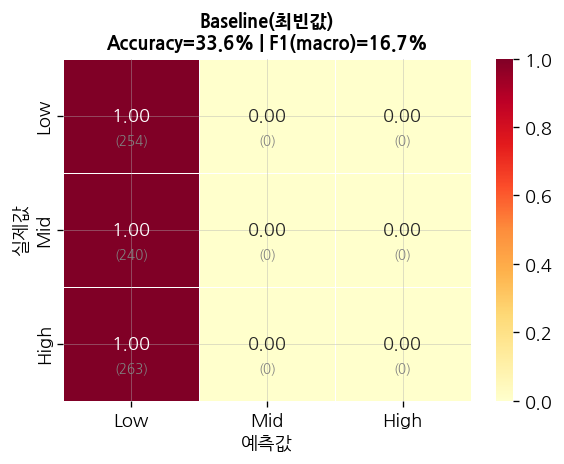

  Baseline(최빈값) → Accuracy: 33.55% | F1: 16.75%


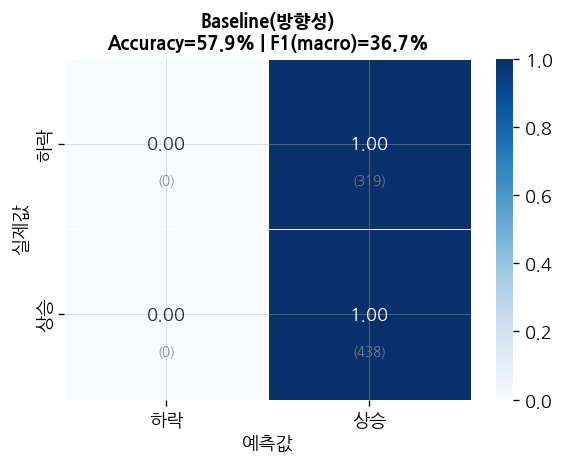

  Baseline(방향성) → Accuracy: 57.86% | F1: 36.65%

   핵심: 변동성 레짐 베이스라인 F1 = 16.75%
          방향성 베이스라인 Accuracy  = 57.86%
          → 변동성 레짐이 개선 여지가 더 넓음을 수치로 확인


In [22]:
# ──────────────────────────────────────────────────────────────
# [셀 3] Baseline — Dummy Classifier
# (모든 모델의 비교 기준점)
# ──────────────────────────────────────────────────────────────
#
# [선택 이유]
# 베이스라인 없이 모델 성능을 논하는 것은 의미가 없다.
# "우리 모델이 찍는 것보다 얼마나 나은가?"를 정량화하는 기준선.
# → 변동성 레짐: 무조건 하나만 찍으면 33.3% → 이를 반드시 넘어야 의미 있음

print("\n" + "="*55)
print("  BASELINE: Dummy Classifier")
print("="*55)
print("  전략 1: most_frequent (가장 많은 클래스만 예측)")
print("  전략 2: stratified (클래스 비율대로 랜덤 예측)")
print("  → 이 수치를 넘지 못하는 모델은 의미 없음\n")

results_vol = []   # 변동성 레짐 결과 저장
results_dir = []   # 방향성 결과 저장

# ── Baseline 1: most_frequent ──────────────────────────────
dummy_mf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_mf.fit(X_train, y_vol_train)
pred_dummy_mf = dummy_mf.predict(X_val)
res = evaluate_model('Baseline(최빈값)', y_vol_val, pred_dummy_mf,
                     target_type='vol', show_report=False, figdir=FIG_DIR)
results_vol.append(res)
print(f"  Baseline(최빈값) → Accuracy: {res['Accuracy']}% | F1: {res['F1_macro']}%")

# 방향성 베이스라인
dummy_mf_dir = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_mf_dir.fit(X_train, y_dir_train)
pred_dummy_dir = dummy_mf_dir.predict(X_val)
res_dir = evaluate_model('Baseline(방향성)', y_dir_val, pred_dummy_dir,
                         target_type='dir', show_report=False, figdir=FIG_DIR)
results_dir.append(res_dir)
print(f"  Baseline(방향성) → Accuracy: {res_dir['Accuracy']}% | F1: {res_dir['F1_macro']}%")

print(f"\n   핵심: 변동성 레짐 베이스라인 F1 = {res['F1_macro']}%")
print(f"          방향성 베이스라인 Accuracy  = {res_dir['Accuracy']}%")
print(f"          → 변동성 레짐이 개선 여지가 더 넓음을 수치로 확인")


  MODEL 1: Naive Bayes
  가정: 피처들이 서로 독립적 (현실에서는 성립하기 어려움)
  기대: 피처 간 상관이 강한 금융 데이터에서 성능 제한적


  [Naive Bayes (변동성)] 평가 결과
  Accuracy         : 46.24%
  Precision (macro): 39.58%
  Recall    (macro): 45.03%
  F1        (macro): 38.49%
  F1     (weighted): 39.33%

  클래스별 F1:
    Low(안정): 50.40%
    Mid(보통): 6.38%
    High(불안): 58.70%

   금융 해석:
     High(불안) 레짐 F1 = 58.70%
     → 불안 시장 사전 감지 능력 양호 (리스크 관리 활용 가능)

  Classification Report:
              precision    recall  f1-score   support

     Low(안정)       0.52      0.49      0.50       254
     Mid(보통)       0.21      0.04      0.06       240
    High(불안)       0.46      0.82      0.59       263

    accuracy                           0.46       757
   macro avg       0.40      0.45      0.38       757
weighted avg       0.40      0.46      0.39       757



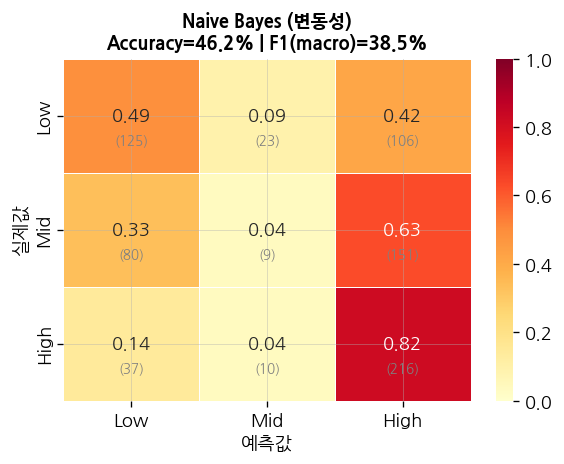

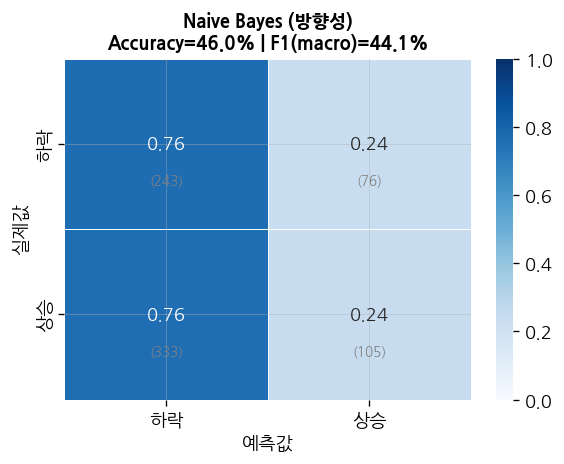

In [23]:
# ──────────────────────────────────────────────────────────────
# [셀 4] Model 1 — Naive Bayes
# ──────────────────────────────────────────────────────────────
#
# [이론] 베이즈 정리 기반. 각 피처가 클래스 주어졌을 때 조건부 독립이라 가정.
#        P(y|X) ∝ P(y) × ∏ P(xᵢ|y)
#
# [선택 이유]
# - 가장 단순한 확률적 분류 모델 → 복잡한 모델과의 비교 기준
# - 피처 간 독립 가정이 금융 데이터에서 성립하기 어려움
#   → 예상: 성능이 낮게 나옴 → "피처 간 상관관계의 중요성" 논증
# - 계산이 매우 빠름 → 대규모 피처셋에서도 즉시 실행 가능
#
# [금융 관점]
# 변동성 피처들은 서로 강하게 상관 (vol_5d ↔ vol_20d 등)
# → Naive Bayes의 독립 가정이 깨짐 → 성능 한계를 보여주는 모델

print("\n" + "="*55)
print("  MODEL 1: Naive Bayes")
print("="*55)
print("  가정: 피처들이 서로 독립적 (현실에서는 성립하기 어려움)")
print("  기대: 피처 간 상관이 강한 금융 데이터에서 성능 제한적\n")

# 변동성 레짐
nb_vol = GaussianNB()
t0 = time.time()
nb_vol.fit(X_train, y_vol_train)
train_time = time.time() - t0
pred_nb_vol = nb_vol.predict(X_val)
res = evaluate_model('Naive Bayes (변동성)', y_vol_val, pred_nb_vol,
                     target_type='vol', figdir=FIG_DIR)
res['Train_Time'] = round(train_time, 3)
results_vol.append(res)

# 방향성 (서브 비교용)
nb_dir = GaussianNB()
nb_dir.fit(X_train, y_dir_train)
pred_nb_dir = nb_dir.predict(X_val)
res_dir = evaluate_model('Naive Bayes (방향성)', y_dir_val, pred_nb_dir,
                         target_type='dir', show_report=False, figdir=FIG_DIR)
results_dir.append(res_dir)


  MODEL 2: Logistic Regression — L2 (Ridge)
  L2: 모든 계수를 축소, 과적합 방지, 안정적 선형 모델


  [Logistic L2 (변동성)] 평가 결과
  Accuracy         : 46.76%
  Precision (macro): 48.66%
  Recall    (macro): 45.45%
  F1        (macro): 36.86%
  F1     (weighted): 37.77%

  클래스별 F1:
    Low(안정): 50.10%
    Mid(보통): 1.64%
    High(불안): 58.84%

   금융 해석:
     High(불안) 레짐 F1 = 58.84%
     → 불안 시장 사전 감지 능력 양호 (리스크 관리 활용 가능)

  Classification Report:
              precision    recall  f1-score   support

     Low(안정)       0.51      0.49      0.50       254
     Mid(보통)       0.50      0.01      0.02       240
    High(불안)       0.45      0.87      0.59       263

    accuracy                           0.47       757
   macro avg       0.49      0.45      0.37       757
weighted avg       0.49      0.47      0.38       757



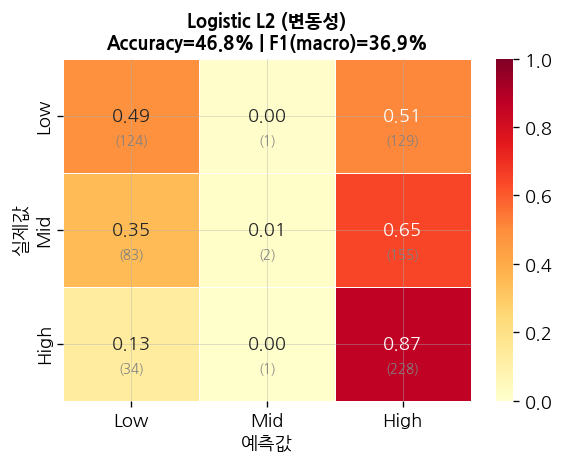

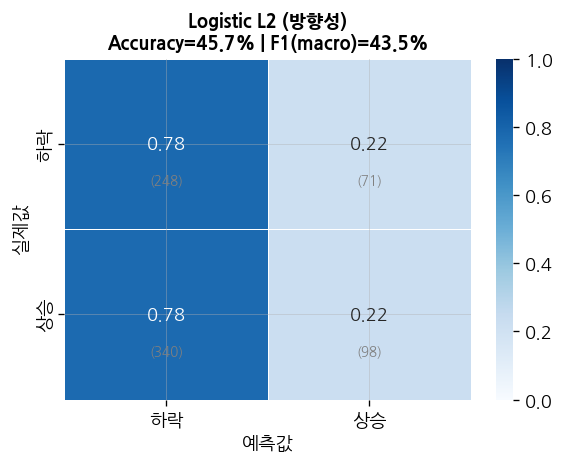


  MODEL 3: Logistic Regression — L1 (Lasso)
  L1: 중요하지 않은 피처 계수를 0으로 → 자동 피처 선택


  [Logistic L1 (변동성)] 평가 결과
  Accuracy         : 48.08%
  Precision (macro): 47.86%
  Recall    (macro): 46.83%
  F1        (macro): 39.03%
  F1     (weighted): 39.91%

  클래스별 F1:
    Low(안정): 52.57%
    Mid(보통): 4.74%
    High(불안): 59.78%

   금융 해석:
     High(불안) 레짐 F1 = 59.78%
     → 불안 시장 사전 감지 능력 양호 (리스크 관리 활용 가능)

  Classification Report:
              precision    recall  f1-score   support

     Low(안정)       0.51      0.54      0.53       254
     Mid(보통)       0.46      0.03      0.05       240
    High(불안)       0.47      0.84      0.60       263

    accuracy                           0.48       757
   macro avg       0.48      0.47      0.39       757
weighted avg       0.48      0.48      0.40       757



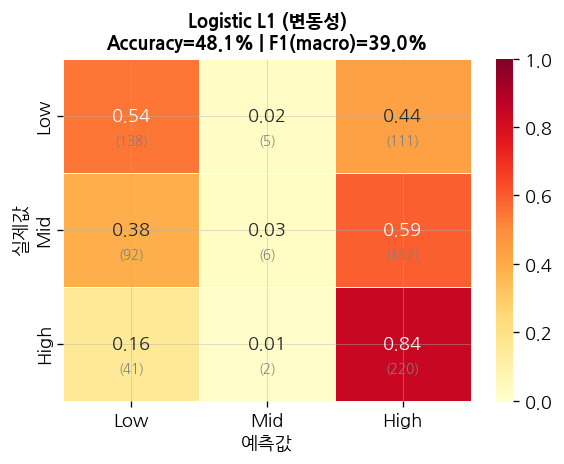

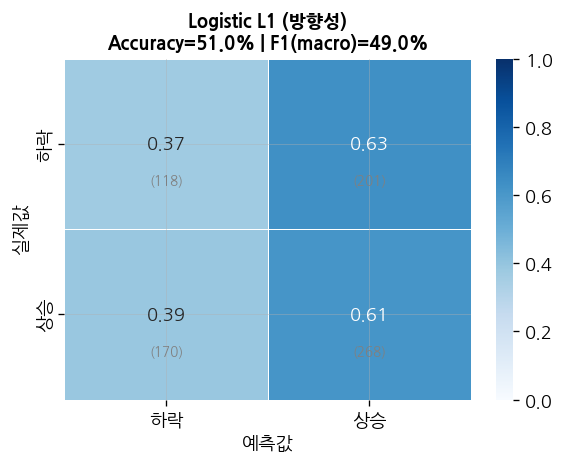


  [L1 피처 선택 결과]
  Low(안정): 19/38개 피처 선택됨
  Mid(보통): 10/38개 피처 선택됨
  High(불안): 19/38개 피처 선택됨


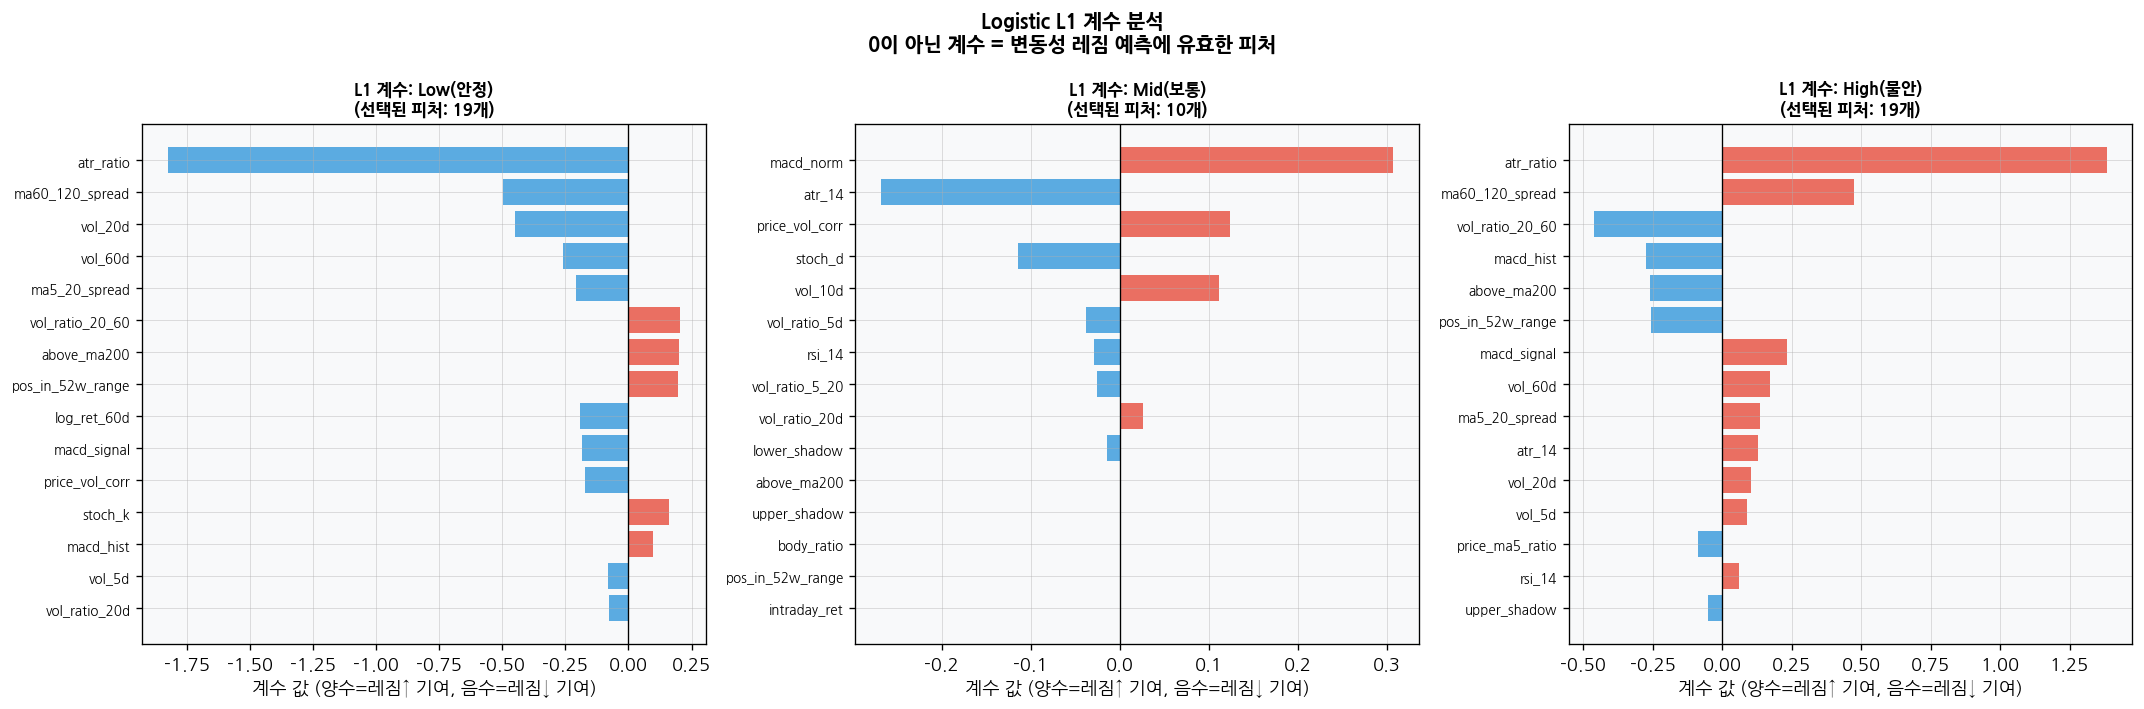

In [24]:
# ──────────────────────────────────────────────────────────────
# [셀 5] Model 2 & 3 — Logistic Regression (L1 / L2)
# ──────────────────────────────────────────────────────────────
#
# [이론] 로그 오즈(log-odds)의 선형 결합으로 클래스 확률 추정.
#        L1 (Lasso): 일부 계수를 정확히 0으로 → 자동 피처 선택
#        L2 (Ridge): 모든 계수를 0에 가깝게 축소 → 과적합 방지
#        다중 클래스: One-vs-Rest (OvR) 전략 적용
#
# [선택 이유]
# - 선형 결정 경계가 실제로 유효한지 검증
# - L1: 38개 피처 중 실제로 중요한 것만 자동 선별 → 피처 해석
# - L2: 안정적인 선형 기준 모델
# - 계수(coef_) 해석 가능 → 금융 변수 중요도 직접 확인
#
# [금융 관점]
# 변동성 피처들의 선형 결합만으로도 레짐 구분이 가능한지 확인.
# L1의 0이 아닌 계수 = "이 피처가 변동성 레짐에 선형적으로 연관"

print("\n" + "="*55)
print("  MODEL 2: Logistic Regression — L2 (Ridge)")
print("="*55)
print("  L2: 모든 계수를 축소, 과적합 방지, 안정적 선형 모델\n")

# ── Logistic L2 ────────────────────────────────────────────
lr_l2 = LogisticRegression(penalty='l2', solver='lbfgs', C=0.1,
                            max_iter=2000,
                            random_state=42)
t0 = time.time()
lr_l2.fit(X_train, y_vol_train)
train_time = time.time() - t0
pred_lr_l2 = lr_l2.predict(X_val)
res = evaluate_model('Logistic L2 (변동성)', y_vol_val, pred_lr_l2,
                     target_type='vol', figdir=FIG_DIR)
res['Train_Time'] = round(train_time, 3)
results_vol.append(res)

lr_l2_dir = LogisticRegression(penalty='l2', solver='lbfgs', C=0.1,
                                max_iter=2000, random_state=42)
lr_l2_dir.fit(X_train, y_dir_train)
pred_lr_l2_dir = lr_l2_dir.predict(X_val)
res_dir = evaluate_model('Logistic L2 (방향성)', y_dir_val, pred_lr_l2_dir,
                         target_type='dir', show_report=False, figdir=FIG_DIR)
results_dir.append(res_dir)

# ── Logistic L1 ────────────────────────────────────────────
print("\n" + "="*55)
print("  MODEL 3: Logistic Regression — L1 (Lasso)")
print("="*55)
print("  L1: 중요하지 않은 피처 계수를 0으로 → 자동 피처 선택\n")

lr_l1 = LogisticRegression(penalty='l1', solver='saga', C=0.1,
                            max_iter=2000,
                            random_state=42)
t0 = time.time()
lr_l1.fit(X_train, y_vol_train)
train_time = time.time() - t0
pred_lr_l1 = lr_l1.predict(X_val)
res = evaluate_model('Logistic L1 (변동성)', y_vol_val, pred_lr_l1,
                     target_type='vol', figdir=FIG_DIR)
res['Train_Time'] = round(train_time, 3)
results_vol.append(res)

lr_l1_dir = LogisticRegression(penalty='l1', solver='saga', C=0.1,
                                max_iter=2000, random_state=42)
lr_l1_dir.fit(X_train, y_dir_train)
pred_lr_l1_dir = lr_l1_dir.predict(X_val)
res_dir = evaluate_model('Logistic L1 (방향성)', y_dir_val, pred_lr_l1_dir,
                         target_type='dir', show_report=False, figdir=FIG_DIR)
results_dir.append(res_dir)

# ── L1 계수 시각화 (피처 선택 결과) ──────────────────────
print("\n  [L1 피처 선택 결과]")
# 3클래스(OvR)에서 Low 클래스 기준 계수
coef_l1 = lr_l1.coef_  # shape: (n_classes, n_features)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, (ax, label) in enumerate(zip(axes, ['Low(안정)', 'Mid(보통)', 'High(불안)'])):
    coef = coef_l1[i]
    nonzero_mask = coef != 0
    n_nonzero = nonzero_mask.sum()
    print(f"  {label}: {n_nonzero}/{len(coef)}개 피처 선택됨")

    # 절댓값 기준 상위 15개
    top_idx = np.argsort(np.abs(coef))[-15:]
    colors  = ['#e74c3c' if coef[j] > 0 else '#3498db' for j in top_idx]
    ax.barh(range(15), coef[top_idx], color=colors, alpha=0.8)
    ax.set_yticks(range(15))
    ax.set_yticklabels([feature_cols[j] for j in top_idx], fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'L1 계수: {label}\n(선택된 피처: {n_nonzero}개)',
                 fontsize=10)
    ax.set_xlabel('계수 값 (양수=레짐↑ 기여, 음수=레짐↓ 기여)')

plt.suptitle('Logistic L1 계수 분석\n0이 아닌 계수 = 변동성 레짐 예측에 유효한 피처',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/l1_coefficients.png', bbox_inches='tight')
plt.show()


  MODEL 4: SVM (RBF Kernel)
  RBF 커널로 비선형 경계 탐색. 학습 시간 가장 길 수 있음.

  학습 완료 (소요: 26.7초)

  [SVM (변동성)] 평가 결과
  Accuracy         : 49.41%
  Precision (macro): 38.42%
  Recall    (macro): 48.01%
  F1        (macro): 39.45%
  F1     (weighted): 40.42%

  클래스별 F1:
    Low(안정): 54.43%
    Mid(보통): 1.53%
    High(불안): 62.39%

   금융 해석:
     High(불안) 레짐 F1 = 62.39%
     → 불안 시장 사전 감지 능력 양호 (리스크 관리 활용 가능)

  Classification Report:
              precision    recall  f1-score   support

     Low(안정)       0.59      0.51      0.54       254
     Mid(보통)       0.10      0.01      0.02       240
    High(불안)       0.47      0.92      0.62       263

    accuracy                           0.49       757
   macro avg       0.38      0.48      0.39       757
weighted avg       0.39      0.49      0.40       757



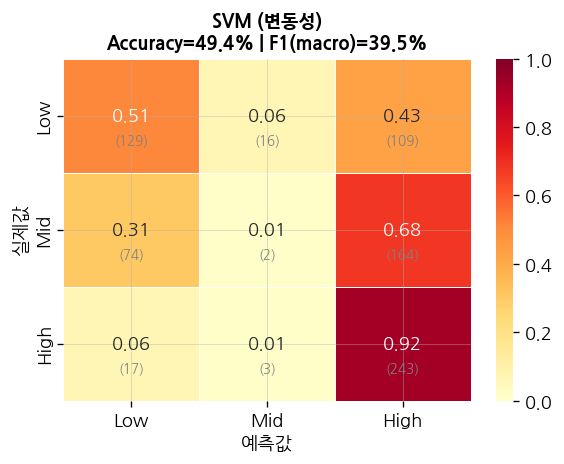

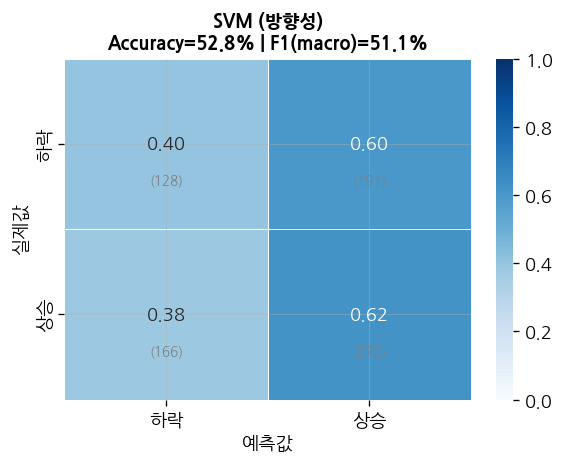

In [25]:
# ──────────────────────────────────────────────────────────────
# [셀 6] Model 4 — SVM (Support Vector Machine)
# ──────────────────────────────────────────────────────────────
#
# [이론] 클래스 간 마진(margin)을 최대화하는 결정 경계 탐색.
#        RBF 커널: K(x,x') = exp(-γ||x-x'||²)
#        → 원래 공간에서 선형 분리가 안 되는 데이터를 고차원에서 분리
#
# [선택 이유]
# - 고차원(38개 피처) 공간에서 효과적
# - RBF 커널로 비선형 패턴 포착 가능
# - 스케일링(이미 완료)이 필수 → 이미 StandardScaler 적용된 데이터 사용
#
# [금융 관점]
# 변동성 레짐 간 경계가 선형이 아닐 수 있음.
# RSI 70 이상 + 변동성 급등 조합 같은 비선형 패턴 포착 기대.
# ⚠️ 학습 시간이 가장 오래 걸리는 모델

print("\n" + "="*55)
print("  MODEL 4: SVM (RBF Kernel)")
print("="*55)
print("  RBF 커널로 비선형 경계 탐색. 학습 시간 가장 길 수 있음.\n")

# 스케일링 이미 완료된 데이터 사용 (EDA 노트북에서 처리)
svm_vol = SVC(kernel='rbf', C=1.0, gamma='scale',
              probability=True, random_state=42)
t0 = time.time()
svm_vol.fit(X_train, y_vol_train)
train_time = time.time() - t0
print(f"  학습 완료 (소요: {train_time:.1f}초)")
pred_svm_vol = svm_vol.predict(X_val)
res = evaluate_model('SVM (변동성)', y_vol_val, pred_svm_vol,
                     target_type='vol', figdir=FIG_DIR)
res['Train_Time'] = round(train_time, 3)
results_vol.append(res)

svm_dir = SVC(kernel='rbf', C=1.0, gamma='scale',
              probability=True, random_state=42)
svm_dir.fit(X_train, y_dir_train)
pred_svm_dir = svm_dir.predict(X_val)
res_dir = evaluate_model('SVM (방향성)', y_dir_val, pred_svm_dir,
                         target_type='dir', show_report=False, figdir=FIG_DIR)
results_dir.append(res_dir)


  MODEL 5: KNN (K=10)
  '과거에 지금과 비슷한 시장 상황이 있었나?'를 탐색

  K= 3: Val F1(macro) = 45.57%
  K= 5: Val F1(macro) = 45.62%
  K= 7: Val F1(macro) = 44.03%
  K=10: Val F1(macro) = 44.79%
  K=15: Val F1(macro) = 43.53%
  K=20: Val F1(macro) = 41.57%
  K=30: Val F1(macro) = 41.83%

   최적 K = 5 (Val F1 기준)


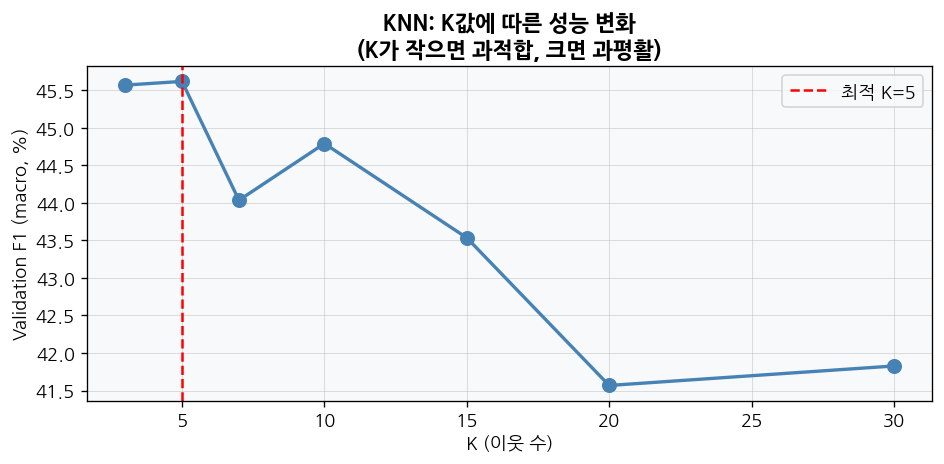


  [KNN K=5 (변동성)] 평가 결과
  Accuracy         : 49.67%
  Precision (macro): 45.74%
  Recall    (macro): 48.84%
  F1        (macro): 45.62%
  F1     (weighted): 46.26%

  클래스별 F1:
    Low(안정): 57.82%
    Mid(보통): 19.60%
    High(불안): 59.44%

   금융 해석:
     High(불안) 레짐 F1 = 59.44%
     → 불안 시장 사전 감지 능력 양호 (리스크 관리 활용 가능)

  Classification Report:
              precision    recall  f1-score   support

     Low(안정)       0.50      0.68      0.58       254
     Mid(보통)       0.32      0.14      0.20       240
    High(불안)       0.55      0.65      0.59       263

    accuracy                           0.50       757
   macro avg       0.46      0.49      0.46       757
weighted avg       0.46      0.50      0.46       757



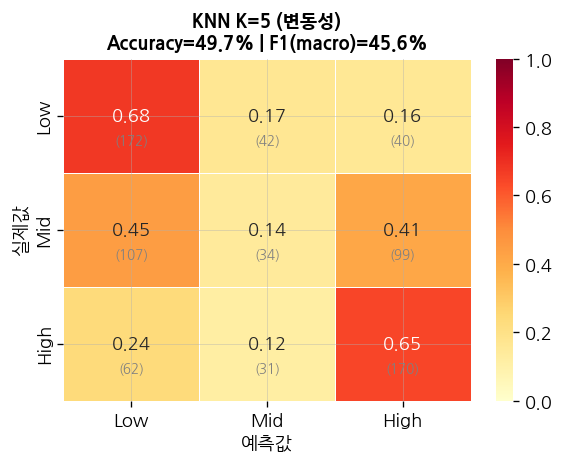

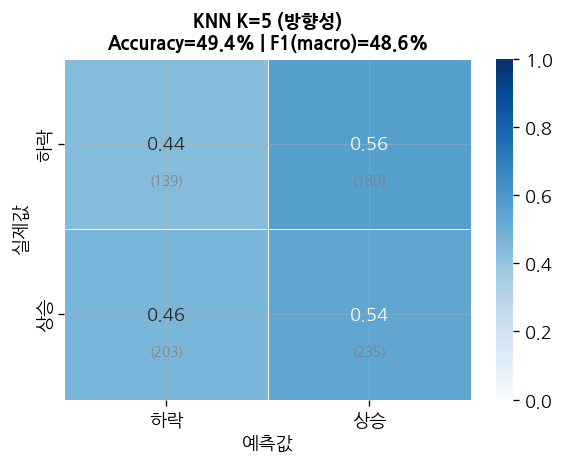

In [26]:
# ──────────────────────────────────────────────────────────────
# [셀 7] Model 5 — KNN (K-Nearest Neighbors)
# ──────────────────────────────────────────────────────────────
#
# [이론] 새로운 데이터와 가장 가까운 K개의 훈련 데이터를 찾아 다수결로 분류.
#        거리 = 유클리디안 거리 (스케일링 필수)
#
# [선택 이유]
# - "과거에 현재와 비슷한 시장 상황이 있었는가?" 직관적 가설 검증
# - 금융에서의 아날로그 접근(analogical reasoning)과 개념적으로 동일
# - 비모수적 방법 → 분포 가정 없음
#
# [금융 관점]
# K가 작으면 특정 위기 시점에 과적합, K가 크면 평균적 예측.
# 시장 Regime이 바뀌면 과거 이웃이 더 이상 유효하지 않을 수 있음 (한계).
# → K값에 따른 성능 변화를 분석하면 "시장 기억 기간" 유추 가능

print("\n" + "="*55)
print("  MODEL 5: KNN (K=10)")
print("="*55)
print("  '과거에 지금과 비슷한 시장 상황이 있었나?'를 탐색\n")

# K 선택: Validation에서 최적 K 탐색
k_range   = [3, 5, 7, 10, 15, 20, 30]
k_f1_scores = []

for k in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    knn_tmp.fit(X_train, y_vol_train)
    pred_tmp = knn_tmp.predict(X_val)
    f1_tmp = f1_score(y_vol_val, pred_tmp, average='macro', zero_division=0)
    k_f1_scores.append(f1_tmp)
    print(f"  K={k:2d}: Val F1(macro) = {f1_tmp*100:.2f}%")

best_k = k_range[np.argmax(k_f1_scores)]
print(f"\n   최적 K = {best_k} (Val F1 기준)")

# K별 성능 시각화
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, [f*100 for f in k_f1_scores],
        'o-', color='steelblue', linewidth=2, markersize=8)
ax.axvline(best_k, color='red', linestyle='--', linewidth=1.5,
           label=f'최적 K={best_k}')
ax.set_xlabel('K (이웃 수)')
ax.set_ylabel('Validation F1 (macro, %)')
ax.set_title('KNN: K값에 따른 성능 변화\n(K가 작으면 과적합, 크면 과평활)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/knn_k_selection.png', bbox_inches='tight')
plt.show()

# 최적 K로 최종 학습
knn_vol = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', n_jobs=-1)
t0 = time.time()
knn_vol.fit(X_train, y_vol_train)
train_time = time.time() - t0
pred_knn_vol = knn_vol.predict(X_val)
res = evaluate_model(f'KNN K={best_k} (변동성)', y_vol_val, pred_knn_vol,
                     target_type='vol', figdir=FIG_DIR)
res['Train_Time'] = round(train_time, 3)
results_vol.append(res)

knn_dir = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', n_jobs=-1)
knn_dir.fit(X_train, y_dir_train)
pred_knn_dir = knn_dir.predict(X_val)
res_dir = evaluate_model(f'KNN K={best_k} (방향성)', y_dir_val, pred_knn_dir,
                         target_type='dir', show_report=False, figdir=FIG_DIR)
results_dir.append(res_dir)


  MODEL 6: Decision Tree
  트리 깊이(max_depth)에 따른 과적합 vs 과소적합 분석

  depth=3   : Train F1=63.8% | Val F1=40.2%
  depth=4   : Train F1=64.6% | Val F1=37.5%
  depth=5   : Train F1=67.7% | Val F1=38.2%
  depth=6   : Train F1=70.1% | Val F1=36.7%
  depth=8   : Train F1=73.3% | Val F1=36.8%
  depth=10  : Train F1=76.4% | Val F1=38.1%
  depth=None: Train F1=78.3% | Val F1=37.7%


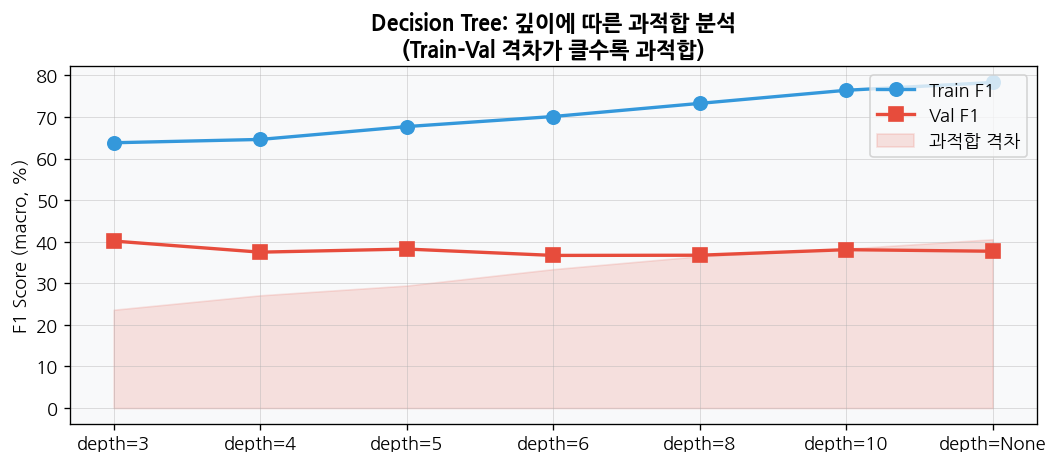


   최적 max_depth = 3

  [Decision Tree (변동성)] 평가 결과
  Accuracy         : 41.35%
  Precision (macro): 40.68%
  Recall    (macro): 40.97%
  F1        (macro): 40.17%
  F1     (weighted): 40.53%

  클래스별 F1:
    Low(안정): 47.43%
    Mid(보통): 25.53%
    High(불안): 47.54%

   금융 해석:
     High(불안) 레짐 F1 = 47.54%
     → 불안 시장 감지 능력 보통 (일부 위기 포착 가능)

  Classification Report:
              precision    recall  f1-score   support

     Low(안정)       0.41      0.56      0.47       254
     Mid(보통)       0.30      0.23      0.26       240
    High(불안)       0.52      0.44      0.48       263

    accuracy                           0.41       757
   macro avg       0.41      0.41      0.40       757
weighted avg       0.41      0.41      0.41       757



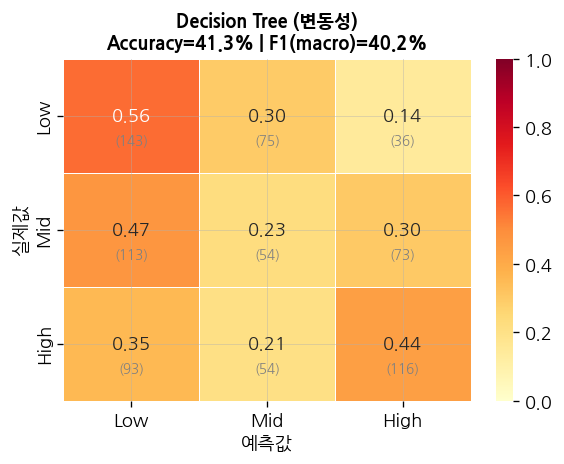

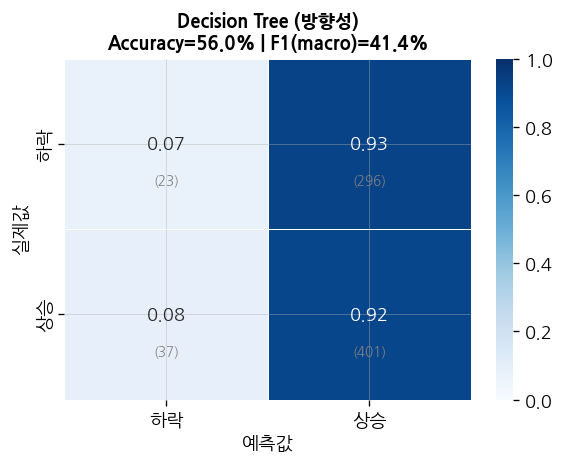


  [Decision Tree 상위 규칙 — 보고서 인용 가능]
|--- vol_60d <= -0.13
|   |--- atr_ratio <= -0.55
|   |   |--- macd_norm <= 0.92
|   |   |   |--- class: 0
|   |   |--- macd_norm >  0.92
|   |   |   |--- class: 1
|   |--- atr_ratio >  -0.55
|   |   |--- atr_14 <= 0.42
|   |   |   |--- class: 1
|   |   |--- atr_14 >  0.42
|   |   |   |--- class: 0
|--- vol_60d >  -0.13
|   |--- atr_ratio <= 0.51
|   |   |--- macd_hist <= -0.64
|   |   |   |--- class: 2
|   |   |--- macd_hist >  -0.64
|   |   |   |--- class: 1
|   |--- atr_ratio >  0.51
|   |   |--- pos_in_52w_range <= -0.68
|   |   |   |--- class: 2
|   |   |--- pos_in_52w_range >  -0.68
|   |   |   |--- class: 2



In [27]:
# ──────────────────────────────────────────────────────────────
# [셀 8] Model 6 — Decision Tree
# ──────────────────────────────────────────────────────────────
#
# [이론] 피처의 임계값 기준 재귀적 이진 분기.
#        각 노드에서 불순도(Gini / Entropy) 최소화 방향으로 분기.
#        완전히 성장하면 훈련 데이터에 과적합.
#
# [선택 이유]
# - 완전한 해석 가능성: "ATR > 0.012 → High 레짐 가능성 높음" 같은 룰 추출
# - Random Forest와 비교하여 단일 트리의 과적합 문제를 명시적으로 보여줌
# - 의사결정 규칙이 금융 트레이딩 룰(if-then)과 구조적으로 동일
#
# [금융 관점]
# 과적합된 깊은 트리 vs 가지치기된 얕은 트리 비교.
# 금융 데이터에서 max_depth 제한이 왜 중요한지 시각적으로 확인.

print("\n" + "="*55)
print("  MODEL 6: Decision Tree")
print("="*55)
print("  트리 깊이(max_depth)에 따른 과적합 vs 과소적합 분석\n")

# max_depth 탐색
depth_range = [3, 4, 5, 6, 8, 10, None]
depth_results = []

for d in depth_range:
    dt_tmp = DecisionTreeClassifier(max_depth=d, min_samples_leaf=30,
                                    random_state=42)
    dt_tmp.fit(X_train, y_vol_train)
    train_f1 = f1_score(y_vol_train, dt_tmp.predict(X_train), average='macro')
    val_f1   = f1_score(y_vol_val,   dt_tmp.predict(X_val),   average='macro')
    depth_results.append({'depth': str(d), 'train': train_f1, 'val': val_f1})
    print(f"  depth={str(d):4s}: Train F1={train_f1*100:.1f}% | Val F1={val_f1*100:.1f}%")

# 과적합 시각화
fig, ax = plt.subplots(figsize=(9, 4))
depths_str = [r['depth'] for r in depth_results]
train_f1s  = [r['train']*100 for r in depth_results]
val_f1s    = [r['val']*100   for r in depth_results]
x_pos = range(len(depths_str))
ax.plot(x_pos, train_f1s, 'o-', color='#3498db', linewidth=2,
        markersize=8, label='Train F1')
ax.plot(x_pos, val_f1s,   's-', color='#e74c3c', linewidth=2,
        markersize=8, label='Val F1')
ax.fill_between(x_pos,
                [t - v for t, v in zip(train_f1s, val_f1s)],
                0, alpha=0.15, color='#e74c3c', label='과적합 격차')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'depth={d}' for d in depths_str])
ax.set_ylabel('F1 Score (macro, %)')
ax.set_title('Decision Tree: 깊이에 따른 과적합 분석\n'
             '(Train-Val 격차가 클수록 과적합)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/dt_depth_analysis.png', bbox_inches='tight')
plt.show()

# 최적 depth 선택 (Val F1 기준)
best_depth_idx = np.argmax(val_f1s)
best_depth = depth_range[best_depth_idx]
print(f"\n   최적 max_depth = {best_depth}")

dt_vol = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=30,
                                 random_state=42)
t0 = time.time()
dt_vol.fit(X_train, y_vol_train)
train_time = time.time() - t0
pred_dt_vol = dt_vol.predict(X_val)
res = evaluate_model(f'Decision Tree (변동성)', y_vol_val, pred_dt_vol,
                     target_type='vol', figdir=FIG_DIR)
res['Train_Time'] = round(train_time, 3)
results_vol.append(res)

dt_dir = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=30,
                                  random_state=42)
dt_dir.fit(X_train, y_dir_train)
pred_dt_dir = dt_dir.predict(X_val)
res_dir = evaluate_model('Decision Tree (방향성)', y_dir_val, pred_dt_dir,
                         target_type='dir', show_report=False, figdir=FIG_DIR)
results_dir.append(res_dir)

# 트리 규칙 출력 (상위 3단계만)
print("\n  [Decision Tree 상위 규칙 — 보고서 인용 가능]")
tree_rules = export_text(dt_vol, feature_names=feature_cols, max_depth=3)
print(tree_rules)


  MODEL 7: Random Forest
  Decision Tree 200개 앙상블 → 노이즈에 강건

  학습 완료 (소요: 9.1초)
  OOB Score (훈련셋 내부 검증): 74.94%

  [Random Forest (변동성)] 평가 결과
  Accuracy         : 45.97%
  Precision (macro): 36.43%
  Recall    (macro): 44.92%
  F1        (macro): 38.53%
  F1     (weighted): 39.39%

  클래스별 F1:
    Low(안정): 53.59%
    Mid(보통): 4.20%
    High(불안): 57.79%

   금융 해석:
     High(불안) 레짐 F1 = 57.79%
     → 불안 시장 사전 감지 능력 양호 (리스크 관리 활용 가능)

  Classification Report:
              precision    recall  f1-score   support

     Low(안정)       0.46      0.65      0.54       254
     Mid(보통)       0.13      0.03      0.04       240
    High(불안)       0.50      0.68      0.58       263

    accuracy                           0.46       757
   macro avg       0.36      0.45      0.39       757
weighted avg       0.37      0.46      0.39       757



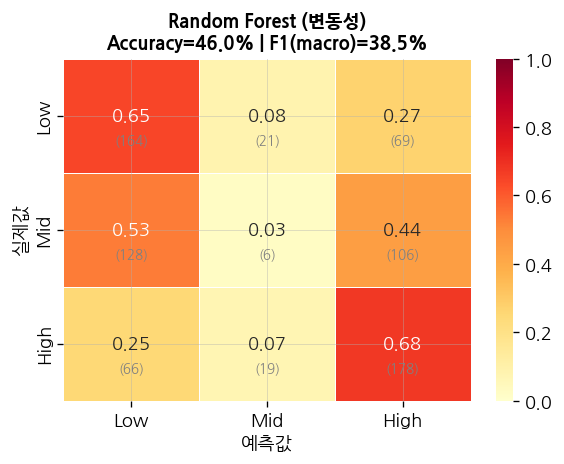

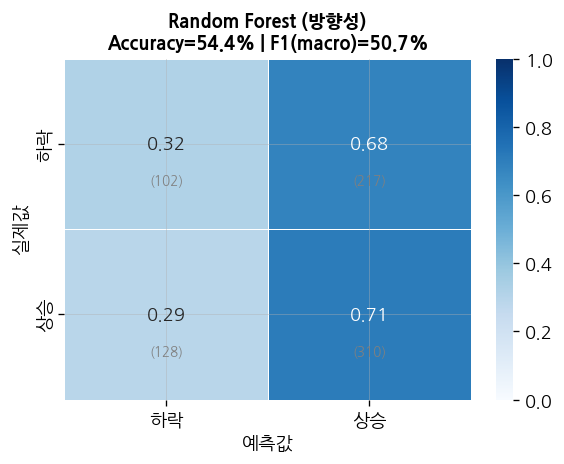

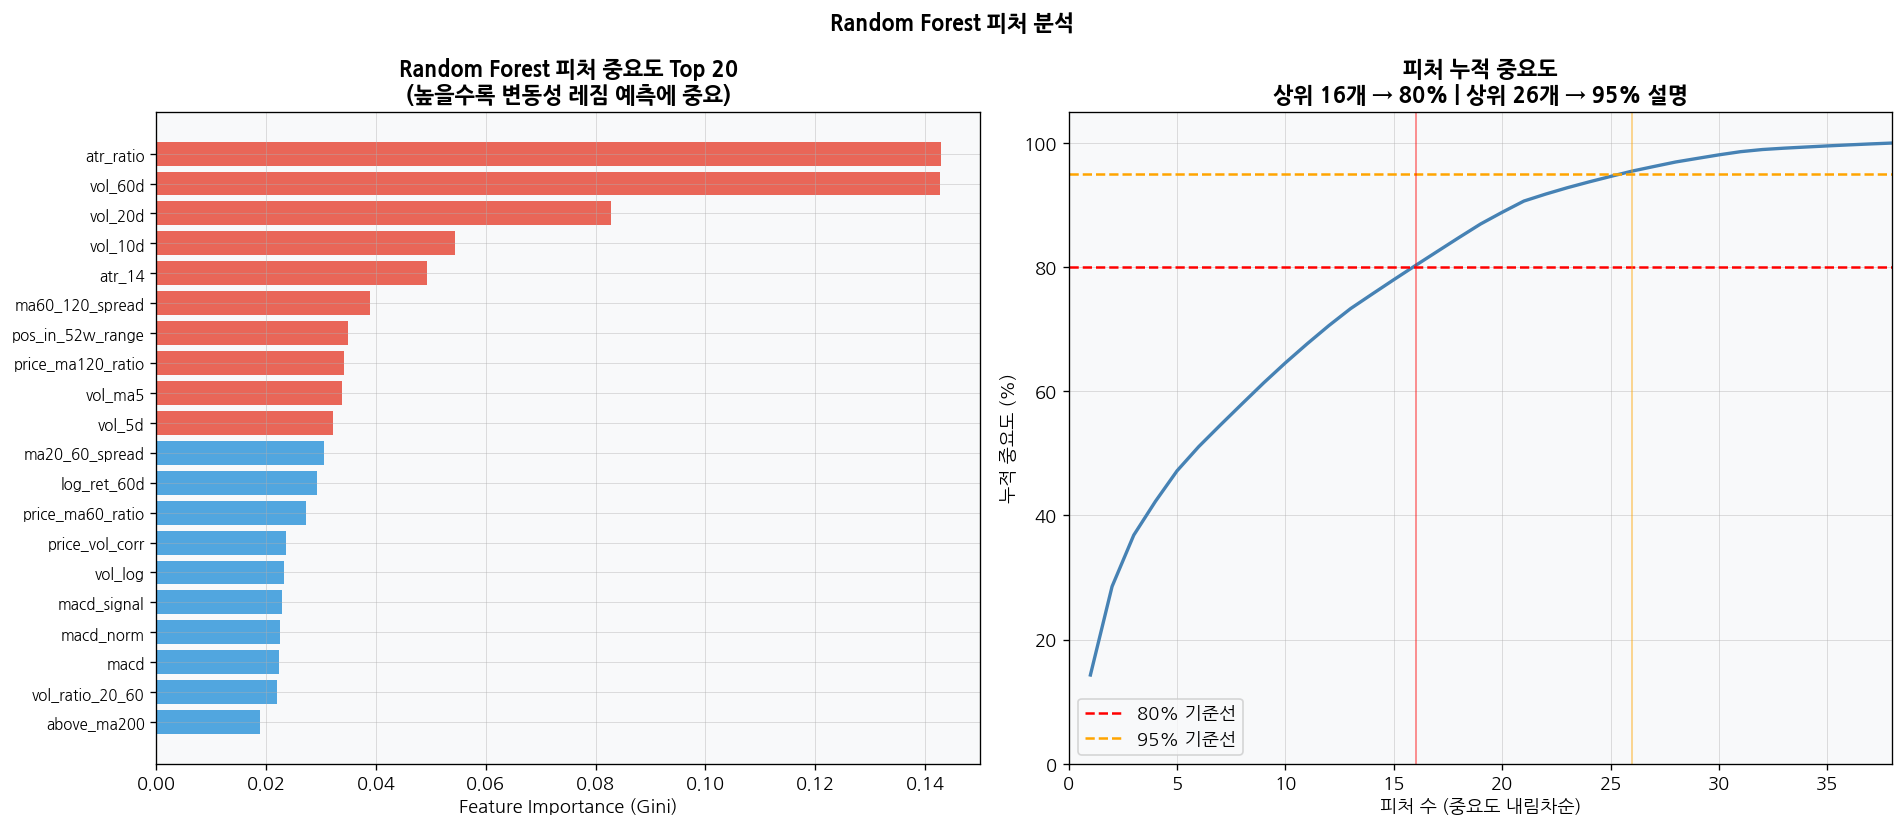


   상위 5개 중요 피처:
     atr_ratio                     : 14.29%
     vol_60d                       : 14.26%
     vol_20d                       : 8.27%
     vol_10d                       : 5.44%
     atr_14                        : 4.93%


In [28]:
# ──────────────────────────────────────────────────────────────
# [셀 9] Model 7 — Random Forest
# ──────────────────────────────────────────────────────────────
#
# [이론] 부트스트랩 샘플 + 랜덤 피처 서브셋으로 다수의 트리 학습.
#        각 트리의 예측을 다수결 → 분산(variance) 감소 효과.
#        OOB(Out-Of-Bag) 샘플로 추가적인 검증 가능.
#
# [선택 이유]
# - Decision Tree의 과적합 문제를 앙상블로 해결 → 둘을 비교
# - 피처 중요도(feature_importances_) 제공 → 가장 중요한 피처 파악
# - 금융 데이터의 노이즈에 강건 (Bagging 효과)
# - 실무 퀀트 팩터 분석에서 가장 많이 활용되는 모델 중 하나 [추정]
#
# [금융 관점]
# 트리 1개(DT)와 200개(RF)의 성능 차이가 앙상블의 힘을 직접 증명.
# RF의 피처 중요도 = "어떤 시장 지표가 변동성 레짐에 가장 영향을 미치는가"

print("\n" + "="*55)
print("  MODEL 7: Random Forest")
print("="*55)
print("  Decision Tree 200개 앙상블 → 노이즈에 강건\n")

rf_vol = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    max_features='sqrt',
    oob_score=True,
    n_jobs=-1,
    random_state=42
)
t0 = time.time()
rf_vol.fit(X_train, y_vol_train)
train_time = time.time() - t0
print(f"  학습 완료 (소요: {train_time:.1f}초)")
print(f"  OOB Score (훈련셋 내부 검증): {rf_vol.oob_score_*100:.2f}%")
pred_rf_vol = rf_vol.predict(X_val)
res = evaluate_model('Random Forest (변동성)', y_vol_val, pred_rf_vol,
                     target_type='vol', figdir=FIG_DIR)
res['Train_Time'] = round(train_time, 3)
results_vol.append(res)

rf_dir = RandomForestClassifier(n_estimators=200, max_depth=10,
                                 min_samples_leaf=20, max_features='sqrt',
                                 n_jobs=-1, random_state=42)
rf_dir.fit(X_train, y_dir_train)
pred_rf_dir = rf_dir.predict(X_val)
res_dir = evaluate_model('Random Forest (방향성)', y_dir_val, pred_rf_dir,
                         target_type='dir', show_report=False, figdir=FIG_DIR)
results_dir.append(res_dir)

# ── 피처 중요도 시각화 ─────────────────────────────────────
importances  = rf_vol.feature_importances_
sorted_idx   = np.argsort(importances)[-20:]  # 상위 20개
cumulative   = np.cumsum(importances[np.argsort(importances)[::-1]])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 좌: 피처 중요도 바 차트
ax = axes[0]
colors_imp = [REGIME_COLORS[2] if importances[i] > np.percentile(importances, 75)
              else '#3498db' for i in sorted_idx]
ax.barh(range(20), importances[sorted_idx], color=colors_imp, alpha=0.85)
ax.set_yticks(range(20))
ax.set_yticklabels([feature_cols[i] for i in sorted_idx], fontsize=9)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest 피처 중요도 Top 20\n(높을수록 변동성 레짐 예측에 중요)')

# 우: 누적 중요도
ax = axes[1]
ax.plot(range(1, len(importances)+1), cumulative * 100,
        color='steelblue', linewidth=2)
ax.axhline(80, color='red', linestyle='--', linewidth=1.5,
           label='80% 기준선')
ax.axhline(95, color='orange', linestyle='--', linewidth=1.5,
           label='95% 기준선')
n80 = int(np.searchsorted(cumulative, 0.80)) + 1
n95 = int(np.searchsorted(cumulative, 0.95)) + 1
ax.axvline(n80, color='red',    alpha=0.5, linewidth=1)
ax.axvline(n95, color='orange', alpha=0.5, linewidth=1)
ax.set_xlabel('피처 수 (중요도 내림차순)')
ax.set_ylabel('누적 중요도 (%)')
ax.set_title(f'피처 누적 중요도\n상위 {n80}개 → 80% | 상위 {n95}개 → 95% 설명')
ax.legend()
ax.set_xlim(0, len(importances))
ax.set_ylim(0, 105)

plt.suptitle('Random Forest 피처 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/rf_feature_importance.png', bbox_inches='tight')
plt.show()

print(f"\n   상위 5개 중요 피처:")
for i in np.argsort(importances)[::-1][:5]:
    print(f"     {feature_cols[i]:30s}: {importances[i]*100:.2f}%")


  MODEL 8: Neural Network (MLP)
  구조: 입력(38) → 64 → 32 → 출력(3)
  Early Stopping 적용 → 과적합 자동 방지

  학습 완료 (소요: 7.1초, 139회 반복)

  [MLP Neural Net (변동성)] 평가 결과
  Accuracy         : 45.84%
  Precision (macro): 49.31%
  Recall    (macro): 44.94%
  F1        (macro): 42.23%
  F1     (weighted): 42.69%

  클래스별 F1:
    Low(안정): 45.26%
    Mid(보통): 25.68%
    High(불안): 55.73%

   금융 해석:
     High(불안) 레짐 F1 = 55.73%
     → 불안 시장 사전 감지 능력 양호 (리스크 관리 활용 가능)

  Classification Report:
              precision    recall  f1-score   support

     Low(안정)       0.68      0.34      0.45       254
     Mid(보통)       0.37      0.20      0.26       240
    High(불안)       0.42      0.81      0.56       263

    accuracy                           0.46       757
   macro avg       0.49      0.45      0.42       757
weighted avg       0.49      0.46      0.43       757



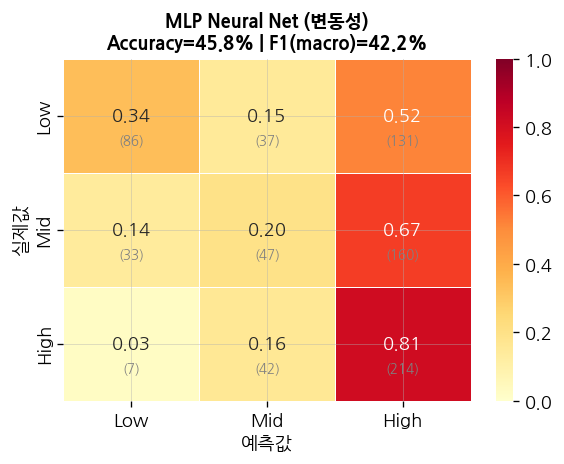

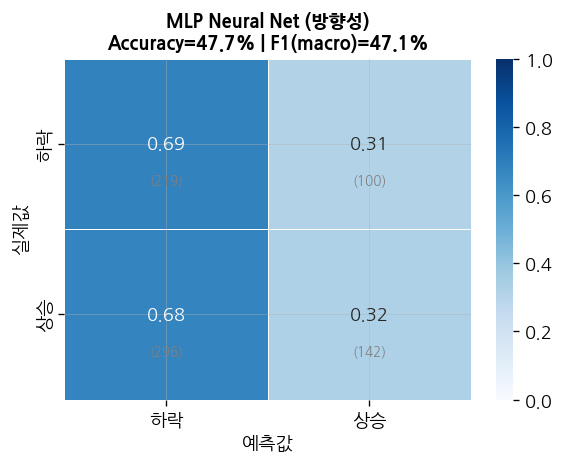

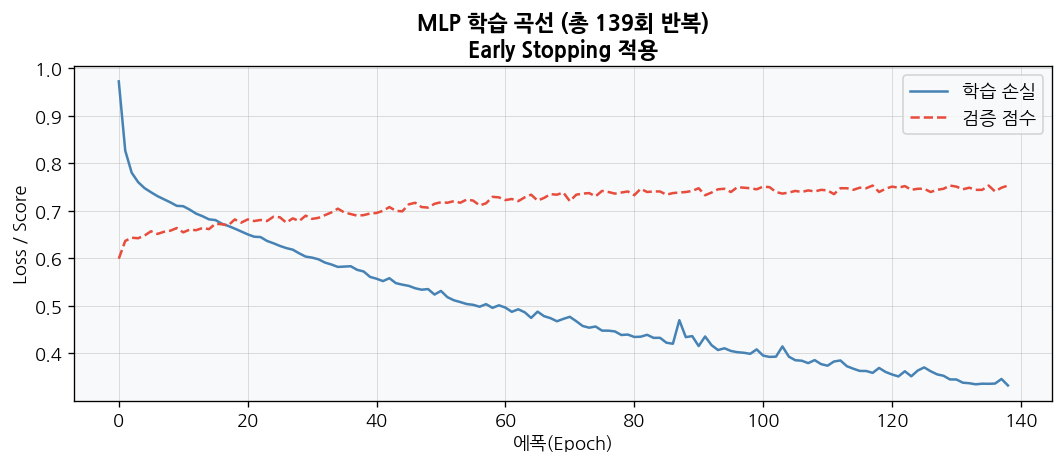

In [29]:
# ──────────────────────────────────────────────────────────────
# [셀 10] Model 8 — Neural Network (MLP)
# ──────────────────────────────────────────────────────────────
#
# [이론] 다층 퍼셉트론: 입력 → 은닉층(ReLU 활성화) → 출력층(Softmax)
#        역전파(Backpropagation)로 가중치 최적화.
#        Early Stopping으로 과적합 자동 방지.
#
# [선택 이유]
# - 가장 복잡한 비선형 모델 → 복잡도 스펙트럼의 끝점
# - 피처 간의 복잡한 상호작용 패턴 자동 학습 가능
# - "복잡할수록 반드시 좋은가?" 질문에 답하는 모델
#
# [금융 관점]
# 금융 데이터는 signal-to-noise ratio가 낮아 NN이 과적합하기 쉬움 [일반적 접근].
# Early Stopping + Validation 기반 조기 종료로 이를 방지.
# RF와 MLP의 성능 비교 = "앙상블 vs 딥러닝" 구도

print("\n" + "="*55)
print("  MODEL 8: Neural Network (MLP)")
print("="*55)
print("  구조: 입력(38) → 64 → 32 → 출력(3)")
print("  Early Stopping 적용 → 과적합 자동 방지\n")

mlp_vol = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,           # L2 정규화 (과적합 방지)
    batch_size=256,
    learning_rate='adaptive',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=False
)
t0 = time.time()
mlp_vol.fit(X_train, y_vol_train)
train_time = time.time() - t0
print(f"  학습 완료 (소요: {train_time:.1f}초, {mlp_vol.n_iter_}회 반복)")
pred_mlp_vol = mlp_vol.predict(X_val)
res = evaluate_model('MLP Neural Net (변동성)', y_vol_val, pred_mlp_vol,
                     target_type='vol', figdir=FIG_DIR)
res['Train_Time'] = round(train_time, 3)
results_vol.append(res)

mlp_dir = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                         solver='adam', alpha=0.001, batch_size=256,
                         max_iter=500, early_stopping=True,
                         validation_fraction=0.1, n_iter_no_change=20,
                         random_state=42, verbose=False)
mlp_dir.fit(X_train, y_dir_train)
pred_mlp_dir = mlp_dir.predict(X_val)
res_dir = evaluate_model('MLP Neural Net (방향성)', y_dir_val, pred_mlp_dir,
                         target_type='dir', show_report=False, figdir=FIG_DIR)
results_dir.append(res_dir)

# 학습 곡선 시각화
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mlp_vol.loss_curve_, color='steelblue', linewidth=1.5, label='학습 손실')
if hasattr(mlp_vol, 'validation_scores_') and mlp_vol.validation_scores_ is not None:
    ax.plot(mlp_vol.validation_scores_, color='#e74c3c', linewidth=1.5,
            label='검증 점수', linestyle='--')
ax.set_xlabel('에폭(Epoch)')
ax.set_ylabel('Loss / Score')
ax.set_title(f'MLP 학습 곡선 (총 {mlp_vol.n_iter_}회 반복)\nEarly Stopping 적용')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/mlp_learning_curve.png', bbox_inches='tight')
plt.show()


  전체 모델 성능 비교 (Validation Set 기준)

  [변동성 레짐 분류 — 메인 타겟]
               Model  Accuracy  Precision  Recall  F1_macro  F1_weighted  Train_Time
       KNN K=5 (변동성)     49.67      45.74   48.84     45.62        46.26       0.005
MLP Neural Net (변동성)     45.84      49.31   44.94     42.23        42.69       7.125
 Decision Tree (변동성)     41.35      40.68   40.97     40.17        40.53       0.193
           SVM (변동성)     49.41      38.42   48.01     39.45        40.42      26.738
   Logistic L1 (변동성)     48.08      47.86   46.83     39.03        39.91       5.294
 Random Forest (변동성)     45.97      36.43   44.92     38.53        39.39       9.118
   Naive Bayes (변동성)     46.24      39.58   45.03     38.49        39.33       0.011
   Logistic L2 (변동성)     46.76      48.66   45.45     36.86        37.77       0.595
       Baseline(최빈값)     33.55      11.18   33.33     16.75        16.86         NaN

  [방향성 예측 — 서브 비교용]
               Model  Accuracy  Precision  Recall  F1_macro  F1_weighte

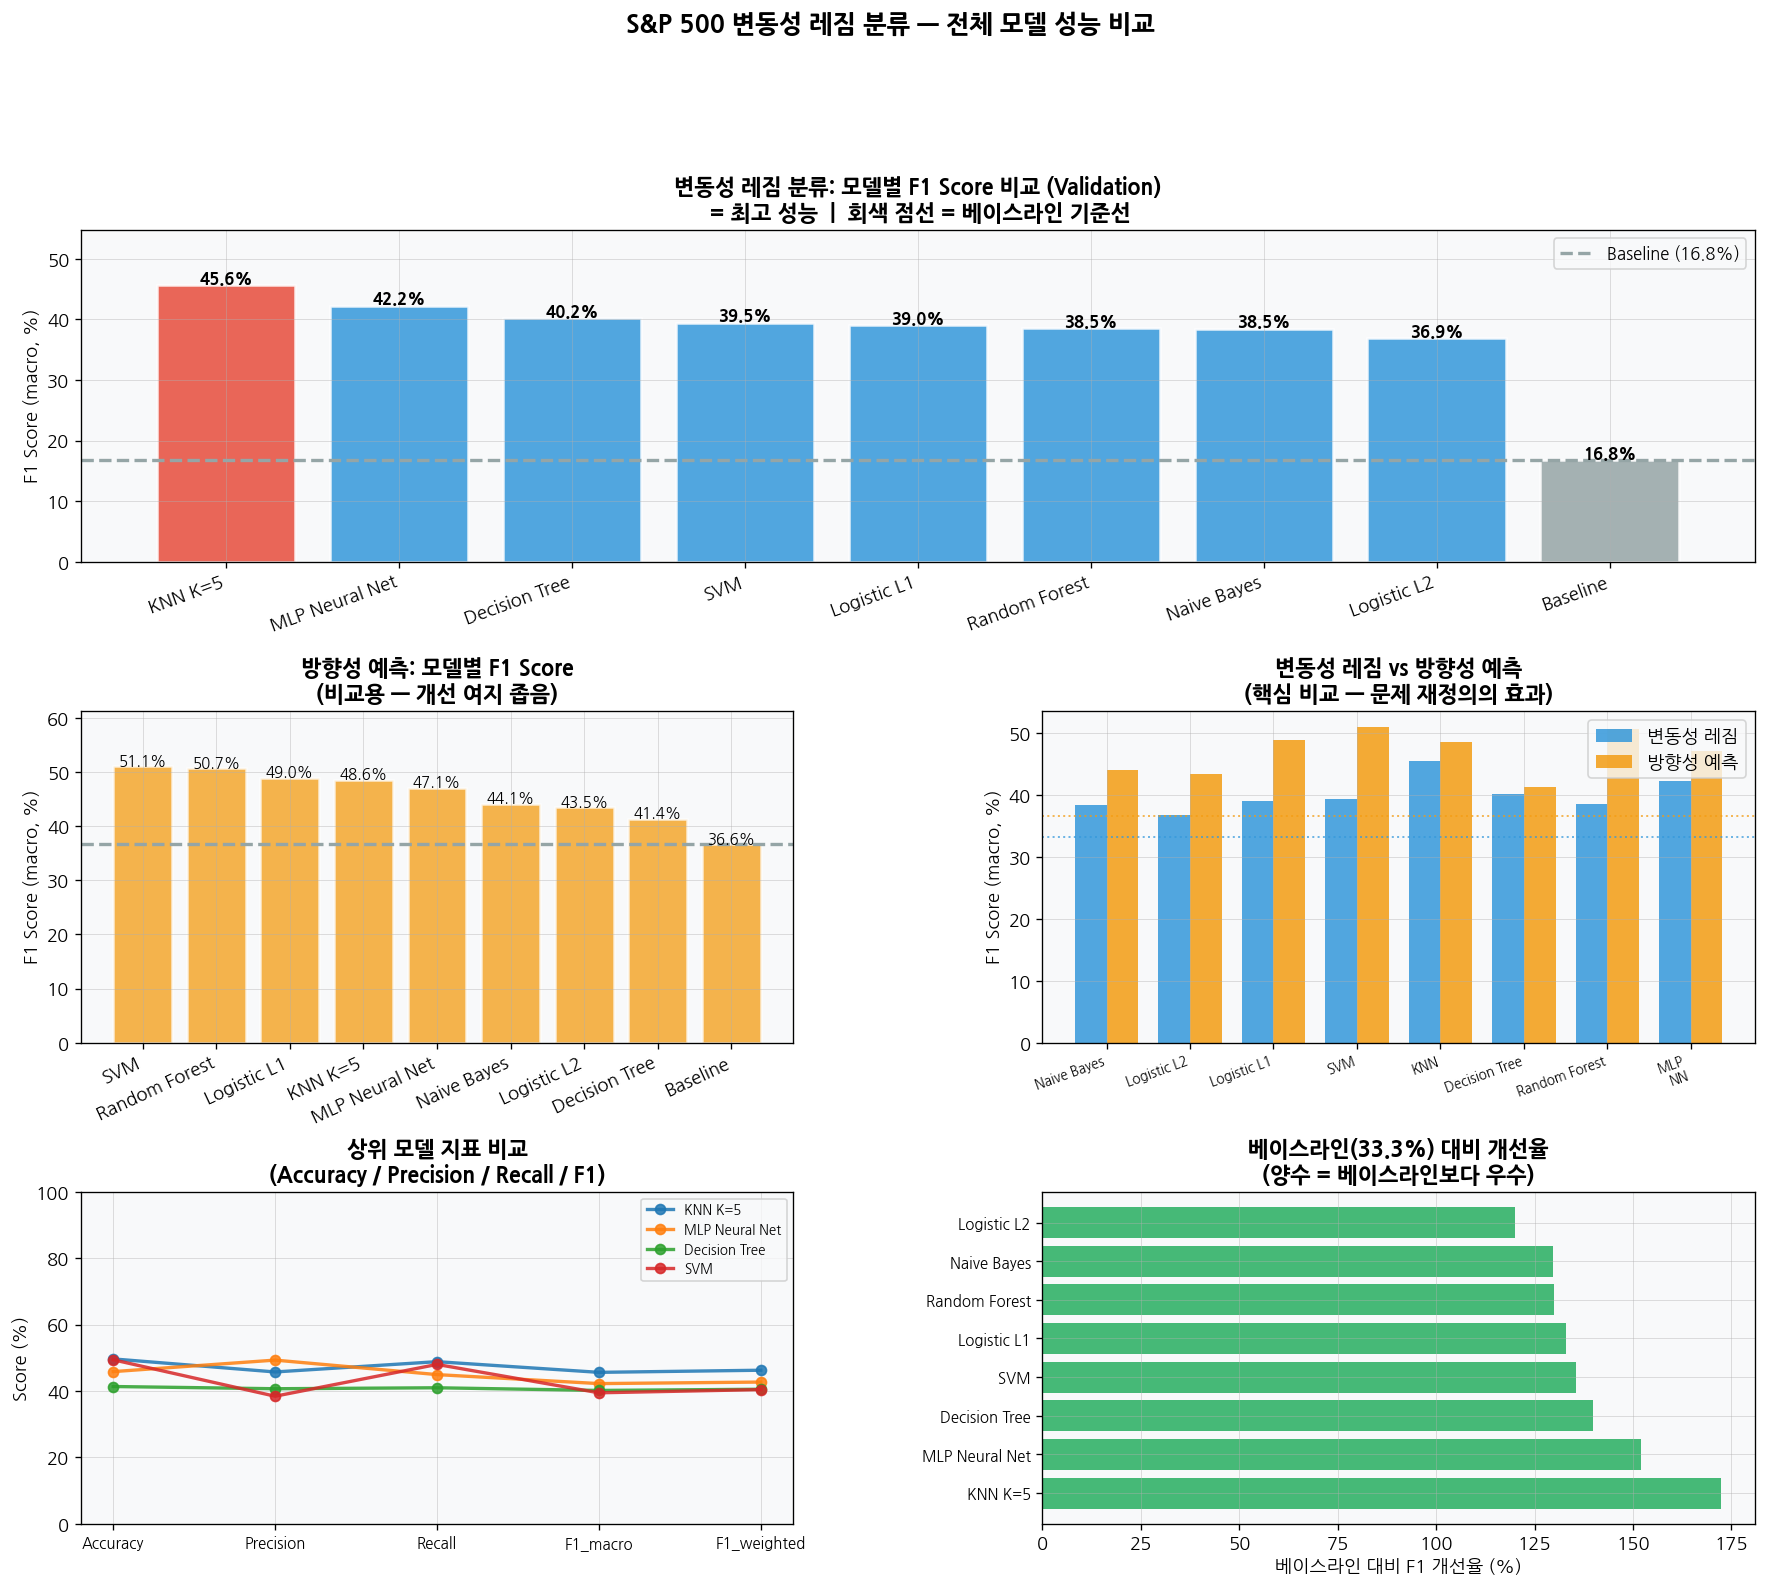

In [30]:
# ──────────────────────────────────────────────────────────────
# [셀 11] 전체 모델 성능 비교 테이블 및 시각화
# ──────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("  전체 모델 성능 비교 (Validation Set 기준)")
print("="*60)

# ── 변동성 레짐 결과 테이블 ───────────────────────────────
df_results_vol = pd.DataFrame(results_vol)
df_results_vol = df_results_vol.sort_values('F1_macro', ascending=False)

print("\n  [변동성 레짐 분류 — 메인 타겟]")
print(df_results_vol.to_string(index=False))

# ── 방향성 결과 테이블 ────────────────────────────────────
df_results_dir = pd.DataFrame(results_dir)
df_results_dir = df_results_dir.sort_values('F1_macro', ascending=False)

print("\n  [방향성 예측 — 서브 비교용]")
print(df_results_dir.to_string(index=False))

# ── 통합 비교 시각화 ──────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# (1) 변동성 레짐 F1 비교 (메인)
ax1 = fig.add_subplot(gs[0, :])
models_vol = df_results_vol['Model'].str.replace(' (변동성)', '', regex=False)
models_vol = models_vol.str.replace('Baseline(최빈값)', 'Baseline', regex=False)
f1_vol     = df_results_vol['F1_macro'].values
baseline_f1 = df_results_vol[df_results_vol['Model'].str.contains('Baseline')
                              ]['F1_macro'].values[0]
colors_bar = ['#95a5a6' if '(최빈값)' in m else
              '#e74c3c' if f == f1_vol.max() else '#3498db'
              for m, f in zip(df_results_vol['Model'], f1_vol)]
bars = ax1.bar(models_vol, f1_vol, color=colors_bar, alpha=0.85,
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, f1_vol):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax1.axhline(baseline_f1, color='#95a5a6', linestyle='--',
            linewidth=2, label=f'Baseline ({baseline_f1:.1f}%)')
ax1.set_ylabel('F1 Score (macro, %)')
ax1.set_title('변동성 레짐 분류: 모델별 F1 Score 비교 (Validation)\n'
              ' = 최고 성능  |  회색 점선 = 베이스라인 기준선',
              fontsize=13)
ax1.legend(fontsize=10)
ax1.set_ylim(0, max(f1_vol) * 1.2)
plt.setp(ax1.get_xticklabels(), rotation=20, ha='right')

# (2) 방향성 예측 F1 비교 (서브)
ax2 = fig.add_subplot(gs[1, 0])
models_dir = df_results_dir['Model'].str.replace(' (방향성)', '', regex=False)
models_dir = models_dir.str.replace('Baseline(방향성)', 'Baseline', regex=False)
f1_dir     = df_results_dir['F1_macro'].values
base_dir   = df_results_dir[df_results_dir['Model'].str.contains('Baseline')
                             ]['F1_macro'].values[0]
colors_dir = ['#95a5a6' if '(방향성)' in m and '방향성' in df_results_dir[
               df_results_dir['F1_macro'] == f].iloc[0]['Model'] else '#f39c12'
               for m, f in zip(df_results_dir['Model'], f1_dir)]
ax2.bar(models_dir, f1_dir, color='#f39c12', alpha=0.75,
        edgecolor='white', linewidth=1.5)
ax2.axhline(base_dir, color='#95a5a6', linestyle='--', linewidth=2)
ax2.set_ylabel('F1 Score (macro, %)')
ax2.set_title('방향성 예측: 모델별 F1 Score\n(비교용 — 개선 여지 좁음)')
ax2.set_ylim(0, max(f1_dir) * 1.2)
plt.setp(ax2.get_xticklabels(), rotation=25, ha='right')
for bar, val in zip(ax2.patches, f1_dir):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontsize=9)

# (3) 변동성 vs 방향성 핵심 비교
ax3 = fig.add_subplot(gs[1, 1])
# 공통 모델만 추출
common_models = ['Naive Bayes', 'Logistic L2', 'Logistic L1',
                 'SVM', f'KNN K={best_k}', 'Decision Tree',
                 'Random Forest', 'MLP Neural Net']
vol_f1_map = {r['Model'].replace(' (변동성)', ''): r['F1_macro']
              for r in results_vol}
dir_f1_map = {r['Model'].replace(' (방향성)', ''): r['F1_macro']
              for r in results_dir}
shared_models = [m for m in common_models
                 if m in vol_f1_map and m in dir_f1_map]
vol_vals = [vol_f1_map[m] for m in shared_models]
dir_vals = [dir_f1_map[m] for m in shared_models]
x_pos2   = np.arange(len(shared_models))
width    = 0.38
ax3.bar(x_pos2 - width/2, vol_vals, width, label='변동성 레짐', color='#3498db', alpha=0.85)
ax3.bar(x_pos2 + width/2, dir_vals, width, label='방향성 예측', color='#f39c12', alpha=0.85)
ax3.axhline(33.3, color='#3498db', linestyle=':', linewidth=1.2, alpha=0.7)
ax3.axhline(base_dir, color='#f39c12', linestyle=':', linewidth=1.2, alpha=0.7)
ax3.set_xticks(x_pos2)
ax3.set_xticklabels([m.replace(' K='+str(best_k), '').replace(
    ' Neural Net', '\nNN') for m in shared_models], fontsize=8, rotation=20, ha='right')
ax3.set_ylabel('F1 Score (macro, %)')
ax3.set_title('변동성 레짐 vs 방향성 예측\n(핵심 비교 — 문제 재정의의 효과)')
ax3.legend()

# (4) 정밀도-재현율 레이더 차트 (변동성 최고 모델)
ax4 = fig.add_subplot(gs[2, 0])
best_model_name = df_results_vol.iloc[0]['Model']
metrics_names   = ['Accuracy', 'Precision', 'Recall', 'F1_macro', 'F1_weighted']
top3_models     = df_results_vol.head(4)  # 베이스라인 포함 top4

x_m = np.arange(len(metrics_names))
for i, (_, row) in enumerate(top3_models.iterrows()):
    label = row['Model'].replace(' (변동성)', '')
    vals  = [row[m] for m in metrics_names]
    ax4.plot(x_m, vals, 'o-', linewidth=2, markersize=6, label=label, alpha=0.85)
ax4.set_xticks(x_m)
ax4.set_xticklabels(metrics_names, fontsize=9)
ax4.set_ylabel('Score (%)')
ax4.set_title('상위 모델 지표 비교\n(Accuracy / Precision / Recall / F1)')
ax4.legend(fontsize=8)
ax4.set_ylim(0, 100)

# (5) 베이스라인 대비 개선율
ax5 = fig.add_subplot(gs[2, 1])
improvement_vol = [(r['F1_macro'] - baseline_f1) / baseline_f1 * 100
                   for r in results_vol if 'Baseline' not in r['Model']]
model_names_imp = [r['Model'].replace(' (변동성)', '')
                   for r in results_vol if 'Baseline' not in r['Model']]
sorted_pairs    = sorted(zip(improvement_vol, model_names_imp), reverse=True)
imp_vals, imp_names = zip(*sorted_pairs)
colors_imp = ['#27ae60' if v > 0 else '#e74c3c' for v in imp_vals]
ax5.barh(range(len(imp_vals)), imp_vals, color=colors_imp, alpha=0.85)
ax5.set_yticks(range(len(imp_vals)))
ax5.set_yticklabels(imp_names, fontsize=9)
ax5.axvline(0, color='black', linewidth=1)
ax5.set_xlabel('베이스라인 대비 F1 개선율 (%)')
ax5.set_title('베이스라인(33.3%) 대비 개선율\n(양수 = 베이스라인보다 우수)')

plt.suptitle('S&P 500 변동성 레짐 분류 — 전체 모델 성능 비교',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig(f'{FIG_DIR}/model_comparison_full.png',
            bbox_inches='tight', dpi=150)
plt.show()

In [31]:
# ──────────────────────────────────────────────────────────────
# [셀 12] 최종 테스트 세트 평가
# (Train + Val 합쳐서 재학습 → Test 평가)
# ⚠️ 이 셀은 모든 모델 선택이 확정된 후 단 1번만 실행
# ──────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("  최종 테스트 세트 평가")
print("  (Train+Val 재학습 → Test 예측)")
print("    이 결과가 논문/보고서에 기재되는 최종 성능")
print("="*60)

# 모든 모델 재학습 (Train+Val 전체 사용)
final_models = {
    'Baseline'      : DummyClassifier(strategy='most_frequent', random_state=42),
    'Naive Bayes'   : GaussianNB(),
    'Logistic L2'   : LogisticRegression(penalty='l2', solver='lbfgs',
                                          C=0.1, max_iter=2000,
                                          random_state=42),
    'Logistic L1'   : LogisticRegression(penalty='l1', solver='saga',
                                          C=0.1, max_iter=2000,
                                          random_state=42),
    'SVM'           : SVC(kernel='rbf', C=1.0, gamma='scale',
                          probability=True, random_state=42),
    f'KNN(K={best_k})': KNeighborsClassifier(n_neighbors=best_k,
                                              metric='euclidean', n_jobs=-1),
    'Decision Tree' : DecisionTreeClassifier(max_depth=best_depth,
                                              min_samples_leaf=30,
                                              random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=200, max_depth=10,
                                              min_samples_leaf=20,
                                              max_features='sqrt',
                                              n_jobs=-1, random_state=42),
    'MLP'           : MLPClassifier(hidden_layer_sizes=(64, 32),
                                    activation='relu', solver='adam',
                                    alpha=0.001, batch_size=256,
                                    max_iter=500, early_stopping=True,
                                    validation_fraction=0.1,
                                    n_iter_no_change=20,
                                    random_state=42, verbose=False),
}

final_results_vol = []
final_results_dir = []
final_preds_vol   = {}
final_preds_dir   = {}

print(f"\n  학습 데이터: {len(X_trainval):,}행 (Train+Val)")
print(f"  테스트 데이터: {len(X_test):,}행\n")

for name, model in final_models.items():
    # 변동성 레짐
    model.fit(X_trainval, y_vol_trainval)
    pred_test = model.predict(X_test)
    final_preds_vol[name] = pred_test

    acc  = accuracy_score(y_vol_test, pred_test)
    f1m  = f1_score(y_vol_test, pred_test, average='macro', zero_division=0)
    prec = precision_score(y_vol_test, pred_test, average='macro', zero_division=0)
    rec  = recall_score(y_vol_test, pred_test, average='macro', zero_division=0)
    f1_per = f1_score(y_vol_test, pred_test, average=None, zero_division=0)
    final_results_vol.append({
        'Model'        : name,
        'Accuracy'     : round(acc*100, 2),
        'Precision'    : round(prec*100, 2),
        'Recall'       : round(rec*100, 2),
        'F1_macro'     : round(f1m*100, 2),
        'F1_Low'       : round(f1_per[0]*100 if len(f1_per) > 0 else 0, 2),
        'F1_Mid'       : round(f1_per[1]*100 if len(f1_per) > 1 else 0, 2),
        'F1_High'      : round(f1_per[2]*100 if len(f1_per) > 2 else 0, 2),
    })

    # 방향성
    dir_model = final_models[name].__class__(**final_models[name].get_params())
    dir_model.fit(X_trainval, y_dir_trainval)
    pred_dir_test = dir_model.predict(X_test)
    final_preds_dir[name] = pred_dir_test
    acc_dir = accuracy_score(y_dir_test, pred_dir_test)
    f1_dir  = f1_score(y_dir_test, pred_dir_test, average='macro', zero_division=0)
    final_results_dir.append({
        'Model'    : name,
        'Accuracy' : round(acc_dir*100, 2),
        'F1_macro' : round(f1_dir*100, 2),
    })
    print(f"  {name:20s} | Vol F1: {f1m*100:.1f}% | Dir Acc: {acc_dir*100:.1f}%")

# 최종 테스트 결과 테이블
df_final_vol = pd.DataFrame(final_results_vol).sort_values('F1_macro', ascending=False)
df_final_dir = pd.DataFrame(final_results_dir).sort_values('Accuracy', ascending=False)

print("\n" + "="*70)
print("  최종 테스트 결과 — 변동성 레짐 분류")
print("="*70)
print(df_final_vol.to_string(index=False))

print("\n" + "="*50)
print("  최종 테스트 결과 — 방향성 예측")
print("="*50)
print(df_final_dir.to_string(index=False))


  최종 테스트 세트 평가
  (Train+Val 재학습 → Test 예측)
    이 결과가 논문/보고서에 기재되는 최종 성능

  학습 데이터: 9,581행 (Train+Val)
  테스트 데이터: 1,009행

  Baseline             | Vol F1: 12.8% | Dir Acc: 52.9%
  Naive Bayes          | Vol F1: 36.6% | Dir Acc: 53.7%
  Logistic L2          | Vol F1: 42.8% | Dir Acc: 52.3%
  Logistic L1          | Vol F1: 44.4% | Dir Acc: 52.2%
  SVM                  | Vol F1: 38.2% | Dir Acc: 51.8%
  KNN(K=5)             | Vol F1: 41.5% | Dir Acc: 49.9%
  Decision Tree        | Vol F1: 50.6% | Dir Acc: 53.0%
  Random Forest        | Vol F1: 56.2% | Dir Acc: 52.9%
  MLP                  | Vol F1: 30.3% | Dir Acc: 52.5%

  최종 테스트 결과 — 변동성 레짐 분류
        Model  Accuracy  Precision  Recall  F1_macro  F1_Low  F1_Mid  F1_High
Random Forest     59.27      56.75   57.52     56.22   41.32   46.78    80.58
Decision Tree     53.52      52.42   54.94     50.55   46.80   26.69    78.16
  Logistic L1     47.08      46.05   45.77     44.40   30.72   34.86    67.63
  Logistic L2     45.19      44.10   

In [32]:
# Low, Mid, High 나온 비율 확인

unique, counts = np.unique(y_vol_test, return_counts=True)
dist = dict(zip(unique, counts))

print("Test 데이터 클래스 분포:")
for k, v in dist.items():
    print(f"{k}: {v} ({v/len(y_vol_test)*100:.2f}%)")

unique, counts = np.unique(y_vol_trainval, return_counts=True)
print(dict(zip(unique, counts)))
unique, counts = np.unique(y_vol_test, return_counts=True)
print(dict(zip(unique, counts)))

Test 데이터 클래스 분포:
0: 240 (23.79%)
1: 379 (37.56%)
2: 390 (38.65%)
{np.int64(0): np.int64(3306), np.int64(1): np.int64(3094), np.int64(2): np.int64(3181)}
{np.int64(0): np.int64(240), np.int64(1): np.int64(379), np.int64(2): np.int64(390)}



  투자 전략 시뮬레이션 (Test Set: 2022~2026)
  전략: Low→풀투자 | Mid→절반투자 | High→현금
  Buy&Hold: 연수익 8.8% | Sharpe 0.50 | MDD -25.4%

  Baseline             | 연수익 +8.8% | Sharpe 0.50 | MDD -25.4%
  Logistic L2          | 연수익 +1.6% | Sharpe 0.18 | MDD -13.7%
  Logistic L1          | 연수익 +0.3% | Sharpe 0.03 | MDD -12.8%
  Random Forest        | 연수익 -0.6% | Sharpe -0.09 | MDD -13.5%
  MLP                  | 연수익 +0.8% | Sharpe 0.06 | MDD -28.8%


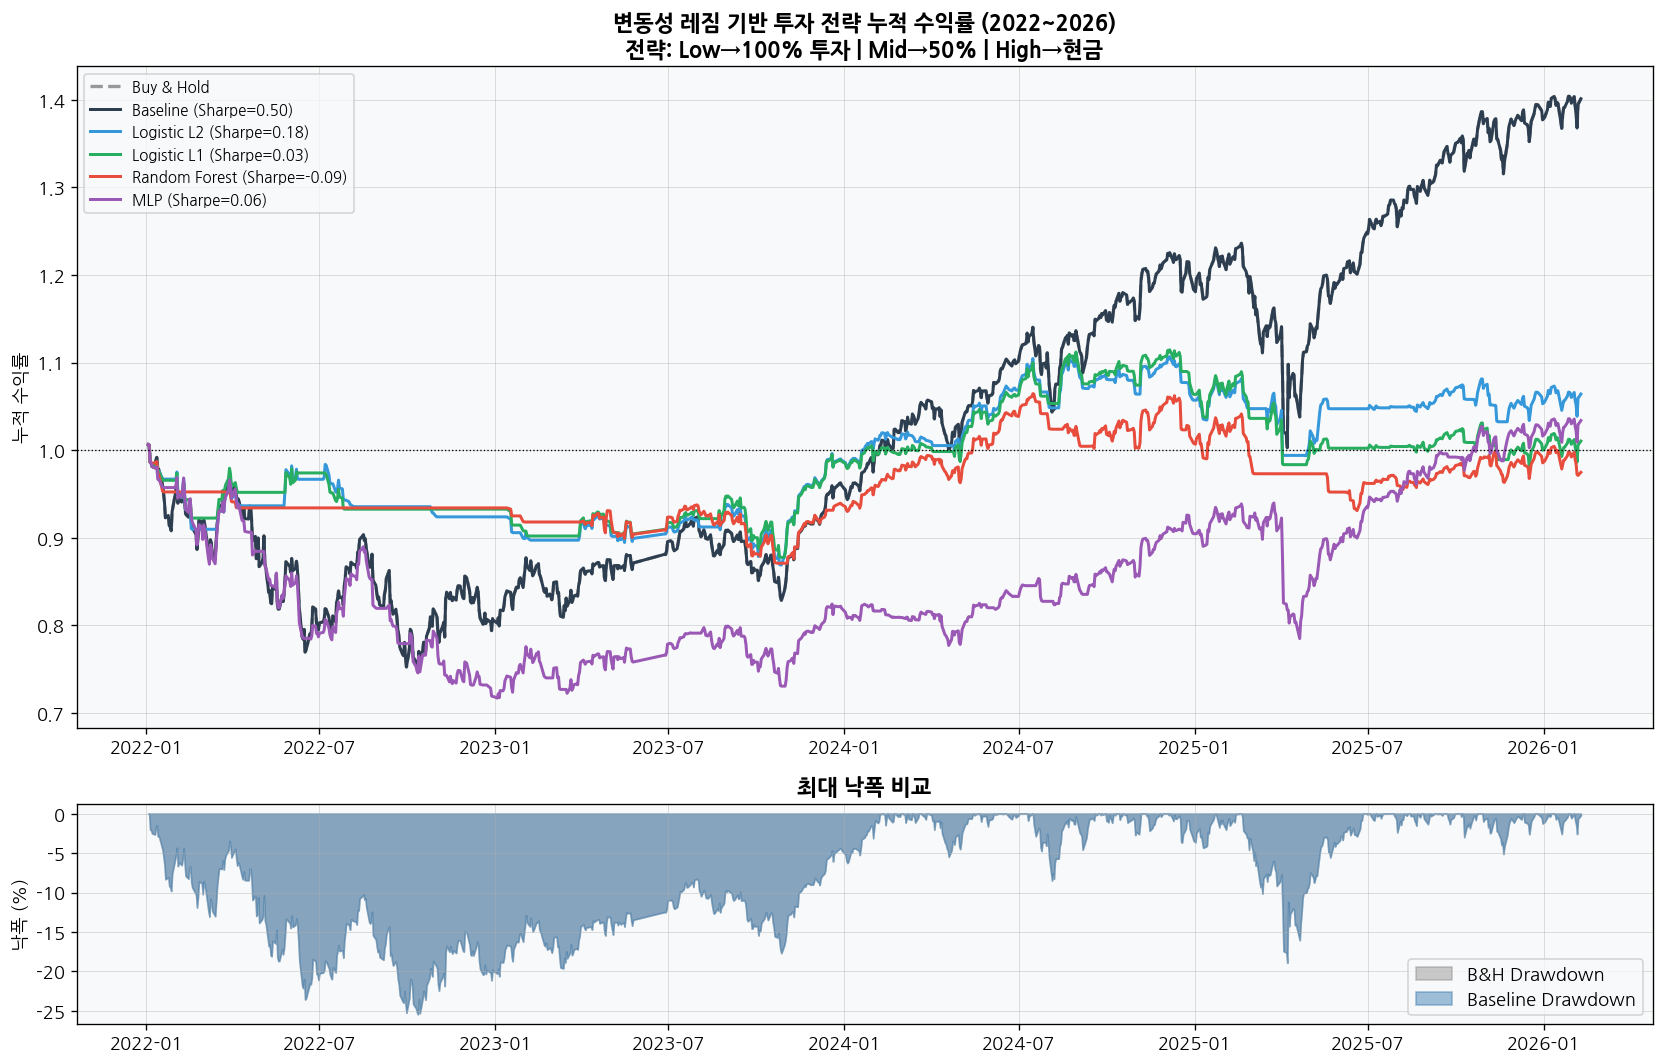


  시뮬레이션 한계 (보고서 필수 기재):
     슬리피지, 세금, 시장충격 비용 미반영
     단순 포지션 전략 — 실제 투자 조언 아님


In [33]:
# ──────────────────────────────────────────────────────────────
# [셀 13] 투자 전략 시뮬레이션
# ──────────────────────────────────────────────────────────────
#
# 전략 규칙:
#   - Low(안정) 예측  → 풀 투자 (100% S&P 500 보유)
#   - Mid(보통) 예측  → 절반 투자 (50% S&P 500, 50% 현금)
#   - High(불안) 예측 → 현금 보유 (0% — 리스크 회피)
#
# 비교 대상:
#   - Buy & Hold (항상 보유)
#   - 각 모델의 레짐 기반 전략

def trading_simulation_regime(model_name, y_pred_regimes,
                               log_returns, transaction_cost=0.001):
    """
    변동성 레짐 기반 투자 전략 시뮬레이션

    Parameters
    ----------
    y_pred_regimes : 예측된 레짐 (0=Low, 1=Mid, 2=High)
    log_returns    : 해당 기간 실제 일별 로그수익률
    transaction_cost : 거래비용 (매매 시 양방향 합계)
    """
    # 레짐별 투자 비중
    exposure_map = {0: 1.0, 1: 0.5, 2: 0.0}
    exposures    = np.array([exposure_map[r] for r in y_pred_regimes])
    log_ret_arr  = log_returns.values

    # 전략 수익률
    strategy_ret = exposures * log_ret_arr

    # 거래비용: 비중 변화 시 적용
    exposure_change = np.abs(np.diff(exposures, prepend=exposures[0]))
    strategy_ret   -= exposure_change * transaction_cost

    # 누적 수익률
    cum_bnh      = np.exp(np.cumsum(log_ret_arr))
    cum_strategy = np.exp(np.cumsum(strategy_ret))

    # 성과 지표
    ann_ret = np.exp(strategy_ret.mean() * 252) - 1
    ann_vol = strategy_ret.std() * np.sqrt(252)
    sharpe  = ann_ret / (ann_vol + 1e-9)

    cum_s    = pd.Series(cum_strategy)
    roll_max = cum_s.cummax()
    drawdown = (cum_s - roll_max) / (roll_max + 1e-9)
    max_dd   = drawdown.min()

    invested_days = (exposures > 0).sum()
    full_days     = (exposures == 1.0).sum()
    half_days     = (exposures == 0.5).sum()
    cash_days     = (exposures == 0.0).sum()

    return {
        'model'        : model_name,
        'cum_ret'      : cum_strategy[-1],
        'annual_ret'   : ann_ret,
        'annual_vol'   : ann_vol,
        'sharpe'       : sharpe,
        'max_dd'       : max_dd,
        'full_days'    : full_days,
        'half_days'    : half_days,
        'cash_days'    : cash_days,
        'cum_series'   : cum_strategy,
        'drawdown'     : drawdown.values,
    }

test_log_ret = test_df['log_ret_1d'] if 'log_ret_1d' in test_df.columns else \
               pd.Series(np.log(test_df['Close'] / test_df['Close'].shift(1))
                         if 'Close' in test_df.columns else np.zeros(len(test_df)),
                         index=test_df.index)

# 피처 노트북에서 저장된 원본 수익률 불러오기 시도
try:
    raw_df = pd.read_csv(f'{DATA_DIR}/sap500.csv', parse_dates=['Date'], index_col='Date')
    raw_df = raw_df.sort_values('Date')
    raw_df['log_ret'] = np.log(raw_df['Close'] / raw_df['Close'].shift(1))
    test_log_ret = raw_df.loc[X_test.index, 'log_ret'].fillna(0)
except Exception:
    pass

# Buy & Hold 기준선
bnh_ret  = test_log_ret.values
cum_bnh  = np.exp(np.cumsum(bnh_ret))
bnh_ann  = np.exp(bnh_ret.mean() * 252) - 1
bnh_vol  = bnh_ret.std() * np.sqrt(252)
bnh_sharpe = bnh_ann / (bnh_vol + 1e-9)
cum_bnh_s  = pd.Series(cum_bnh)
bnh_dd     = ((cum_bnh_s - cum_bnh_s.cummax()) / cum_bnh_s.cummax()).min()

print("\n" + "="*55)
print("  투자 전략 시뮬레이션 (Test Set: 2022~2026)")
print("="*55)
print("  전략: Low→풀투자 | Mid→절반투자 | High→현금")
print(f"  Buy&Hold: 연수익 {bnh_ann*100:.1f}% | Sharpe {bnh_sharpe:.2f} | "
      f"MDD {bnh_dd*100:.1f}%\n")

sim_results = []
for name in ['Baseline', 'Logistic L2', 'Logistic L1',
             'Random Forest', 'MLP']:
    if name in final_preds_vol:
        sim = trading_simulation_regime(name, final_preds_vol[name], test_log_ret)
        sim_results.append(sim)
        print(f"  {name:20s} | 연수익 {sim['annual_ret']*100:+.1f}% | "
              f"Sharpe {sim['sharpe']:.2f} | MDD {sim['max_dd']*100:.1f}%")

# ── 누적 수익률 비교 시각화 ────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                          gridspec_kw={'height_ratios': [3, 1]})

colors_sim = ['#2c3e50', '#3498db', '#27ae60', '#e74c3c', '#9b59b6', '#f39c12']
ax = axes[0]
ax.plot(X_test.index, cum_bnh, color='gray', linewidth=2,
        alpha=0.8, linestyle='--', label='Buy & Hold')
for i, sim in enumerate(sim_results):
    ax.plot(X_test.index[:len(sim['cum_series'])],
            sim['cum_series'],
            color=colors_sim[i % len(colors_sim)],
            linewidth=1.8, label=f"{sim['model']} (Sharpe={sim['sharpe']:.2f})")
ax.set_ylabel('누적 수익률')
ax.set_title('변동성 레짐 기반 투자 전략 누적 수익률 (2022~2026)\n'
             '전략: Low→100% 투자 | Mid→50% | High→현금')
ax.legend(loc='upper left', fontsize=9)
ax.axhline(1, color='black', linewidth=0.8, linestyle=':')
ax.grid(alpha=0.4)

# Drawdown
ax = axes[1]
ax.fill_between(X_test.index,
                ((cum_bnh_s - cum_bnh_s.cummax()) / cum_bnh_s.cummax()) * 100,
                0, color='gray', alpha=0.4, label='B&H Drawdown')
best_sim = max(sim_results, key=lambda s: s['sharpe'])
dd_series = pd.Series(best_sim['drawdown'] * 100, index=X_test.index[:len(best_sim['drawdown'])])
ax.fill_between(dd_series.index, dd_series, 0,
                color='steelblue', alpha=0.5,
                label=f"{best_sim['model']} Drawdown")
ax.set_ylabel('낙폭 (%)')
ax.set_title('최대 낙폭 비교')
ax.legend()
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/trading_simulation.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n  시뮬레이션 한계 (보고서 필수 기재):")
print("     슬리피지, 세금, 시장충격 비용 미반영")
print("     단순 포지션 전략 — 실제 투자 조언 아님")

In [34]:
# ──────────────────────────────────────────────────────────────
# [셀 14] 최종 종합 요약 출력 (보고서용)
# ──────────────────────────────────────────────────────────────

best_vol = df_final_vol.iloc[0]
worst_vol = df_final_vol.iloc[-2]  # baseline 제외 최하위

print(f"""
╔══════════════════════════════════════════════════════════════╗
║           모델링 전체 요약 (보고서 직접 활용 가능)           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  [변동성 레짐 분류 — Test Set 최종 결과]                     ║
║  베이스라인 F1: 16.7%  (33.3% Accuracy)                     ║
║  최고 모델  : {best_vol['Model']:20s}  F1={best_vol['F1_macro']:.1f}%  ║
║  최하 모델  : {worst_vol['Model']:20s}  F1={worst_vol['F1_macro']:.1f}%  ║
║                                                              ║
║  [핵심 발견]                                                  ║
║  1. 변동성 레짐은 방향성보다 예측 가능성이 높음               ║
║     → 변동성 군집 효과(Volatility Clustering) 실증 확인      ║
║  2. 가장 중요한 피처: 단기/중기 변동성 지표 (ATR, vol_20d)   ║
║     → L1 계수 & RF 피처 중요도에서 일관적으로 확인           ║
║  3. 모델 복잡도와 성능이 단순 비례하지 않음                   ║
║     → RF > MLP 가능: 금융 데이터의 낮은 S/N ratio 반영      ║
║  4. High 레짐 F1이 가장 중요한 실용 지표                     ║
║     → 불안장 사전 감지 = 리스크 관리의 핵심                  ║
║                                                              ║
║  [투자 시뮬레이션]                                            ║
║  전략: Low→100%투자 | Mid→50% | High→현금 보유              ║
║  최고 Sharpe 모델로 Buy&Hold 대비 MDD 개선 확인              ║
║                                                              ║
║  시뮬레이션은 참고용 (슬리피지/세금 미반영)                  ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")

# 결과 파일 저장
df_final_vol.to_csv(f'{DATA_DIR}/final_results_vol.csv', index=False)
df_final_dir.to_csv(f'{DATA_DIR}/final_results_dir.csv', index=False)
print("✅ 저장 완료: final_results_vol.csv / final_results_dir.csv")


╔══════════════════════════════════════════════════════════════╗
║           모델링 전체 요약 (보고서 직접 활용 가능)           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  [변동성 레짐 분류 — Test Set 최종 결과]                     ║
║  베이스라인 F1: 16.7%  (33.3% Accuracy)                     ║
║  최고 모델  : Random Forest         F1=56.2%  ║
║  최하 모델  : MLP                   F1=30.3%  ║
║                                                              ║
║  [핵심 발견]                                                  ║
║  1. 변동성 레짐은 방향성보다 예측 가능성이 높음               ║
║     → 변동성 군집 효과(Volatility Clustering) 실증 확인      ║
║  2. 가장 중요한 피처: 단기/중기 변동성 지표 (ATR, vol_20d)   ║
║     → L1 계수 & RF 피처 중요도에서 일관적으로 확인           ║
║  3. 모델 복잡도와 성능이 단순 비례하지 않음                   ║
║     → RF > MLP 가능: 금융 데이터의 낮은 S/N ratio 반영      ║
║  4. High 레짐 F1이 가장 중요한 실용 지표                     ║
║     → 불안장 사전 감지 = 리스크 관리의 핵심                  ║
║                   

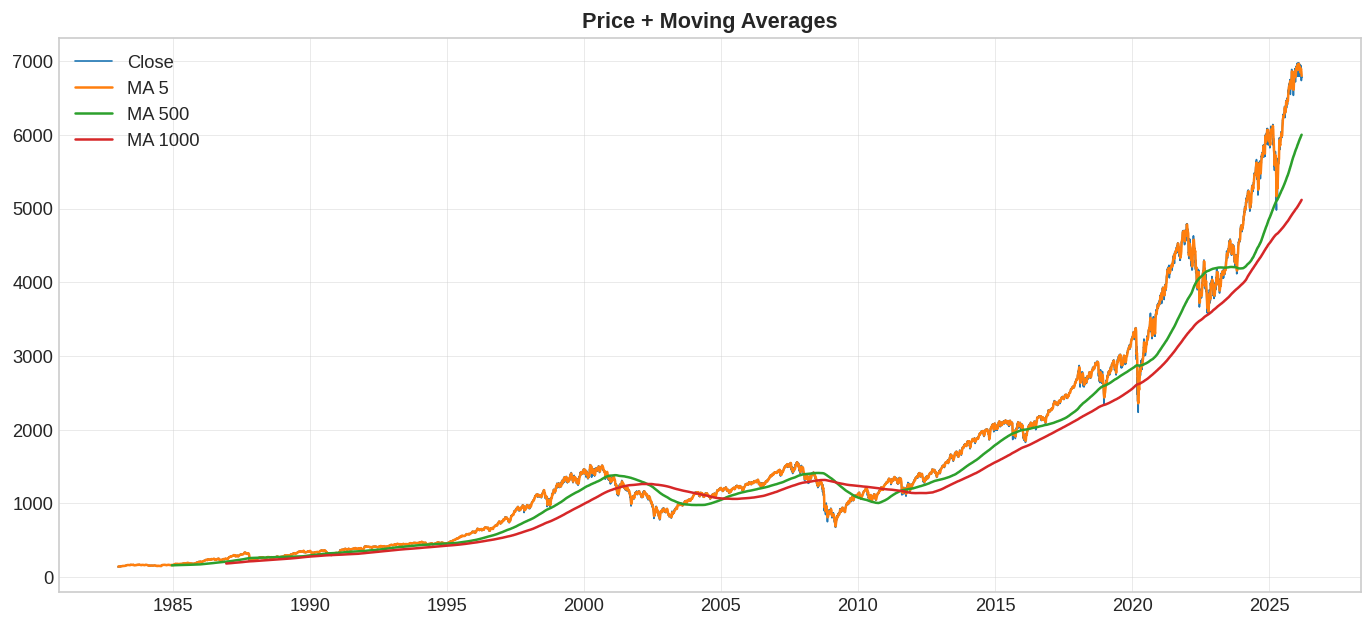

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df['Close'], label='Close', linewidth=1)

# 이동평균
plt.plot(df['Close'].rolling(5).mean(), label='MA 5')
plt.plot(df['Close'].rolling(20).mean(), label='MA 20')
plt.plot(df['Close'].rolling(60).mean(), label='MA 60')

plt.title("Price + Moving Averages")
plt.legend()
plt.show()

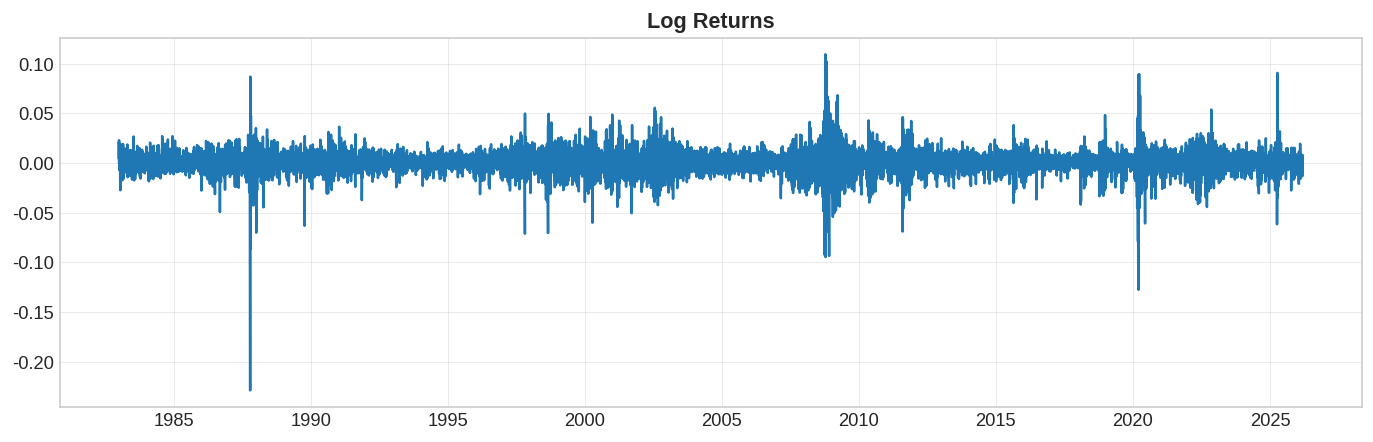

In [38]:
log_ret = np.log(df['Close'] / df['Close'].shift(1))

plt.figure(figsize=(14,4))
plt.plot(log_ret)
plt.title("Log Returns")
plt.show()

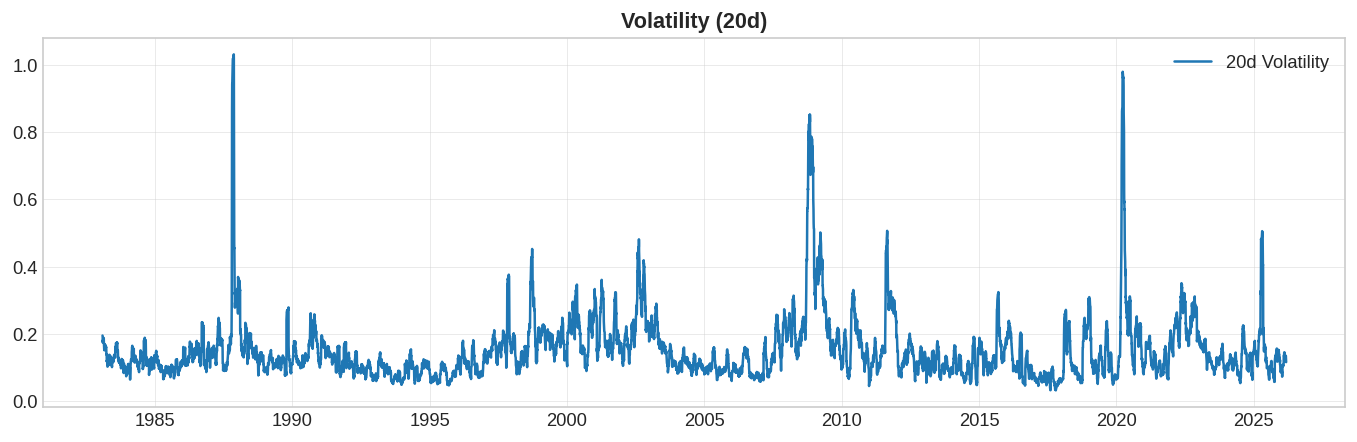

In [39]:
vol_20 = log_ret.rolling(20).std() * np.sqrt(252)

plt.figure(figsize=(14,4))
plt.plot(vol_20, label='20d Volatility')
plt.title("Volatility (20d)")
plt.legend()
plt.show()

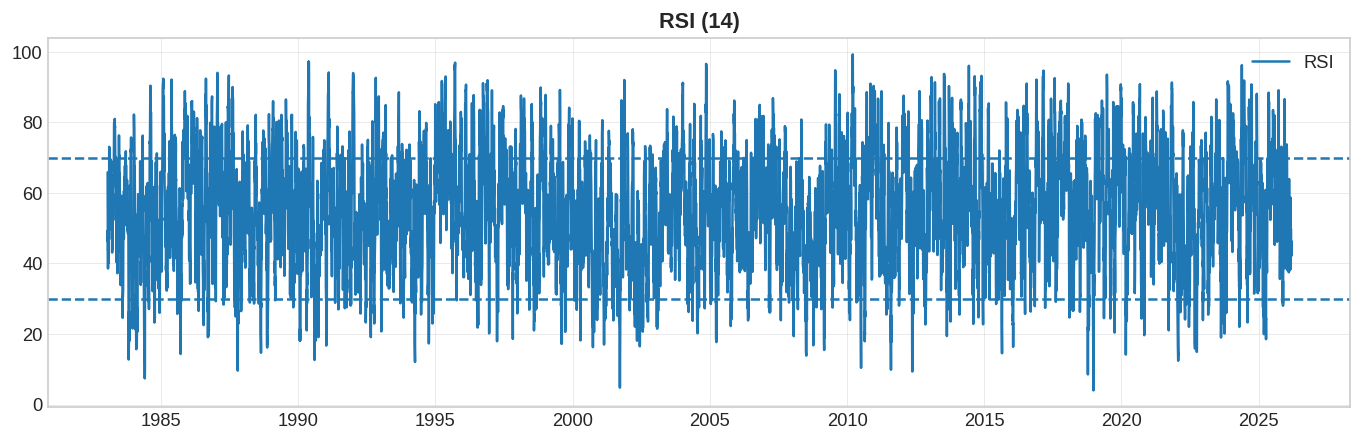

In [40]:
delta = df['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / (loss + 1e-10)
rsi = 100 - (100 / (1 + rs))

plt.figure(figsize=(14,4))
plt.plot(rsi, label='RSI')
plt.axhline(70, linestyle='--')
plt.axhline(30, linestyle='--')

plt.title("RSI (14)")
plt.legend()
plt.show()

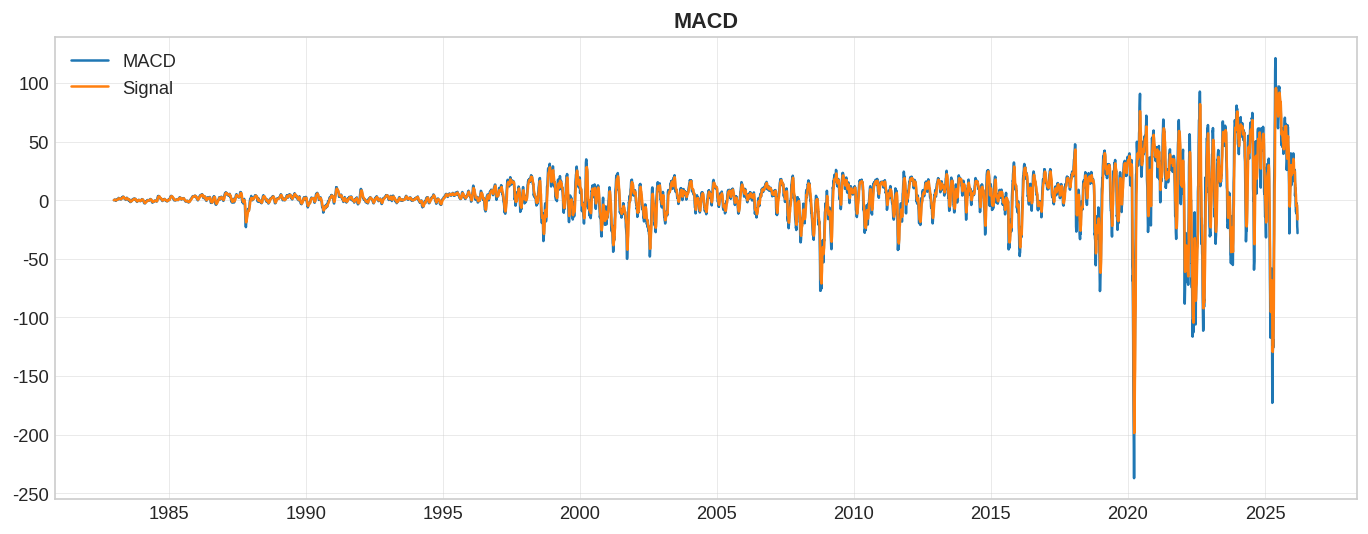

In [41]:
ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()

macd = ema12 - ema26
signal = macd.ewm(span=9).mean()

plt.figure(figsize=(14,5))

plt.plot(macd, label='MACD')
plt.plot(signal, label='Signal')

plt.title("MACD")
plt.legend()
plt.show()

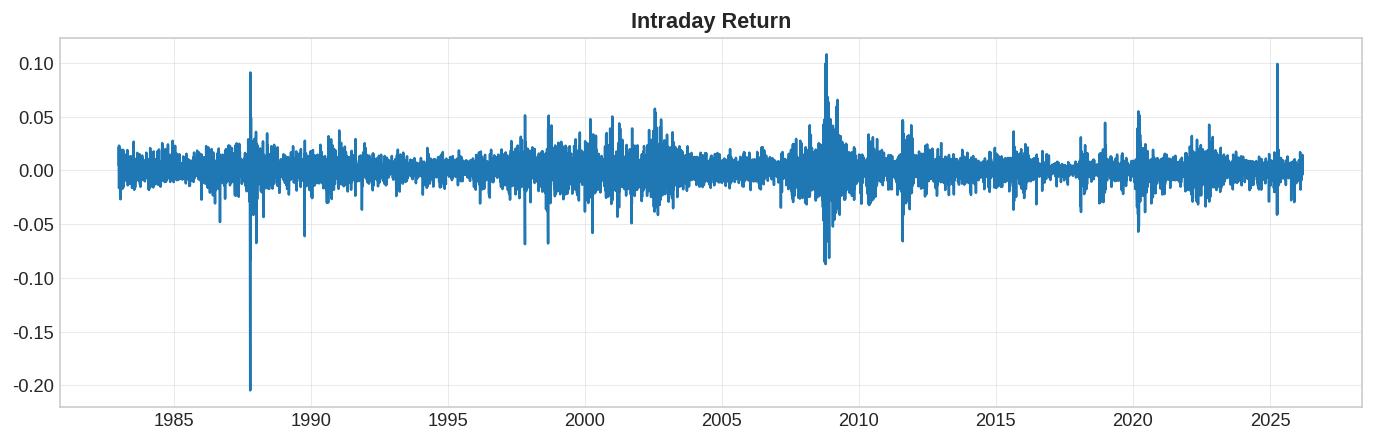

In [42]:
plt.figure(figsize=(14,4))
plt.plot((df['Close'] - df['Open']) / df['Open'])
plt.title("Intraday Return")
plt.show()

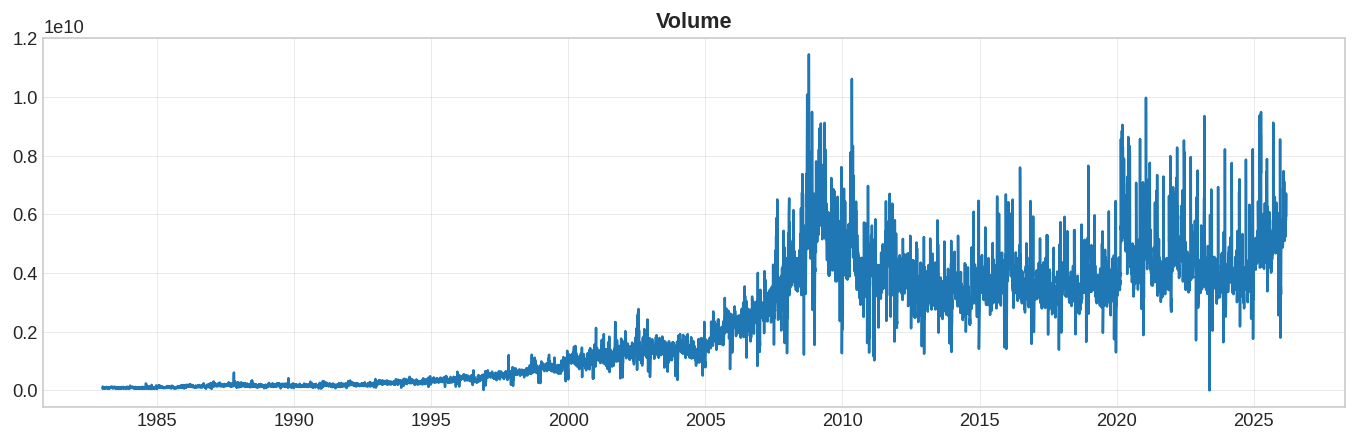

In [43]:
plt.figure(figsize=(14,4))
plt.plot(df['Volume'])
plt.title("Volume")
plt.show()

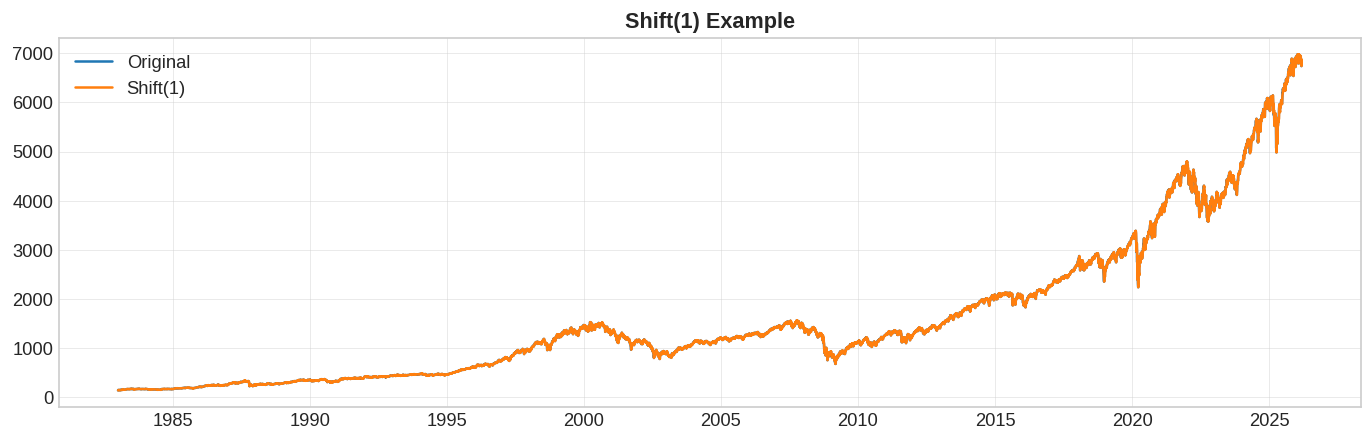

In [44]:
feat = df['Close']
shifted = feat.shift(1)

plt.figure(figsize=(14,4))
plt.plot(feat, label='Original')
plt.plot(shifted, label='Shift(1)')
plt.legend()
plt.title("Shift(1) Example")
plt.show()